# Modality-Invariant Representation Learning for Fair Skin Disease Classification (Version 2)

## Dataset Split

| Role | Dataset | Modality |
|------|---------|----------|
| **Train (paired)** | HIBA | Clinical + Dermoscopic |
| **Train (unpaired clinical)** | Fitzpatrick17k | Clinical |
| **Train (unpaired derm)** | HAM10000 | Dermoscopic |
| **Eval (cross-dataset)** | Derm7pt | Clinical + Dermoscopic (paired, 3 classes) |

## Unified 5-Class Taxonomy

| ID | Class |
|----|-------|
| 0 | Melanoma |
| 1 | Nevus |
| 2 | Basal Cell Carcinoma |
| 3 | Actinic Keratosis |
| 4 | Squamous Cell Carcinoma |

## Notebook Roadmap

| Phase | Section |
|-------|---------|
| 0 | Environment setup |
| 1 | Data parsers, label harmonization, CSV building, loaders |
| 2 | Dual-encoder ViT architecture |
| 3 | Multi-objective loss functions (Lcls, Lconf, Lcon, LMI) |
| 4 | Training loop with checkpointing |
| 5 | Fairness evaluation (EOM, PQD, DPM, FATE) |
| 6 | Ablation studies |
| 7 | Visualization (curves, FST bars, cross-dataset, UMAP) |

**Runtime:** T4 GPU or better. Full training ~8–12 h.


## Phase 0 — Environment Setup

In [95]:
!pip install -q timm einops scikit-learn \
               matplotlib seaborn pandas tqdm Pillow


In [96]:
import os, re, glob, random, math, json, warnings, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

import os
_hf_token = os.environ.get('HF_TOKEN', '')
if _hf_token:
    os.environ['HUGGING_FACE_HUB_TOKEN'] = _hf_token
    print(f'HF token loaded ({len(_hf_token)} chars).')
else:
    print('[INFO] No HF_TOKEN found — downloads may be slow. '
          'Add it via Kaggle Secrets → HF_TOKEN.')

_BACKBONE_CACHE = Path('/kaggle/working/backbone_cache')
_BACKBONE_CACHE.mkdir(exist_ok=True)
os.environ['TORCH_HOME']            = str(_BACKBONE_CACHE)
os.environ['HF_HOME']               = str(_BACKBONE_CACHE)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(_BACKBONE_CACHE)
print(f'Backbone cache dir: {_BACKBONE_CACHE}')


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
[INFO] No HF_TOKEN found — downloads may be slow. Add it via Kaggle Secrets → HF_TOKEN.
Backbone cache dir: /kaggle/working/backbone_cache


In [97]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG
# ════════════════════════════════════════════════════════════════════════════
DRIVE_ROOT = Path('/kaggle/input/datasets')
WORK_ROOT  = Path('/kaggle/working')

CFG = dict(
    # Dataset roots  (read-only)
    hiba_root     = DRIVE_ROOT / 'asosenge/hibaskinlesionsdataset-main',
    fitz_root     = DRIVE_ROOT / 'asosenge/fitzpatrick17k',
    ham_root      = DRIVE_ROOT / 'asosenge/ham10000',
    derm7pt_root  = DRIVE_ROOT / 'asosenge/derm7pt',
    # Outputs  (writable)
    csv_dir       = WORK_ROOT / 'csvs',
    ckpt_dir      = WORK_ROOT / 'checkpoints',
    results_dir   = WORK_ROOT / 'results',
    # Architecture — upgraded to ViT-Base for higher capacity
    backbone      = 'vit_small_patch16_224',
    embed_dim     = 512,
    img_size      = 224,
    # Training — extended schedule, warmup, cosine LR
    batch_size    = 32,
    num_epochs    = 150,
    lr            = 3e-5,          # lower LR for ViT-Base fine-tuning
    min_lr        = 1e-6,
    weight_decay  = 0.05,          # higher WD for ViT
    warmup_epochs = 30,
    # Loss weights — stronger fairness pressure
    lambda_cls    = 1.0,
    lambda_conf   = 1.0,           # increased (was 0.5)
    lambda_con    = 1.0,           # increased (was 0.5)
    lambda_mi     = 1.5,           # increased (was 1.0)
    temperature   = 0.07,
    # Label smoothing for Lcls
    label_smoothing = 0.1,
    # MixUp alpha — higher alpha for stronger regularisation
    mixup_alpha   = 0.4,           # was 0.2
    # Labels
    num_classes    = 5,
    num_skin_types = 6,
    # Online augmentation probability
    aug_probability = 0.85,
    # Ablation flags
    use_conf = True, use_con = True, use_mi = True,
    use_mixup = True,
)

LABEL_NAMES = {
    0: 'melanoma',
    1: 'nevus',
    2: 'basal cell carcinoma',
    3: 'actinic keratosis',
    4: 'squamous cell carcinoma',
}
DERM7PT_CLASSES = {0, 1, 2}
FST_NAMES = {i: f'FST {i+1}' for i in range(6)}

for k in ['csv_dir','ckpt_dir','results_dir']:
    CFG[k].mkdir(parents=True, exist_ok=True)

print('Config ready. Checking dataset roots:')
for k in ['hiba_root','fitz_root','ham_root','derm7pt_root']:
    status = 'OK' if CFG[k].exists() else 'MISSING — update path'
    print(f'  [{status}]  {k}')
print(f'  Backbone : {CFG["backbone"]}  embed_dim={CFG["embed_dim"]}')
print(f'  Epochs   : {CFG["num_epochs"]}  lr={CFG["lr"]}  warmup={CFG["warmup_epochs"]}')


Config ready. Checking dataset roots:
  [OK]  hiba_root
  [OK]  fitz_root
  [OK]  ham_root
  [OK]  derm7pt_root
  Backbone : vit_small_patch16_224  embed_dim=512
  Epochs   : 150  lr=3e-05  warmup=30


## Phase 1 — Data Preparation

### 1-A  Label Taxonomy & Mapping Tables

In [98]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL TAXONOMY & MAPPING TABLES
# ════════════════════════════════════════════════════════════════════════════

import re as _re

VALID_LABELS = {0, 1, 2, 3, 4}   # discard anything outside

def _clean(s: str) -> str:
    """Lowercase, strip, normalise hyphens/underscores to spaces."""
    s = str(s).lower().strip()
    s = _re.sub(r'[-_]+', ' ', s)
    s = _re.sub(r'\s+', ' ', s)
    return s

# ── HAM10000  (dx codes verified from HAM10000_metadata.csv) ─────────────
HAM_MAP = {
    'mel':   0,   # melanoma
    'nv':    1,   # nevus
    'bcc':   2,   # basal cell carcinoma
    'akiec': 3,   # actinic keratosis / SCC in-situ
}

# ── HIBA  (diagnosis column) ──────────────────────────────────────────────
HIBA_MAP = {
    'melanoma':                0,
    'nevus':                   1,
    'basal cell carcinoma':    2,
    'actinic keratosis':       3,
    'squamous cell carcinoma': 4,
}

# ── Fitzpatrick17k  ('label' column) ─────────────────────────────────────
FITZ_MAP = {
    # Melanoma (0)
    'melanoma':                             0,
    'malignant melanoma':                   0,
    'superficial spreading melanoma ssm':   0,
    'lentigo maligna':                      0,
    'lentigo maligna melanoma':             0,
    'acral lentiginous melanoma':           0,
    'nodular melanoma':                     0,
    # Nevus (1)
    'nevocytic nevus':                      1,
    'epidermal nevus':                      1,
    'congenital nevus':                     1,
    'halo nevus':                           1,
    'becker nevus':                         1,
    'nevus sebaceous of jadassohn':         1,
    'naevus comedonicus':                   1,
    # Basal Cell Carcinoma (2)
    'basal cell carcinoma':                 2,
    'basal cell carcinoma morpheiform':     2,
    'solid cystic basal cell carcinoma':    2,
    # Actinic Keratosis (3)
    'actinic keratosis':                    3,
    'porokeratosis actinic':                3,
    'bowens disease':                       3,
    'keratoacanthoma':                      3,
    # Squamous Cell Carcinoma (4)
    'squamous cell carcinoma':              4,
    'squamous cell carcinoma in situ':      4,
}

# ── Derm7pt label map  (meta.csv 'diagnosis' column) ─────────────────────
DERM7PT_MAP = {
    # MEL variants
    'melanoma':                     0,
    'melanoma (in situ)':           0,
    'melanoma (less than 0.76 mm)': 0,
    'melanoma (0.76 to 1.5 mm)':    0,
    'melanoma (more than 1.5 mm)':  0,
    'melanoma metastasis':          0,
    # NEV variants
    'dermal nevus':                 1,
    'clark nevus':                  1,
    'reed or spitz nevus':          1,
    'blue nevus':                   1,
    'recurrent nevus':              1,
    'combined nevus':               1,
    'congenital nevus':             1,
    # BCC
    'basal cell carcinoma':         2,
}

def harmonize_label(raw: str, mapping: dict, default=None) -> int | None:
    """Map a raw diagnosis string → canonical class integer, or None to exclude.

    Returns None when the label is not in any of the 5 valid classes.
    The caller is responsible for skipping None rows.
    """
    s = _clean(raw)
    if s in mapping:
        v = mapping[s]
        return v if v in VALID_LABELS else None
    for k, v in mapping.items():
        if k in s or s in k:
            return v if v in VALID_LABELS else None
    if 'nevus' in s or 'nevi' in s:
        return 1   # class 1 is always valid
    return None    # not one of the 5 classes → exclude

def parse_fst(raw) -> int:
    """Parse an integer Fitzpatrick skin type (1–6) → index (0–5).
    Returns -1 for missing / out-of-range values.
    """
    try:
        v = int(float(str(raw).strip()))
        return v - 1 if 1 <= v <= 6 else -1
    except (ValueError, TypeError):
        return -1

_ROMAN_TO_INT = {
    'i': 1, 'ii': 2, 'iii': 3, 'iv': 4, 'v': 5, 'vi': 6,
}
def parse_fst_roman(raw) -> int:
    """Parse roman-numeral or integer FST (HIBA uses I–VI strings).
    Returns 0-based index (0=FST I … 5=FST VI), or -1 if unparseable.
    """
    s = str(raw).lower().strip()
    if s in _ROMAN_TO_INT:
        return _ROMAN_TO_INT[s] - 1
    return parse_fst(raw)

def _verify_labels(df, name, n_classes=5):
    """Drop rows whose label is outside [0, n_classes-1] and report stats."""
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, n_classes - 1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df

print('Label taxonomy ready — 5 classes (seborrheic keratosis and other EXCLUDED).')
print('  FITZ: reads "label" column (fine-grained diagnoses)')
print('  HIBA: reads "diagnosis" column + "fitzpatrick_skin_type" (roman numerals)')
print('  HAM:  reads "dx" column + ITA-estimated FST')
print('  Derm7pt: melanoma / nevus / BCC only (3-class cross-eval)')


Label taxonomy ready — 5 classes (seborrheic keratosis and other EXCLUDED).
  FITZ: reads "label" column (fine-grained diagnoses)
  HIBA: reads "diagnosis" column + "fitzpatrick_skin_type" (roman numerals)
  HAM:  reads "dx" column + ITA-estimated FST
  Derm7pt: melanoma / nevus / BCC only (3-class cross-eval)


### 1-B  Dataset Parsers

In [99]:
# ════════════════════════════════════════════════════════════════════════════
# PAIRED PARSERS  (Derm7pt  &  HIBA)
# ════════════════════════════════════════════════════════════════════════════

def _safe_split(df, test_size=0.15, seed=42):
    """Stratified split.  Classes with only 1 sample are kept in train only
    (stratify would fail; a singleton class can't appear in both splits)."""
    if df.empty: return df, df
    # Count samples per class; singletons can't be stratified
    cts      = df['label'].value_counts()
    rare     = cts[cts < 2].index
    df_rare  = df[df['label'].isin(rare)]
    df_rest  = df[~df['label'].isin(rare)]
    if df_rest.empty:
        return df, df.iloc[:0]          # all rare — put everything in train
    try:
        tr, va = train_test_split(df_rest, test_size=test_size,
                                  random_state=seed, stratify=df_rest['label'])
    except ValueError:
        tr, va = train_test_split(df_rest, test_size=test_size, random_state=seed)
    # Rare-class samples go to train only (they can't contribute to val AUROC anyway)
    tr = pd.concat([tr, df_rare], ignore_index=True)
    return tr, va



def _safe_split_3way(df, val_size=0.15, test_size=0.15, seed=42):
    if df.empty:
        return df, df.iloc[:0], df.iloc[:0]

    cts     = df['label'].value_counts()
    rare    = cts[cts < 2].index
    df_rare = df[df['label'].isin(rare)]
    df_rest = df[~df['label'].isin(rare)]

    if df_rest.empty:
        return df, df.iloc[:0], df.iloc[:0]

    # First carve off the test split from the full remainder
    try:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size,
            random_state=seed, stratify=df_rest['label'])
    except ValueError:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size, random_state=seed)

    # Then carve val from the train+val portion
    # val_size is expressed relative to the *original* df, so rescale
    rel_val = val_size / (1.0 - test_size)
    try:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val,
            random_state=seed, stratify=df_tv['label'])
    except ValueError:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val, random_state=seed)

    df_train = pd.concat([df_train, df_rare], ignore_index=True)
    return df_train, df_val, df_test

print('Split helpers ready.')


Split helpers ready.


In [100]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba(root: Path):
    candidates = (
        list(root.rglob('metadata.csv')) +
        list(root.rglob('hiba_metadata.csv')) +
        list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv'))
    )
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}')
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows | columns: {list(meta.columns)}')

    # Validate required columns
    for req in ['isic_id', 'image_type', 'lesion_id', 'diagnosis']:
        if req not in meta.columns:
            print(f'[WARN] HIBA: required column "{req}" missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    fst_col = next((c for c in ['fitzpatrick_skin_type', 'fitzpatrick', 'fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')

    image_path_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_path_map)} entries')

    # ── Per-lesion accumulation ───────────────────────────────────────
    lesion_data = {}   # lesion_id → {label, fst, clinical:[], derm:[]}
    for _, r in meta.iterrows():
        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        diag  = str(r.get('diagnosis', 'other'))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        # Resolve image path
        img_path = image_path_map.get(isic)
        if img_path is None and '.' in isic:
            img_path = image_path_map.get(Path(isic).stem)

        if lid not in lesion_data:
            lesion_data[lid] = {
                'label': harmonize_label(diag, HIBA_MAP),
                'fst':   fst,
                'clinical': [],
                'derm':    [],
            }
        else:
            # Update FST if we now have a valid value
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_path:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(str(img_path))
            else:
                # "clinical: overview" and "clinical: close-up" are both clinical
                lesion_data[lid]['clinical'].append(str(img_path))

    # ── Build rows ────────────────────────────────────────────────────
    paired_rows   = []   # lesions with both modalities
    unpaired_clin = []   # clinical-only images  →  clin_* pool
    unpaired_derm = []   # derm-only images      →  derm_* pool

    for lid, d in lesion_data.items():
        label = d['label']; fst = d['fst']
        base = {'label': label, 'skin_type': fst, 'dataset': 'hiba'}

        if d['clinical'] and d['derm']:
            # Paired: use first of each modality
            paired_rows.append({
                **base,
                'lesion_id':     f'hiba_{lid}',
                'clinical_path': d['clinical'][0],
                'derm_path':     d['derm'][0],
            })
            # Extra clinical images beyond the first also go to unpaired pool
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_path': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_path': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    # ── Split each pool ───────────────────────────────────────────────
    tr_p, va_p, te_p = _safe_split_3way(df_paired) if not df_paired.empty else (pd.DataFrame(),)*3
    tr_uc, va_uc, te_uc = _safe_split_3way(df_uclin) if not df_uclin.empty else (pd.DataFrame(),)*3
    tr_ud, va_ud, te_ud = _safe_split_3way(df_uderm) if not df_uderm.empty else (pd.DataFrame(),)*3

    global _hiba_unpaired_splits
    _hiba_unpaired_splits = (tr_uc, va_uc, te_uc, tr_ud, va_ud, te_ud)

    print(f'[HIBA] paired    : {len(tr_p)} train | {len(va_p)} val | {len(te_p)} test')
    print(f'[HIBA] unpaired clin: {len(tr_uc)} train | {len(va_uc)} val | {len(te_uc)} test')
    print(f'[HIBA] unpaired derm: {len(tr_ud)} train | {len(va_ud)} val | {len(te_ud)} test')

    # Class distribution for paired
    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    # Class distribution for all HIBA images
    all_hiba = pd.concat([df_paired.rename(columns={'clinical_path':'image_path'}).get(['label','skin_type'],pd.DataFrame()),
                           df_uclin[['label','skin_type']] if not df_uclin.empty else pd.DataFrame(),
                           df_uderm[['label','skin_type']] if not df_uderm.empty else pd.DataFrame()])
    if not all_hiba.empty:
        vc2 = all_hiba['label'].value_counts().sort_index()
        print('[HIBA total  ] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc2.items()))
        n_fst = int((all_hiba['skin_type'] >= 0).sum())
        print(f'[HIBA] FST known: {n_fst}/{len(all_hiba)} images')

    return tr_p, va_p, te_p

_hiba_unpaired_splits = (pd.DataFrame(),)*6
print('HIBA parser ready.')


HIBA parser ready.


In [101]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER  (5-class filtered)
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba(root: Path):
    candidates = (
        list(root.rglob('metadata.csv')) +
        list(root.rglob('hiba_metadata.csv')) +
        list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv'))
    )
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}')
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows | columns: {list(meta.columns)}')

    for req in ['isic_id', 'image_type', 'lesion_id', 'diagnosis']:
        if req not in meta.columns:
            print(f'[WARN] HIBA: required column "{req}" missing')
            return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    fst_col = next((c for c in ['fitzpatrick_skin_type', 'fitzpatrick', 'fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')

    image_path_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_path_map)} entries')

    lesion_data = {}
    for _, r in meta.iterrows():
        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        diag  = str(r.get('diagnosis', ''))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        label = harmonize_label(diag, HIBA_MAP)
        if label is None:
            continue   # not one of the 5 classes — skip

        img_path = image_path_map.get(isic)
        if img_path is None and '.' in isic:
            img_path = image_path_map.get(Path(isic).stem)

        if lid not in lesion_data:
            lesion_data[lid] = {'label': label, 'fst': fst, 'clinical': [], 'derm': []}
        else:
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_path:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(str(img_path))
            else:
                lesion_data[lid]['clinical'].append(str(img_path))

    paired_rows   = []
    unpaired_clin = []
    unpaired_derm = []

    for lid, d in lesion_data.items():
        label = d['label']; fst = d['fst']
        base = {'label': label, 'skin_type': fst, 'dataset': 'hiba'}

        if d['clinical'] and d['derm']:
            paired_rows.append({
                **base,
                'lesion_id':     f'hiba_{lid}',
                'clinical_path': d['clinical'][0],
                'derm_path':     d['derm'][0],
            })
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_path': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_path': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    tr_p, va_p, te_p = _safe_split_3way(df_paired) if not df_paired.empty else (pd.DataFrame(),)*3
    tr_uc, va_uc, te_uc = _safe_split_3way(df_uclin) if not df_uclin.empty else (pd.DataFrame(),)*3
    tr_ud, va_ud, te_ud = _safe_split_3way(df_uderm) if not df_uderm.empty else (pd.DataFrame(),)*3

    global _hiba_unpaired_splits
    _hiba_unpaired_splits = (tr_uc, va_uc, te_uc, tr_ud, va_ud, te_ud)

    print(f'[HIBA] paired    : {len(tr_p)} train | {len(va_p)} val | {len(te_p)} test')
    print(f'[HIBA] unpaired clin: {len(tr_uc)} train | {len(va_uc)} val | {len(te_uc)} test')
    print(f'[HIBA] unpaired derm: {len(tr_ud)} train | {len(va_ud)} val | {len(te_ud)} test')

    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))

    return tr_p, va_p, te_p

_hiba_unpaired_splits = (pd.DataFrame(),)*6
print('HIBA parser ready (5-class filtered).')


HIBA parser ready (5-class filtered).


In [102]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED CLINICAL PARSERS  (Fitzpatrick17k)  — 5-class filtered
# ════════════════════════════════════════════════════════════════════════════

def _find_image(img_id, search_dirs, exts=['.jpg','.jpeg','.png'], recursive=False):
    for d in search_dirs:
        for e in exts:
            if recursive:
                candidates = list(d.rglob(f'{img_id}{e}'))
                if candidates:
                    return candidates[0]
            else:
                p = d / f'{img_id}{e}'
                if p.exists(): return p
    return None

def _build_image_map(root_dir: Path, exts=['.jpg','.jpeg','.png']):
    image_map = {}
    for ext in exts:
        for p in root_dir.rglob(f'*{ext}'):
            image_map[p.stem] = p
            image_map[p.name] = p
    return image_map

def parse_fitzpatrick17k(root: Path):
    csvs = list(root.glob('fitzpatrick17k.csv'))
    if not csvs: print(f'[WARN] Fitzpatrick17k CSV missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    meta    = pd.read_csv(csvs[0])
    img_dir = root/'data/finalfitz17k' if (root/'data/finalfitz17k').exists() else root

    print(f'[DEBUG FITZ] Building image path map for {img_dir}...')
    image_path_map = _build_image_map(img_dir)
    print(f'[DEBUG FITZ] Image map built with {len(image_path_map)} entries.')

    rows = []
    skipped = 0
    for _, r in meta.iterrows():
        _fst_raw = r.get('fitzpatrick_scale', r.get('fitzpatrick', -1))
        fst = parse_fst(_fst_raw) if str(_fst_raw).strip() not in ('-1', '-1.0', 'nan', '') else -1
        p   = None
        for col in ['md5hash','image_id','file_name']:
            if col in r.index and pd.notna(r[col]):
                candidate_id = str(r[col])
                p = image_path_map.get(candidate_id)
                if p: break
                if '.' in candidate_id:
                    p = image_path_map.get(Path(candidate_id).stem)
                    if p: break
        if p is None and 'url' in r.index:
            base = str(r['url']).split('/')[-1].split('?')[0]
            p = image_path_map.get(base)
            if p is None and '.' in base:
                p = image_path_map.get(Path(base).stem)
        if p is None: continue
        raw   = str(r.get('label', r.get('nine_partition_label', '')))
        label = harmonize_label(raw, FITZ_MAP)
        if label is None:
            skipped += 1
            continue   # not one of the 5 classes
        rows.append({'image_path': str(p), 'label': label,
                     'skin_type': fst, 'dataset': 'fitzpatrick17k'})
    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    fst_known_count = int((df.skin_type>=0).sum()) if not df.empty and 'skin_type' in df.columns else 0
    print(f'Fitzpatrick17k — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test  '
          f'| FST known: {fst_known_count}  | skipped (not in 5 classes): {skipped}')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return tr, va, te


# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED DERM PARSERS  (HAM10000)  — 5-class filtered
# ════════════════════════════════════════════════════════════════════════════

def parse_ham10000(root: Path):
    csvs = list(root.rglob('HAM10000_metadata.csv'))
    if not csvs:
        print('[WARN] HAM10000 CSV missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta_path = csvs[0]
    meta_root = meta_path.parent
    print(f'[DEBUG HAM] Found metadata at: {meta_path}')
    meta = pd.read_csv(meta_path)

    img_dirs = (
        [meta_root/'images'] +
        [meta_root/f'HAM10000_images_part_{i}' for i in [1, 2]] +
        [meta_root/f'images_part_{i}'          for i in [1, 2]] +
        [meta_root]
    )
    print(f'[DEBUG HAM] Building image path map...')
    image_path_map = _build_image_map(meta_root)
    print(f'[DEBUG HAM] Image map built with {len(image_path_map)} entries.')

    rows = []
    skipped = 0
    for _, r in meta.iterrows():
        img_id = str(r.get('image_id', ''))
        dx     = str(r.get('dx', '')).lower().strip()
        # Only keep mel, nv, bcc, akiec — bkl/df/vasc are excluded
        label = HAM_MAP.get(dx, None)
        if label is None:
            skipped += 1
            continue
        p = image_path_map.get(img_id) or _find_image(img_id, img_dirs)
        if p:
            rows.append({'image_path': str(p), 'label': label,
                         'skin_type': -1, 'dataset': 'ham10000'})

    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    print(f'HAM10000       — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test  '
          f'| skipped (not in 5 classes): {skipped}')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return tr, va, te

print('Unpaired parsers ready (5-class filtered).')


Unpaired parsers ready (5-class filtered).


In [103]:
# ════════════════════════════════════════════════════════════════════════════
# DERM7PT PARSER  (cross-evaluation, paired clinical+dermoscopic)
# ════════════════════════════════════════════════════════════════════════════

def parse_derm7pt(root: Path) -> pd.DataFrame:
    meta_csv = root / 'release_v0' / 'meta' / 'meta.csv'
    if not meta_csv.exists():
        alt = list(root.rglob('meta.csv'))
        if not alt:
            print(f'[WARN] Derm7pt: meta.csv not found under {root}')
            return pd.DataFrame()
        meta_csv = alt[0]

    meta = pd.read_csv(meta_csv)
    print(f'[Derm7pt] {len(meta)} rows | columns: {list(meta.columns)}')

    # ── Base directory for all images (the folder containing the 34 subfolders) ──
    img_base = root / 'release_v0' / 'images'
    if not img_base.exists():
        # Fallback: search for any folder named 'images'
        candidates = list(root.rglob('images'))
        if candidates:
            img_base = candidates[0]
        else:
            img_base = root   # last resort
    print(f'[Derm7pt] image base directory: {img_base}')

    # ── Helper: find an image given a relative path from the CSV ──
    def find_image(rel_path: str) -> str | None:
        rel_path = str(rel_path).strip().replace('\\', '/')
        if not rel_path:
            return None

        # 1) Try exact relative path as is (common case)
        full = img_base / rel_path
        if full.exists():
            return str(full)

        # 2) Try with common extensions (if missing)
        base, ext = Path(rel_path).stem, Path(rel_path).suffix
        if not ext:
            for ext_cand in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                cand = img_base / (rel_path + ext_cand)
                if cand.exists():
                    return str(cand)

        # 3) Case‑insensitive glob (handles .JPG vs .jpg)
        pattern = f"{rel_path}*"  # allow any extra characters
        for match in img_base.glob(pattern):
            if match.is_file():
                return str(match)
        for match in img_base.glob(pattern.lower()):
            if match.is_file():
                return str(match)

        # 4) Last resort: recursive search (slower, but catches misplaced files)
        base_name = Path(rel_path).stem
        for ext_cand in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            for found in img_base.rglob(base_name + ext_cand):
                return str(found)
            for found in img_base.rglob(base_name + ext_cand.lower()):
                return str(found)
        return None

    # Identify diagnosis column
    diag_col = None
    for c in ['diagnosis', 'Diagnosis', 'label', 'Label', 'diag']:
        if c in meta.columns:
            diag_col = c
            break
    if diag_col is None:
        print('[WARN] Derm7pt: could not identify diagnosis column')
        print(f'  Available columns: {list(meta.columns)}')
        return pd.DataFrame()
    print(f'[Derm7pt] using diagnosis column: "{diag_col}"')

    # Identify image filename columns
    derm_col   = next((c for c in ['derm', 'derm_image', 'dermoscopy_image'] if c in meta.columns), None)
    clinic_col = next((c for c in ['clinic', 'clinic_image', 'clinical_image'] if c in meta.columns), None)
    print(f'[Derm7pt] derm col: {derm_col}  clinic col: {clinic_col}')

    rows = []
    skipped_label = 0
    skipped_img   = 0

    for _, r in meta.iterrows():
        raw_diag = str(r.get(diag_col, ''))
        label = harmonize_label(raw_diag, DERM7PT_MAP)
        if label is None or label not in DERM7PT_CLASSES:
            skipped_label += 1
            continue

        derm_path = None
        if derm_col and pd.notna(r.get(derm_col)):
            derm_path = find_image(r[derm_col])

        clinic_path = None
        if clinic_col and pd.notna(r.get(clinic_col)):
            clinic_path = find_image(r[clinic_col])

        if derm_path is None and clinic_path is None:
            skipped_img += 1
            continue

        base = {'label': label, 'skin_type': -1, 'dataset': 'derm7pt'}
        if derm_path:
            rows.append({**base, 'image_path': derm_path, 'modality': 'derm'})
        if clinic_path:
            rows.append({**base, 'image_path': clinic_path, 'modality': 'clinical'})

    df = pd.DataFrame(rows)
    print(f'[Derm7pt] {len(df)} images kept (skipped label={skipped_label}, skipped img={skipped_img})')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('[Derm7pt] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
        mc = df['modality'].value_counts()
        print(f'[Derm7pt] modalities: {dict(mc)}')
    return df


# ── ITA-based Fitzpatrick Skin Type estimator (unchanged) ────────────────
_ITA_BRACKETS = [
    ( 55.0,  float('inf'), 0),
    ( 28.0,  55.0,         1),
    ( 10.0,  28.0,         2),
    (-30.0,  10.0,         3),
    (-55.0, -30.0,         4),
    (float('-inf'), -55.0, 5),
]

def _ita_to_fst(ita: float) -> int:
    for lo, hi, fst in _ITA_BRACKETS:
        if lo < ita <= hi:
            return fst
    return _ITA_BRACKETS[-1][2]

def _estimate_fst_single(path: str, min_skin_frac: float = 0.05, thumb_size: int = 96) -> int:
    try:
        from skimage import color as _skcolor
        img = Image.open(path).convert('RGB')
        img = img.resize((thumb_size, thumb_size), Image.BILINEAR)
        rgb = np.asarray(img, dtype=np.float32) / 255.0
        lab = _skcolor.rgb2lab(rgb)
        L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
        skin_mask = (L > 20) & (L < 90) & (a > 2) & (b > 5)
        if skin_mask.mean() < min_skin_frac:
            return -1
        mean_L = float(L[skin_mask].mean())
        mean_b = float(b[skin_mask].mean())
        if abs(mean_b) < 1e-6:
            return -1
        return _ita_to_fst(float(np.degrees(np.arctan((mean_L - 50.0) / mean_b))))
    except Exception:
        return -1

def estimate_fst_for_csv(df: pd.DataFrame, n_jobs: int = 4, cache_csv: Path = None) -> pd.DataFrame:
    if cache_csv is not None and Path(cache_csv).exists():
        cached = pd.read_csv(cache_csv)
        if 'skin_type' in cached.columns and len(cached) == len(df):
            df = df.copy()
            df['skin_type'] = cached['skin_type'].values
            print(f'  [FST cache] loaded {(df["skin_type"]>=0).sum()}/{len(df)} from {Path(cache_csv).name}')
            return df
    print(f'  Estimating FST via ITA for {len(df)} images (n_jobs={n_jobs}) …')
    from concurrent.futures import ThreadPoolExecutor
    paths = df['image_path'].tolist()
    with ThreadPoolExecutor(max_workers=n_jobs) as ex:
        fst_values = list(tqdm(ex.map(_estimate_fst_single, paths),
                               total=len(paths), desc='  ITA-FST', leave=True))
    df = df.copy()
    df['skin_type'] = fst_values
    n_known = sum(v >= 0 for v in fst_values)
    print(f'  FST estimated: {n_known}/{len(df)} ({100*n_known/max(len(df),1):.1f}%)')
    for fi in range(6):
        cnt = sum(v == fi for v in fst_values)
        if cnt: print(f'    FST {fi+1}: {cnt:>5}')
    if cache_csv is not None:
        df.to_csv(cache_csv, index=False)
        print(f'  Saved FST cache → {Path(cache_csv).name}')
    return df

print('Derm7pt parser + ITA-FST estimator ready.')
print('NOTE: Derm7pt FST will be computed via ITA (no ground-truth annotations).')

Derm7pt parser + ITA-FST estimator ready.
NOTE: Derm7pt FST will be computed via ITA (no ground-truth annotations).


### 1-C  Build CSVs & Data Loaders

In [104]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD ALL CSVs
# ════════════════════════════════════════════════════════════════════════════

def _verify_labels(df, name, n_classes=5):
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, n_classes - 1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df

# ── Step 1: Parse ──────────────────────────────────────────────────────────
print('='*60, '\nParsing datasets ...')
hiba_tr_p, hiba_va_p, hiba_te_p = parse_hiba(CFG['hiba_root'])
hiba_tr_uc, hiba_va_uc, hiba_te_uc, hiba_tr_ud, hiba_va_ud, hiba_te_ud = _hiba_unpaired_splits

fitz_tr, fitz_va, fitz_te = parse_fitzpatrick17k(CFG['fitz_root'])
ham_tr,  ham_va,  ham_te  = parse_ham10000(CFG['ham_root'])

# ── Step 2: Combine into three pools ──────────────────────────────────────
df_paired_all = pd.concat([hiba_tr_p, hiba_va_p, hiba_te_p], ignore_index=True)

df_clin_all = pd.concat([fitz_tr, fitz_va, fitz_te,
                          hiba_tr_uc, hiba_va_uc, hiba_te_uc], ignore_index=True)

df_derm_all = pd.concat([ham_tr, ham_va, ham_te,
                          hiba_tr_ud, hiba_va_ud, hiba_te_ud], ignore_index=True)

# Verify labels (5 classes)
print('\nLabel verification ...')
df_paired_all = _verify_labels(df_paired_all, 'HIBA paired (all)')
df_clin_all   = _verify_labels(df_clin_all,   'Clinical unpaired (all)')
df_derm_all   = _verify_labels(df_derm_all,   'Derm unpaired (all)')

# ── Step 3: Split combined pools ONCE (70/15/15) ─────────────────────────
print('\nSplitting combined pools (70/15/15 stratified) ...')
paired_train, paired_val, paired_test = _safe_split_3way(df_paired_all, seed=SEED)
clin_train,   clin_val,   clin_test   = _safe_split_3way(df_clin_all,   seed=SEED)
derm_train,   derm_val,   derm_test   = _safe_split_3way(df_derm_all,   seed=SEED)

print(f'  Paired  : {len(paired_train)} tr | {len(paired_val)} va | {len(paired_test)} te')
print(f'  Clinical: {len(clin_train)} tr | {len(clin_val)} va | {len(clin_test)} te')
print(f'  Derm    : {len(derm_train)} tr | {len(derm_val)} va | {len(derm_test)} te')

# ── Derm7pt cross-eval (paired cross-dataset evaluation set) ──────────────
print('\nBuilding Derm7pt evaluation set ...')
derm7pt_eval = parse_derm7pt(CFG['derm7pt_root'])
derm7pt_eval = _verify_labels(derm7pt_eval, 'Derm7pt eval', n_classes=5)

# Estimate FST via ITA (Derm7pt has no FST ground-truth)
if not derm7pt_eval.empty:
    _d7pt_cache = CFG['csv_dir'] / 'eval_derm7pt_fst_cache.csv'
    derm7pt_eval = estimate_fst_for_csv(derm7pt_eval, n_jobs=4, cache_csv=_d7pt_cache)

# ── Save ───────────────────────────────────────────────────────────────────
save_map = {
    'paired_train.csv' : paired_train,
    'paired_val.csv'   : paired_val,
    'paired_test.csv'  : paired_test,
    'clin_train.csv'   : clin_train,
    'clin_val.csv'     : clin_val,
    'clin_test.csv'    : clin_test,
    'derm_train.csv'   : derm_train,
    'derm_val.csv'     : derm_val,
    'derm_test.csv'    : derm_test,
    'eval_derm7pt.csv' : derm7pt_eval,
}
csv_dir = CFG['csv_dir']
for fname, df in save_map.items():
    if not df.empty:
        df.to_csv(csv_dir / fname, index=False)
        print(f'  Saved {fname:<25} ({len(df):>6} rows)')

print(f'\nTotal train : {len(paired_train)+len(clin_train)+len(derm_train):,}')
print(f'Total val   : {len(paired_val)+len(clin_val)+len(derm_val):,}')
print(f'Total test  : {len(paired_test)+len(clin_test)+len(derm_test):,}')
print(f'Cross-eval  : {len(derm7pt_eval):,}  (Derm7pt — melanoma/nevus/BCC only)')


Parsing datasets ...
[HIBA] 1616 rows | columns: ['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'benign_malignant', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'patient_id', 'personal_hx_mm', 'sex']
[HIBA] FST column: fitzpatrick_skin_type
[HIBA] image map: 3232 entries
[HIBA] paired    : 168 train | 36 val | 36 test
[HIBA] unpaired clin: 32 train | 8 val | 8 test
[HIBA] unpaired derm: 620 train | 134 val | 134 test
[HIBA paired] classes: melanoma=43  nevus=44  basal cell carcinoma=99  actinic keratosis=15  squamous cell carcinoma=39
[DEBUG FITZ] Building image path map for /kaggle/input/datasets/asosenge/fitzpatrick17k...
[DEBUG FITZ] Image map built with 33154 entries.
Fitzpatrick17k —   1866 train    400 val    400 test  | FST known: 2555  | skipped (not in 5 classes): 13911


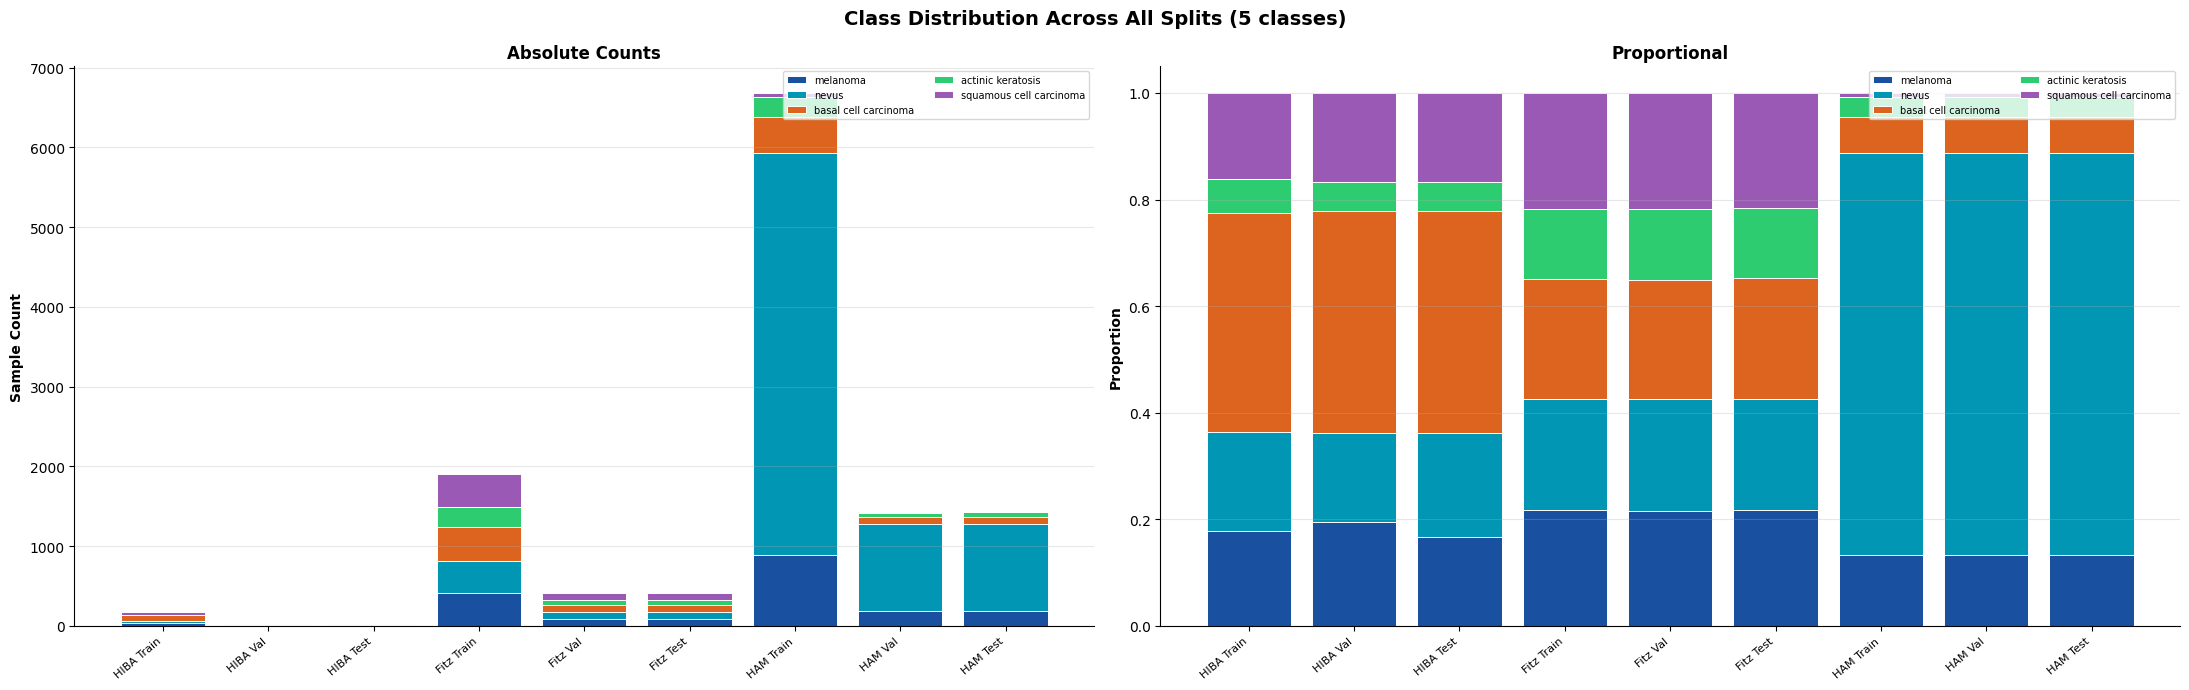

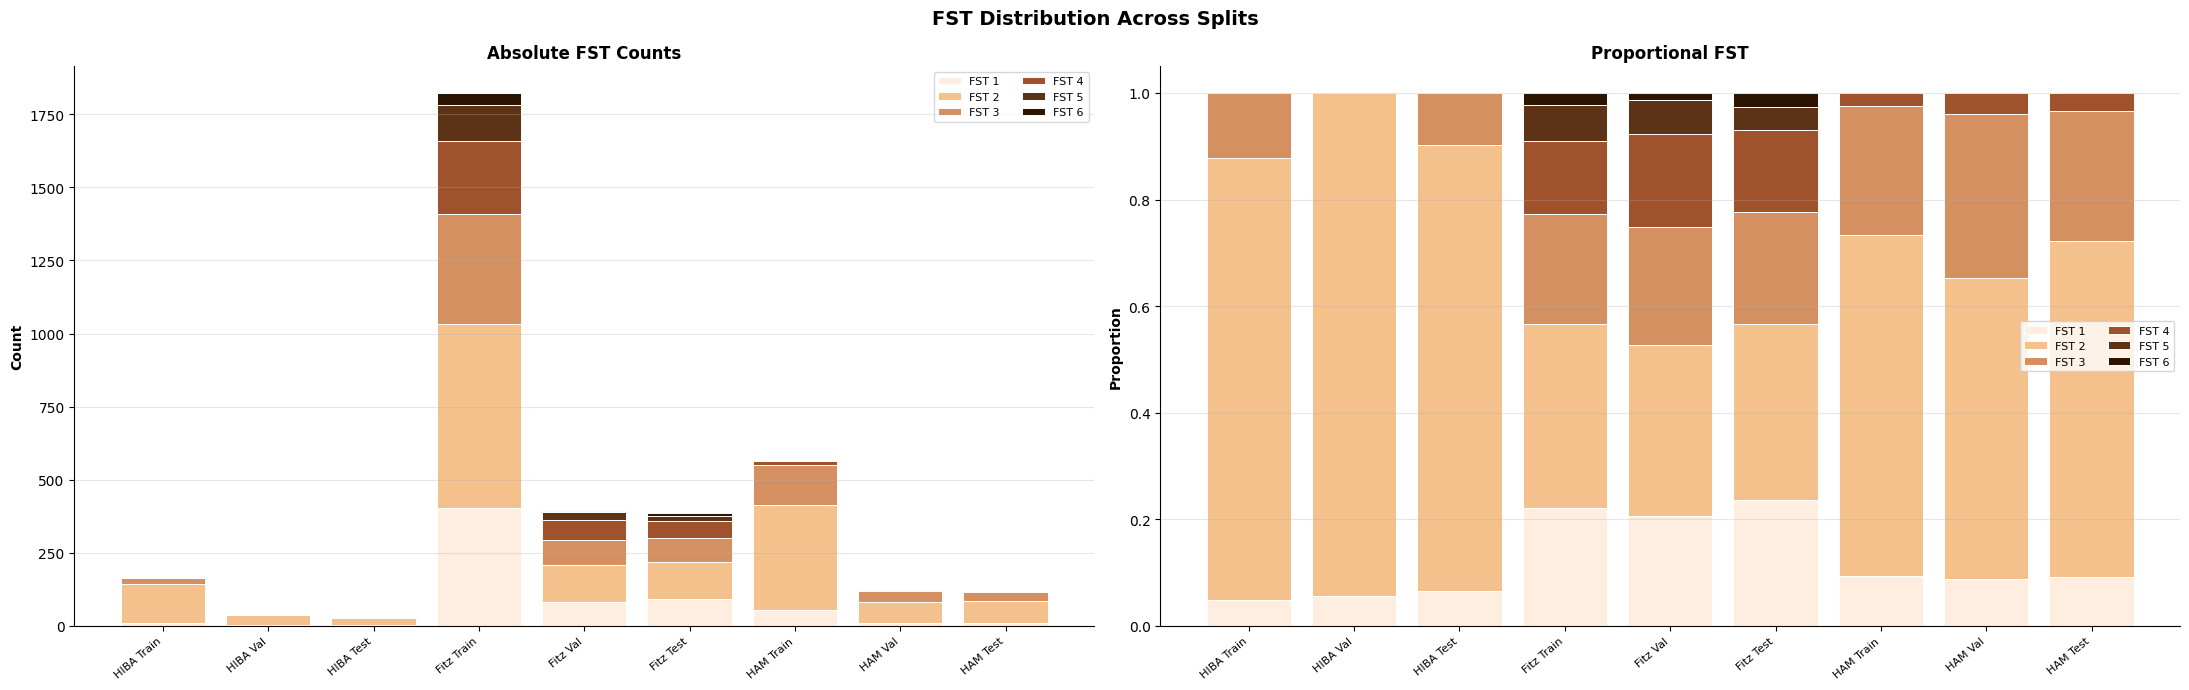

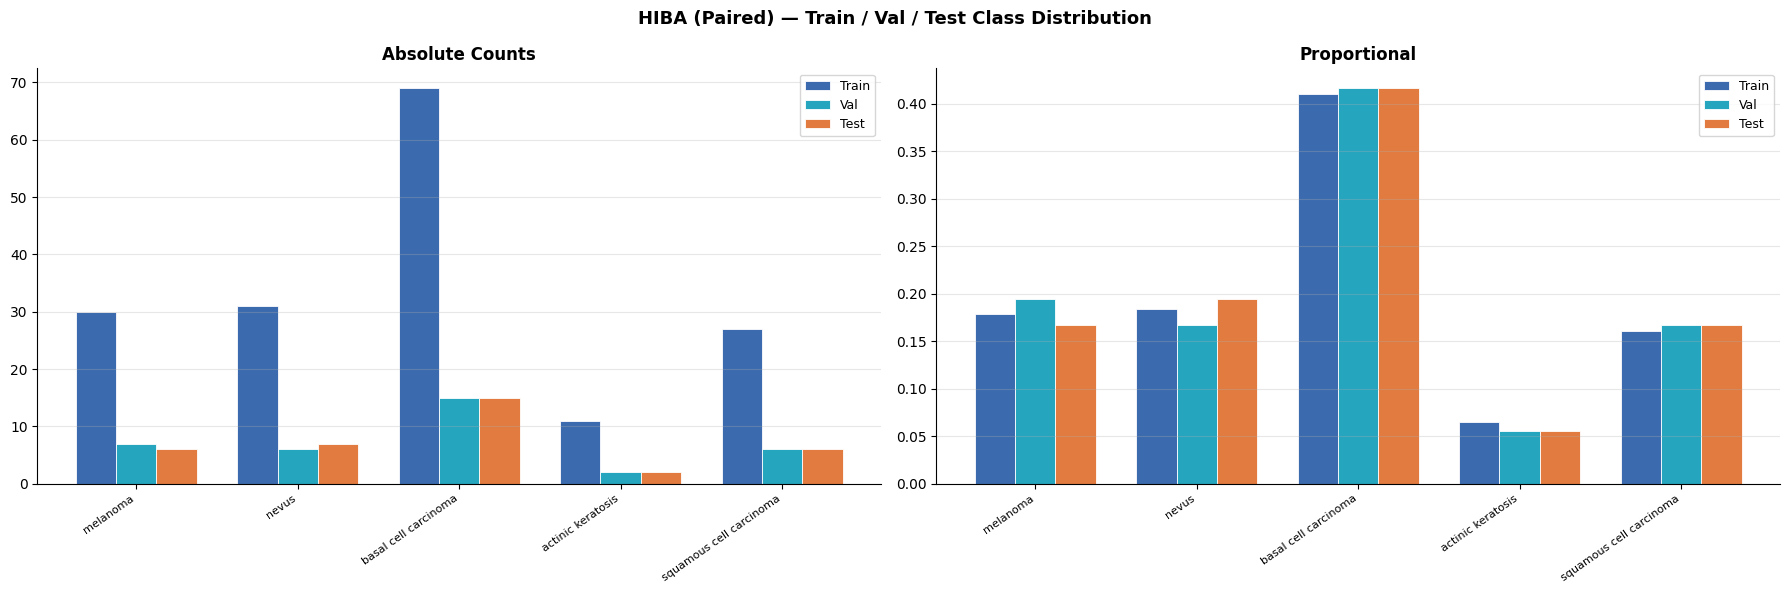

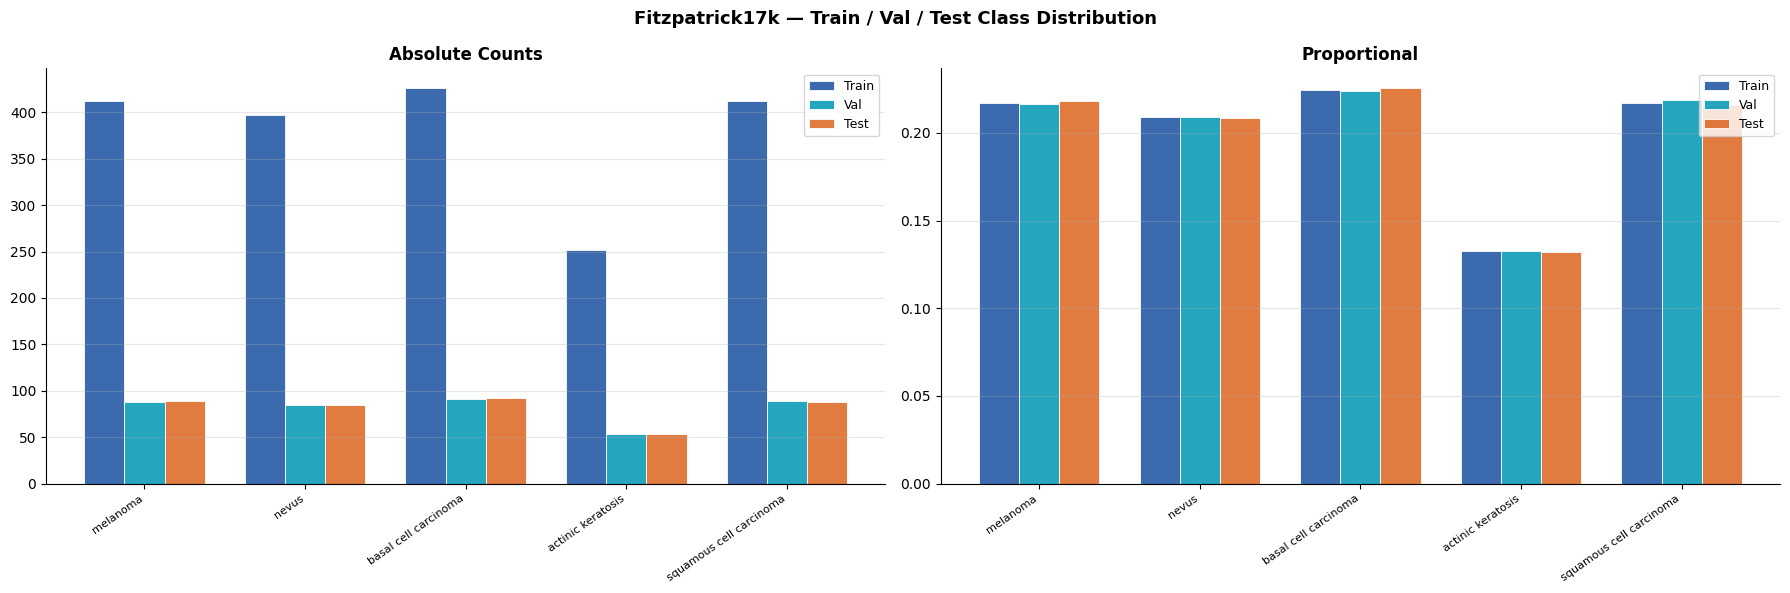

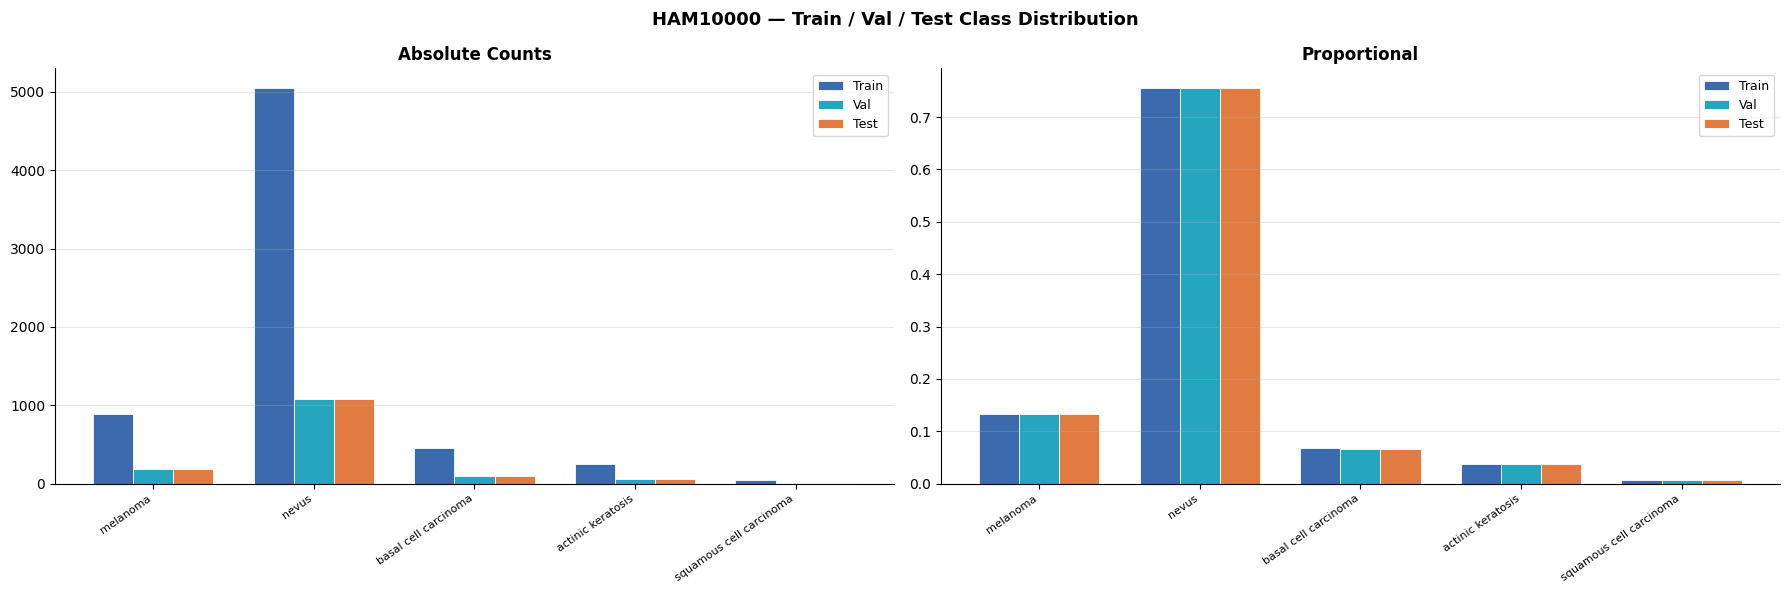

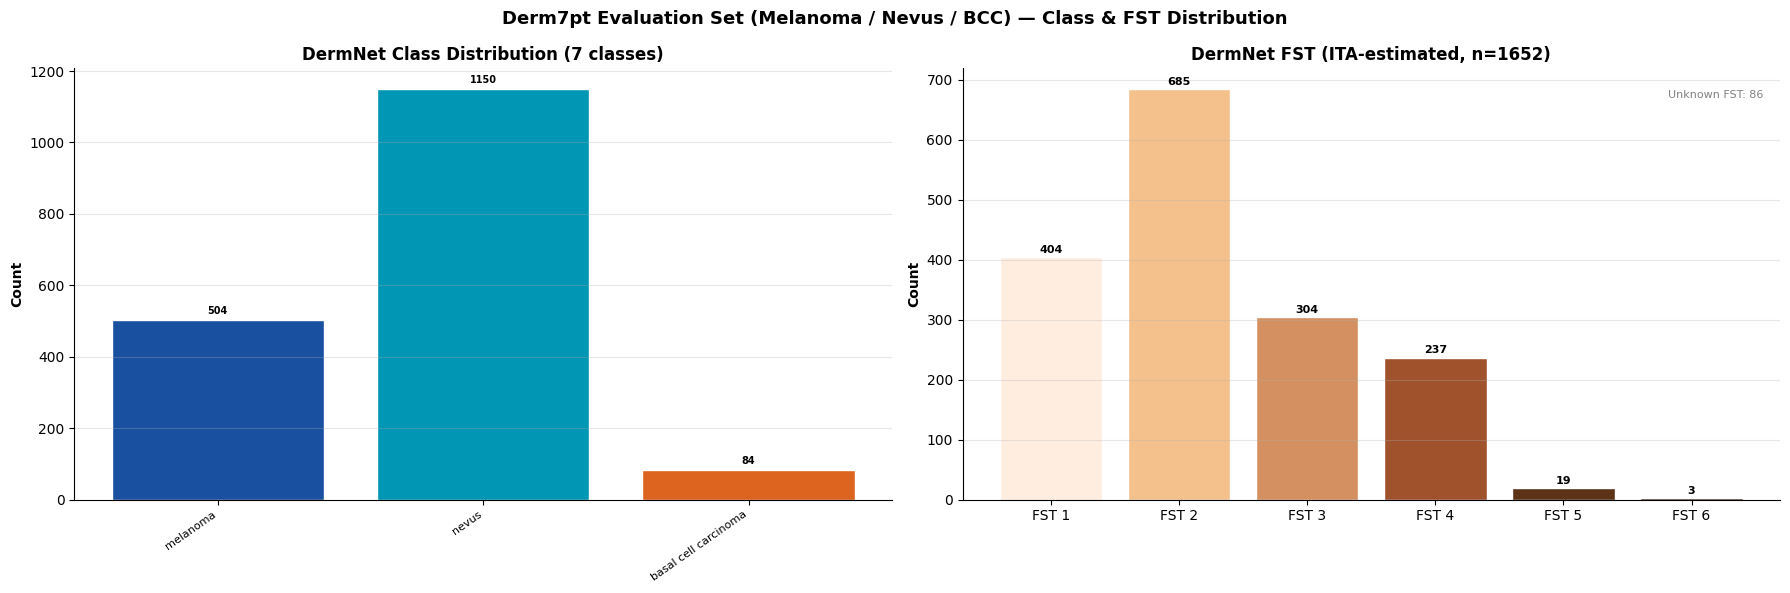

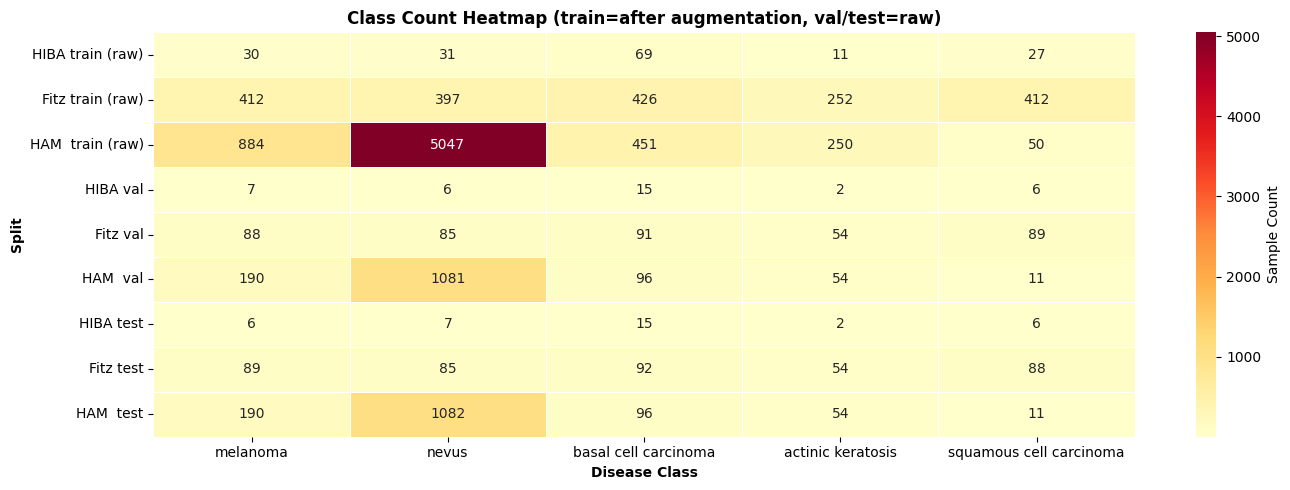


── Coverage Summary ─────────────────────────────────────
                Total rows  FST known  FST %  Class=Other Other %
Dataset                                                          
HIBA                   168        164  97.6%            0    0.0%
Fitzpatrick17k        1899       1823  96.0%            0    0.0%
HAM10000              6682        563   8.4%            0    0.0%
Derm7pt               1738       1652  95.1%            0    0.0%

EDA visualizations saved.


In [105]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — DATASET DISTRIBUTION VISUALIZATIONS  (7 classes)
# ════════════════════════════════════════════════════════════════════════════
import warnings as _w; _w.filterwarnings('ignore')

_LN  = LABEL_NAMES                          # {0:'melanoma', …, 6:'other'}
_LBL = [_LN[i] for i in range(5)]           # ordered list
_FST = {i: f'FST {i+1}' for i in range(6)}

_PAL_CLS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6']
_PAL_FST = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']

csv_dir = CFG['csv_dir']
def _load(fname):
    p = csv_dir / fname
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

# ── Load all splits ───────────────────────────────────────────────────────
_splits = {}
for tag, fname in [
    ('HIBA Train', 'paired_train.csv'), ('HIBA Val', 'paired_val.csv'),   ('HIBA Test', 'paired_test.csv'),
    ('Fitz Train', 'clin_train.csv'),   ('Fitz Val', 'clin_val.csv'),     ('Fitz Test', 'clin_test.csv'),
    ('HAM Train',  'derm_train.csv'),   ('HAM Val',  'derm_val.csv'),     ('HAM Test',  'derm_test.csv'),
]:
    d = _load(fname)
    if d.empty: continue
    # normalise clinical_path → image_path for paired sets
    if 'image_path' not in d.columns and 'clinical_path' in d.columns:
        d = d.rename(columns={'clinical_path': 'image_path'})
    _splits[tag] = d

_dermnet = _load('eval_derm7pt.csv')

# ──────────────────────────────────────────────────────────────────────────
# FIG 1  Class distribution across ALL splits (stacked absolute + proportional)
# ──────────────────────────────────────────────────────────────────────────
if _splits:
    _snames = list(_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('Class Distribution Across All Splits (5 classes)', fontsize=14, fontweight='bold')
    x = np.arange(len(_snames))
    bot_abs = np.zeros(len(_snames))
    bot_prop = np.zeros(len(_snames))
    totals = np.array([len(_splits[s]) for s in _snames], dtype=float)
    for ci in range(5):
        vals = np.array([_splits[s]['label'].value_counts().get(ci, 0) for s in _snames])
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(totals,1), bottom=bot_prop, color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(totals,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute Counts', 'Sample Count'),
        (axes[1], 'Proportional',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_snames, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='upper right')
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_class_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 2  FST distribution (only splits with FST annotations)
# ──────────────────────────────────────────────────────────────────────────
_fst_splits = {s: d for s, d in _splits.items()
               if 'skin_type' in d.columns and (d['skin_type'] >= 0).any()}
if _fst_splits:
    _fs = list(_fst_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('FST Distribution Across Splits', fontsize=14, fontweight='bold')
    x = np.arange(len(_fs))
    bot_abs = np.zeros(len(_fs)); bot_prop = np.zeros(len(_fs))
    for fi in range(6):
        vals  = np.array([(d['skin_type'] == fi).sum() for d in _fst_splits.values()])
        known = np.array([(d['skin_type'] >= 0).sum() for d in _fst_splits.values()], dtype=float)
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(known,1), bottom=bot_prop, color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(known,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute FST Counts', 'Count'),
        (axes[1], 'Proportional FST',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_fs, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_fst_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 3  Per-dataset train/val/test grouped bar (class counts)
# ──────────────────────────────────────────────────────────────────────────
for ds_name, prefix, cols in [
    ('HIBA (Paired)',  'HIBA', ['HIBA Train','HIBA Val','HIBA Test']),
    ('Fitzpatrick17k', 'Fitz', ['Fitz Train','Fitz Val','Fitz Test']),
    ('HAM10000',       'HAM',  ['HAM Train', 'HAM Val', 'HAM Test']),
]:
    dfs = {c: _splits[c] for c in cols if c in _splits}
    if not dfs: continue
    present_cls = sorted(set(c for d in dfs.values() for c in d['label'].unique()))
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{ds_name} — Train / Val / Test Class Distribution', fontsize=13, fontweight='bold')
    split_labels = list(dfs.keys())
    x = np.arange(len(present_cls)); w = 0.25
    colors = ['#1950A0','#0096B4','#DC641E']
    for si, (sname, d) in enumerate(dfs.items()):
        cnts = [d['label'].value_counts().get(c, 0) for c in present_cls]
        axes[0].bar(x+(si-1)*w, cnts, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
        props = np.array(cnts, dtype=float)/max(sum(cnts),1)
        axes[1].bar(x+(si-1)*w, props, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
    for ax, title in [(axes[0],'Absolute Counts'),(axes[1],'Proportional')]:
        ax.set_xticks(x); ax.set_xticklabels([_LN.get(c,f'C{c}') for c in present_cls],
                                               rotation=35, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/f'eda_class_{prefix.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 4  DermNet class + FST (eval set)
# ──────────────────────────────────────────────────────────────────────────
if not _dermnet.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Derm7pt Evaluation Set (Melanoma / Nevus / BCC) — Class & FST Distribution', fontsize=13, fontweight='bold')
    vc = _dermnet['label'].value_counts().sort_index()
    bar_cols = [_PAL_CLS[i % 7] for i in vc.index]
    bars = axes[0].bar([_LN.get(i,f'C{i}') for i in vc.index], vc.values,
                       color=bar_cols, edgecolor='white', lw=1)
    for b, n in zip(bars, vc.values):
        axes[0].text(b.get_x()+b.get_width()/2, n+vc.values.max()*0.01, str(n),
                     ha='center', va='bottom', fontsize=7, fontweight='bold')
    axes[0].set_title('DermNet Class Distribution (7 classes)', fontweight='bold')
    axes[0].set_xticklabels([_LN.get(i,f'C{i}') for i in vc.index], rotation=35, ha='right', fontsize=8)
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3); axes[0].spines[['top','right']].set_visible(False)
    if 'skin_type' in _dermnet.columns:
        fst_k = _dermnet[_dermnet['skin_type'] >= 0]
        if not fst_k.empty:
            fst_ns = [(_dermnet['skin_type']==fi).sum() for fi in range(6)]
            b2 = axes[1].bar([_FST[fi] for fi in range(6)], fst_ns, color=_PAL_FST, edgecolor='white', lw=1)
            for bar, n in zip(b2, fst_ns):
                if n: axes[1].text(bar.get_x()+bar.get_width()/2, n+max(fst_ns)*0.01,
                                   str(n), ha='center', fontsize=8, fontweight='bold')
            axes[1].set_title(f'DermNet FST (ITA-estimated, n={len(fst_k)})', fontweight='bold')
            axes[1].set_ylabel('Count', fontweight='bold')
            axes[1].text(0.98, 0.95, f'Unknown FST: {(_dermnet["skin_type"]<0).sum()}',
                         transform=axes[1].transAxes, ha='right', va='top', fontsize=8, color='grey')
            axes[1].grid(axis='y', alpha=0.3); axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_derm7pt.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 5  Class imbalance heatmap — raw counts per (dataset × class)
# ──────────────────────────────────────────────────────────────────────────
_heatmap_splits = {
    'HIBA train (raw)':  pd.read_csv(csv_dir/'paired_train.csv') if (csv_dir/'paired_train.csv').exists() else pd.DataFrame(),
    'Fitz train (raw)':  pd.read_csv(csv_dir/'clin_train.csv')   if (csv_dir/'clin_train.csv').exists()   else pd.DataFrame(),
    'HAM  train (raw)':  pd.read_csv(csv_dir/'derm_train.csv')   if (csv_dir/'derm_train.csv').exists()   else pd.DataFrame(),
    'HIBA val':          pd.read_csv(csv_dir/'paired_val.csv')    if (csv_dir/'paired_val.csv').exists()  else pd.DataFrame(),
    'Fitz val':          pd.read_csv(csv_dir/'clin_val.csv')      if (csv_dir/'clin_val.csv').exists()      else pd.DataFrame(),
    'HAM  val':          pd.read_csv(csv_dir/'derm_val.csv')      if (csv_dir/'derm_val.csv').exists()      else pd.DataFrame(),
    'HIBA test':         pd.read_csv(csv_dir/'paired_test.csv')    if (csv_dir/'paired_test.csv').exists()  else pd.DataFrame(),
    'Fitz test':         pd.read_csv(csv_dir/'clin_test.csv')      if (csv_dir/'clin_test.csv').exists()      else pd.DataFrame(),
    'HAM  test':         pd.read_csv(csv_dir/'derm_test.csv')      if (csv_dir/'derm_test.csv').exists()      else pd.DataFrame(),
}
_hmap_data = {}
for name, d in _heatmap_splits.items():
    if d.empty: continue
    _hmap_data[name] = [d['label'].value_counts().get(ci, 0) for ci in range(5)]
if _hmap_data:
    import seaborn as sns
    _hm_df = pd.DataFrame(_hmap_data, index=[_LN[i] for i in range(5)]).T
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(_hm_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                linecolor='white', ax=ax, cbar_kws={'label': 'Sample Count'})
    ax.set_title('Class Count Heatmap (train=after augmentation, val/test=raw)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Disease Class', fontweight='bold')
    ax.set_ylabel('Split', fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_imbalance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 6  Coverage summary: % images found + % FST known per dataset
# ──────────────────────────────────────────────────────────────────────────
_cov_rows = []
for tag, fname in [('HIBA','paired_train.csv'),('Fitzpatrick17k','clin_train.csv'),
                    ('HAM10000','derm_train.csv'),('Derm7pt','eval_derm7pt.csv')]:
    d = _load(fname)
    if d.empty: continue
    _img_col = 'image_path' if 'image_path' in d.columns else 'clinical_path'
    n_total  = len(d)
    n_fst    = int((d['skin_type'] >= 0).sum()) if 'skin_type' in d.columns else 0
    n_cls6   = int((d['label'] == 6).sum()) if 'label' in d.columns else 0
    _cov_rows.append({'Dataset': tag, 'Total rows': n_total,
                       'FST known': n_fst, 'FST %': f'{100*n_fst/max(n_total,1):.1f}%',
                       'Class=Other': n_cls6, 'Other %': f'{100*n_cls6/max(n_total,1):.1f}%'})
if _cov_rows:
    _cov_df = pd.DataFrame(_cov_rows).set_index('Dataset')
    print('\n── Coverage Summary ─────────────────────────────────────')
    print(_cov_df.to_string())
    _cov_df.to_csv(CFG['results_dir']/'eda_coverage_summary.csv')

print('\nEDA visualizations saved.')


In [106]:
# ════════════════════════════════════════════════════════════════════════════
# ONLINE DATA AUGMENTATION  (applied per-batch during training)
# ════════════════════════════════════════════════════════════════════════════
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

_AUG_P = CFG['aug_probability']   # probability gate for the full augmentation pipeline

# Individual transform probabilities (applied when the pipeline gate fires)
train_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size']+32, CFG['img_size']+32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomApply([transforms.RandomRotation(30)],      p=0.6),
    transforms.RandomApply([transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.08)], p=0.7),
    transforms.RandomApply([transforms.GaussianBlur(
        kernel_size=5, sigma=(0.1, 2.0))],                       p=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

denorm_tfm = transforms.Compose([
    transforms.Normalize(mean=[0,0,0], std=[1/s for s in IMG_STD]),
    transforms.Normalize(mean=[-m for m in IMG_MEAN], std=[1,1,1]),
])


class UnpairedSkinDataset(Dataset):
    """Dataset for unpaired (single-modality) images.

    When train=True, augmentation is applied with probability aug_prob.
    When train=False (val/eval), only the deterministic val_tfm is applied.
    """
    def __init__(self, df_or_csv, modality='clinical', transform=None,
                 train=True, aug_prob=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv, (str, Path))
                   else df_or_csv.reset_index(drop=True))
        self.modality  = modality
        self.transform = transform
        self.train     = train
        self.aug_prob  = aug_prob if aug_prob is not None else CFG['aug_probability']

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try:
            img = Image.open(r['image_path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224))

        # Online augmentation: apply train_tfm with probability aug_prob,
        # otherwise apply val_tfm (deterministic resize+normalize only)
        if self.train and random.random() < self.aug_prob:
            img = train_tfm(img)
        else:
            img = val_tfm(img)

        return {
            'image'     : img,
            'label'     : torch.tensor(int(r['label']),     dtype=torch.long),
            'skin_type' : torch.tensor(int(r['skin_type']), dtype=torch.long),
            'modality'  : self.modality,
            'paired'    : False,
            'image_path': str(r['image_path']),
        }


class PairedSkinDataset(Dataset):
    """Dataset for paired (clinical + dermoscopic) images from HIBA."""
    def __init__(self, df_or_csv, transform=None, train=True, aug_prob=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv, (str, Path))
                   else df_or_csv.reset_index(drop=True))
        self.transform = transform
        self.train     = train
        self.aug_prob  = aug_prob if aug_prob is not None else CFG['aug_probability']

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try:
            clin = Image.open(r['clinical_path']).convert('RGB')
            derm = Image.open(r['derm_path']).convert('RGB')
        except Exception:
            clin = derm = Image.new('RGB', (224, 224))

        # Both modalities get the same augmentation decision for consistency
        if self.train and random.random() < self.aug_prob:
            clin = train_tfm(clin)
            derm = train_tfm(derm)
        else:
            clin = val_tfm(clin)
            derm = val_tfm(derm)

        return {
            'clinical'  : clin,
            'derm'      : derm,
            'label'     : torch.tensor(int(r['label']),     dtype=torch.long),
            'skin_type' : torch.tensor(int(r['skin_type']), dtype=torch.long),
            'paired'    : True,
        }


class MixedDataset(Dataset):
    def __init__(self, paired_ds, unpaired_list):
        self.paired   = paired_ds
        self.unpaired = unpaired_list
        self.index = (
            [('p', i)    for i in range(len(paired_ds))] +
            [('u', di, i) for di, ds in enumerate(unpaired_list)
                          for i in range(len(ds))]
        )
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        e = self.index[i]
        return self.paired[e[1]] if e[0] == 'p' else self.unpaired[e[1]][e[2]]


def mixed_collate(batch):
    paired_items   = [item for item in batch if item.get('paired') is True]
    unpaired_items = [item for item in batch if item.get('paired') is not True]

    result = {}
    result['label']      = torch.stack([item['label']     for item in batch])
    result['skin_type']  = torch.stack([item['skin_type'] for item in batch])
    result['paired']     = [item['paired']                for item in batch]
    result['modality']   = [item.get('modality', 'clinical') for item in batch]
    result['image_path'] = [item.get('image_path', '')    for item in batch]

    if paired_items:
        result['clinical'] = torch.stack([item['clinical'] for item in paired_items])
        result['derm']     = torch.stack([item['derm']     for item in paired_items])
    if unpaired_items:
        result['image']    = torch.stack([item['image']    for item in unpaired_items])

    return result

print('Online augmentation + Dataset classes defined.')
print(f'  aug_probability = {CFG["aug_probability"]} (applied per-sample per-batch during training)')


Online augmentation + Dataset classes defined.
  aug_probability = 0.85 (applied per-sample per-batch during training)


In [107]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD DATA LOADERS
# ════════════════════════════════════════════════════════════════════════════
import pandas as _pd
from torch.utils.data import WeightedRandomSampler

def _safe_csv(path):
    p = Path(path)
    if not p.exists():
        print(f'  [WARN] CSV not found, skipping: {p.name}')
        return _pd.DataFrame()
    df = _pd.read_csv(p)
    if df.empty:
        print(f'  [WARN] CSV is empty, skipping: {p.name}')
    return df

csv = CFG['csv_dir']

# Paired (HIBA) — train with online aug, val without
_paired_tr = _safe_csv(csv/'paired_train.csv')
_paired_va = _safe_csv(csv/'paired_val.csv')
paired_tr_ds = PairedSkinDataset(_paired_tr, train=True)  if not _paired_tr.empty else None
paired_va_ds = PairedSkinDataset(_paired_va, train=False) if not _paired_va.empty else None

# Clinical unpaired (Fitzpatrick17k)
_clin_tr = _safe_csv(csv/'clin_train.csv')
_clin_va = _safe_csv(csv/'clin_val.csv')
clin_tr_ds  = UnpairedSkinDataset(_clin_tr, 'clinical', train=True)  if not _clin_tr.empty else None
clin_val_ds = UnpairedSkinDataset(_clin_va, 'clinical', train=False) if not _clin_va.empty else None

# Dermoscopic unpaired (HAM10000)
_derm_tr = _safe_csv(csv/'derm_train.csv')
derm_tr_ds = UnpairedSkinDataset(_derm_tr, 'derm', train=True) if not _derm_tr.empty else None

# Build mixed training dataset
_unpaired_list = [ds for ds in [clin_tr_ds, derm_tr_ds] if ds is not None]
assert _unpaired_list or paired_tr_ds is not None, \
    'No training data found — check that dataset CSVs were built in Phase 1.'

if paired_tr_ds is None:
    class _EmptyPaired(Dataset):
        def __len__(self): return 0
        def __getitem__(self, i): raise IndexError
    paired_tr_ds = _EmptyPaired()

train_ds = MixedDataset(paired_tr_ds, _unpaired_list)

# ── WeightedRandomSampler (fast, reads DataFrames) ───────────────────────
def _build_sampler_fast(paired_df, unpaired_dfs):
    all_labels = []
    if paired_df is not None and not paired_df.empty:
        all_labels.extend(paired_df['label'].astype(int).tolist())
    for df in unpaired_dfs:
        if df is not None and not df.empty:
            all_labels.extend(df['label'].astype(int).tolist())
    all_labels   = np.array(all_labels)
    class_counts = np.bincount(all_labels, minlength=CFG['num_classes']).astype(float)
    class_counts = np.where(class_counts == 0, 1, class_counts)
    weights      = 1.0 / class_counts[all_labels]
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights).double(),
        num_samples=len(weights),
        replacement=True,
    )

print('  Building WeightedRandomSampler ...')
_paired_df_for_sampler    = _paired_tr if not _paired_tr.empty else None
_unpaired_dfs_for_sampler = [df for df in [_clin_tr, _derm_tr]
                              if df is not None and not df.empty]
_sampler = _build_sampler_fast(_paired_df_for_sampler, _unpaired_dfs_for_sampler)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    sampler=_sampler,
    collate_fn=mixed_collate,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=2,
)

# Validation loader
# IMPORTANT: include HIBA paired_val so all 5 classes are always represented.
# Fitzpatrick17k + HAM10000 val splits lack SCC (class 4), causing AUROC NaN.
_val_parts = []

# Add HIBA paired val (clinical + derm sides separately)
_pva = _safe_csv(csv/'paired_val.csv')
if not _pva.empty and 'clinical_path' in _pva.columns and 'derm_path' in _pva.columns:
    _pva_clin          = _pva[['label','skin_type']].copy()
    _pva_clin['image_path'] = _pva['clinical_path'].values
    _pva_derm          = _pva[['label','skin_type']].copy()
    _pva_derm['image_path'] = _pva['derm_path'].values
    _val_parts.append(UnpairedSkinDataset(_pva_clin, 'clinical', train=False))
    _val_parts.append(UnpairedSkinDataset(_pva_derm, 'derm',     train=False))
    print(f'  val: added {len(_pva)} HIBA paired val cases (clinical+derm)')

# Add Fitzpatrick17k clinical val
if clin_val_ds is not None:
    _val_parts.append(clin_val_ds)

# Add HAM10000 derm val
_derm_va = _safe_csv(csv/'derm_val.csv')
if not _derm_va.empty:
    _val_parts.append(UnpairedSkinDataset(_derm_va, 'derm', train=False))

assert _val_parts, 'No validation data found.'
from torch.utils.data import ConcatDataset as _ConcatDSval
_val_ds = _ConcatDSval(_val_parts) if len(_val_parts) > 1 else _val_parts[0]
print(f'  val_ds: {len(_val_parts)} part(s)  total={len(_val_ds)} samples')

val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    collate_fn=mixed_collate,
    persistent_workers=True,
    prefetch_factor=2,
)

# Internal Test loader
_test_dfs = []
for _csv_f, _mod in [
        (csv/'paired_test.csv', 'clinical'),
        (csv/'clin_test.csv',   'clinical'),
        (csv/'derm_test.csv',   'derm'),
]:
    _d = _safe_csv(_csv_f)
    if not _d.empty:
        _test_dfs.append((_d, _mod))

if _test_dfs:
    _combined_test_dfs = []
    for _d, _mod in _test_dfs:
        if 'image_path' not in _d.columns and 'clinical_path' in _d.columns:
            _d = _d.rename(columns={'clinical_path': 'image_path'})
        _combined_test_dfs.append(UnpairedSkinDataset(_d, _mod, train=False))
    from torch.utils.data import ConcatDataset as _ConcatDS
    _test_combined = _ConcatDS(_combined_test_dfs)
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        collate_fn=mixed_collate,
        persistent_workers=True,
        prefetch_factor=2,
    )
    print(f'  internal test set: {len(_test_combined)} samples')
else:
    test_loader = None
    _test_combined = None
    print('  [WARN] No internal test CSVs found — test_loader is None')

# ── Cross-dataset eval loaders (Derm7pt only) ─────────────────────────────
eval_loaders = {}
_d7pt_csv = _safe_csv(csv/'eval_derm7pt.csv')
if not _d7pt_csv.empty:
    # Split by modality if column exists, else evaluate all together
    if 'modality' in _d7pt_csv.columns:
        for _mod in _d7pt_csv['modality'].unique():
            _d7pt_sub = _d7pt_csv[_d7pt_csv['modality'] == _mod].reset_index(drop=True)
            if not _d7pt_sub.empty:
                ds = UnpairedSkinDataset(_d7pt_sub, _mod, train=False)
                eval_loaders[f'derm7pt_{_mod}'] = DataLoader(
                    ds,
                    batch_size=CFG['batch_size'] * 2,
                    shuffle=False,
                    num_workers=4,
                    pin_memory=True,
                    collate_fn=mixed_collate,
                    persistent_workers=True,
                    prefetch_factor=2,
                )
                print(f'  eval [derm7pt_{_mod}]: {len(ds)} samples')
    else:
        ds = UnpairedSkinDataset(_d7pt_csv, 'clinical', train=False)
        eval_loaders['derm7pt'] = DataLoader(
            ds,
            batch_size=CFG['batch_size'] * 2,
            shuffle=False,
            num_workers=4,
            pin_memory=True,
            collate_fn=mixed_collate,
            persistent_workers=True,
            prefetch_factor=2,
        )
        print(f'  eval [derm7pt]: {len(ds)} samples')

print(f'\nTrain batches : {len(train_loader)}  |  Val batches: {len(val_loader)}')
print(f'Eval sets      : {list(eval_loaders.keys())}')
print('NOTE: online augmentation is applied during training (aug_probability='
      f'{CFG["aug_probability"]}), not during val/eval.')


  Building WeightedRandomSampler ...
  val: added 36 HIBA paired val cases (clinical+derm)
  val_ds: 4 part(s)  total=1911 samples
  internal test set: 1877 samples
  eval [derm7pt_derm]: 869 samples
  eval [derm7pt_clinical]: 869 samples

Train batches : 273  |  Val batches: 30
Eval sets      : ['derm7pt_derm', 'derm7pt_clinical']
NOTE: online augmentation is applied during training (aug_probability=0.85), not during val/eval.


## Phase 2 — Model Architecture

In [108]:
# ════════════════════════════════════════════════════════════════════════════
# DUAL-ENCODER MODEL
# ════════════════════════════════════════════════════════════════════════════

def _load_backbone(backbone_name: str, pretrained: bool = True):
    return timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)


class ProjectionHead(nn.Module):
    """3-layer MLP projection head with BN + GELU."""
    def __init__(self, in_dim, hidden_dim=1024, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.GELU(), nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        if x.size(0) == 1 and self.training:
            self.eval(); output = self.net(x); self.train()
        else:
            output = self.net(x)
        return F.normalize(output, dim=-1)


class ModalityEncoder(nn.Module):
    def __init__(self, backbone_name, proj_head, pretrained=True):
        super().__init__()
        self.backbone = _load_backbone(backbone_name, pretrained)
        self.proj = proj_head
    def forward(self, x):
        f = self.backbone(x)
        return f, self.proj(f)


class DualEncoderModel(nn.Module):
    def __init__(self, backbone_name, embed_dim, num_classes,
                 num_skin_types, pretrained=True):
        super().__init__()
        _t       = timm.create_model(backbone_name, pretrained=False, num_classes=0)
        feat_dim = _t.num_features; del _t

        self.proj_head    = ProjectionHead(feat_dim, 1024, embed_dim)
        self.clinical_enc = ModalityEncoder(backbone_name, self.proj_head, pretrained)
        self.derm_enc     = ModalityEncoder(backbone_name, self.proj_head, pretrained)

        # Classifier with dropout for regularisation
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embed_dim, num_classes),
        )
        self.skin_clf = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_skin_types),
        )
        total = sum(p.numel() for p in self.parameters()) / 1e6
        print(f'DualEncoderModel  backbone={backbone_name}  '
              f'feat={feat_dim}  embed={embed_dim}  params={total:.1f}M')

    def encode(self, x, modality):
        return self.clinical_enc(x) if modality == 'clinical' else self.derm_enc(x)

    def forward(self, batch):
        out = {}
        batch_size = len(batch['label'])
        embed_dim  = self.proj_head.net[-1].out_features
        embeddings_full = torch.zeros(batch_size, embed_dim,
                                      device=batch['label'].device)
        is_paired_flags = batch['paired']
        paired_mask   = torch.tensor(is_paired_flags, dtype=torch.bool,
                                     device=batch['label'].device)
        unpaired_mask = ~paired_mask

        # ── Paired branch ──────────────────────────────────────────────────
        if paired_mask.any() and 'clinical' in batch and 'derm' in batch:
            clin_t = batch['clinical'].to(batch['label'].device)
            derm_t = batch['derm'].to(batch['label'].device)
            _, z_c = self.clinical_enc(clin_t)
            _, z_d = self.derm_enc(derm_t)
            z_paired = (z_c + z_d) / 2
            embeddings_full[paired_mask] = z_paired
            out['z_c'] = z_c
            out['z_d'] = z_d

        # ── Unpaired branch ────────────────────────────────────────────────
        if unpaired_mask.any() and 'image' in batch:
            img_t = batch['image'].to(batch['label'].device)
            modality = 'clinical'
            for i, is_p in enumerate(is_paired_flags):
                if not is_p:
                    modality = batch['modality'][i]
                    break
            _, z_unpaired = self.encode(img_t, modality)
            embeddings_full[unpaired_mask] = z_unpaired

        out['z']           = embeddings_full
        out['logits']      = self.classifier(out['z'])
        out['skin_logits'] = self.skin_clf(out['z'])
        return out


def get_layer_wise_lr_params(model, base_lr, lr_decay=0.85):
    """Layer-wise LR decay: deeper layers get higher LR, earlier layers get lower LR.
    Improves fine-tuning stability for ViT-Base.
    """
    backbone_params, head_params = [], []
    backbone_names = set()
    for name, _ in model.named_parameters():
        if 'backbone' in name:
            backbone_names.add(name)

    # Collect ViT block depths from both encoders (shared backbone via proj_head)
    # Group: blocks → assign decay by layer index
    block_params = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'backbone.blocks.' in name:
            block_idx = int(name.split('backbone.blocks.')[1].split('.')[0])
            if block_idx not in block_params:
                block_params[block_idx] = []
            block_params[block_idx].append(param)
        else:
            head_params.append(param)

    max_block = max(block_params.keys()) if block_params else 0
    param_groups = [{'params': head_params, 'lr': base_lr, 'name': 'heads'}]
    for block_idx in sorted(block_params.keys()):
        depth_factor = lr_decay ** (max_block - block_idx)
        param_groups.append({
            'params': block_params[block_idx],
            'lr': base_lr * depth_factor,
            'name': f'block_{block_idx}',
        })
    return param_groups


model = DualEncoderModel(
    backbone_name  = CFG['backbone'],
    embed_dim      = CFG['embed_dim'],
    num_classes    = CFG['num_classes'],
    num_skin_types = CFG['num_skin_types'],
    pretrained     = True,
).to(DEVICE)

# Smoke-tests
with torch.no_grad():
    _t = model({'clinical'  : torch.randn(2,3,224,224).to(DEVICE),
                'derm'      : torch.randn(2,3,224,224).to(DEVICE),
                'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'paired'    : [True,True]})
print('Paired  forward OK  — logits:', _t['logits'].shape)

with torch.no_grad():
    _t2 = model({'image'     : torch.randn(2,3,224,224).to(DEVICE),
                 'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'paired'    : [False,False],
                 'modality'  : ['clinical','clinical']})
print('Unpaired forward OK — logits:', _t2['logits'].shape)


DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=45.4M
Paired  forward OK  — logits: torch.Size([2, 5])
Unpaired forward OK — logits: torch.Size([2, 5])


## Phase 3 — Loss Functions

In [109]:
# ════════════════════════════════════════════════════════════════════════════
# LOSS FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════

# ── Class weights for Lcls ────────────────────────────────────────────────
def _compute_class_weights(csv_dir, n_classes=5):
    try:
        dfs = []
        for p in csv_dir.glob('*_train*.csv'):
            try: dfs.append(pd.read_csv(p, usecols=['label']))
            except Exception: pass
        if not dfs: return None
        labels = pd.concat(dfs)['label'].astype(int)
        counts = labels.value_counts().sort_index()
        freqs  = np.array([counts.get(i, 1) for i in range(n_classes)], dtype=float)
        beta   = 0.9999
        eff_num = (1.0 - beta ** freqs) / (1.0 - beta)
        weights = 1.0 / eff_num
        weights /= weights.sum() / n_classes
        print(f'  Class weights (effective-num, 5 classes): {np.round(weights, 3)}')
        return weights.tolist()
    except Exception as e:
        print(f'  [WARN] Could not compute class weights: {e}'); return None

_class_weights = _compute_class_weights(CFG['csv_dir'], n_classes=CFG['num_classes'])
_weight_tensor = (torch.tensor(_class_weights, dtype=torch.float32).to(DEVICE)
                  if _class_weights is not None else None)


# ── Lcls — label-smoothed weighted cross-entropy ──────────────────────────
def cls_loss_fn(logits, targets, smoothing=None):
    """Label-smoothed weighted cross-entropy (Lcls)."""
    s        = smoothing if smoothing is not None else CFG.get('label_smoothing', 0.1)
    n        = CFG['num_classes']
    log_probs = F.log_softmax(logits, dim=-1)
    hard     = F.nll_loss(log_probs, targets, weight=_weight_tensor, reduction='mean')
    smooth_t = torch.full_like(log_probs, s / (n - 1))
    smooth_t.scatter_(1, targets.unsqueeze(1), 1.0 - s)
    soft     = -(smooth_t * log_probs).sum(dim=-1).mean()
    return (1.0 - s) * hard + s * soft


# ── Lconf — Confusion Loss  (paper Eq. 1 / models_losses.py) ─────────────

def confusion_loss(skin_logits):
    """Confusion loss: -mean_batch( mean_classes( log(softmax(skin_logits)) ) ).
    Minimised when skin_clf outputs a uniform distribution → backbone
    cannot encode skin-type information.
    """
    log_p = F.log_softmax(skin_logits, dim=1)   
    return -log_p.mean()                         


# ── Ls — Skin-type Cross-Entropy  (paper Eq. 3, θ_fs only) ──────────────

def skin_type_loss(skin_logits_detached, skin_labels):
    """Standard CE on skin_clf using detached embeddings.
    Filters out samples with unknown FST (skin_type == -1).
    """
    valid = skin_labels >= 0
    if valid.sum() == 0:
        return skin_logits_detached.new_tensor(0.)
    return F.cross_entropy(skin_logits_detached[valid], skin_labels[valid])


# ── Lcontr — Supervised Contrastive Loss  (paper Eq. 2 / models_losses.py) ─

class SupConLoss(nn.Module):
    """Supervised Contrastive Loss — FairDisCo / models_losses.py formulation.

    For every anchor-positive pair (i, p) where label[i] == label[p]:
      loss_ip = -log[ exp(cos(r_i,r_p)/τ) /
                      (exp(cos(r_i,r_p)/τ) + Σ_{n: label≠label[i]} exp(cos(r_i,r_n)/τ)) ]
    Final loss = mean over all valid anchor-positive pairs.
    """
    def __init__(self, temperature=0.1):
        super().__init__()
        self.T = temperature

    def forward(self, projections, targets):
        """
        Args:
            projections: (B, D) L2-normalised embeddings (projection head output r)
            targets:     (B,)   integer disease class labels
        """
        B = projections.size(0)
        if B < 2:
            return projections.new_tensor(0.)

        # (B, B) cosine similarity matrix / τ
        # projections are already L2-normalised → dot product = cosine similarity
        dot = torch.mm(projections, projections.T) / self.T   # (B, B)

        # Numerical stability: subtract row-max (like models_losses.py)
        dot_max, _ = dot.max(dim=1, keepdim=True)
        exp_dot = torch.exp(dot - dot_max.detach()) + 1e-5    # (B, B)

        # Masks
        # same-class mask (True where labels match), diagonal = False
        mask_pos = (targets.unsqueeze(1) == targets.unsqueeze(0))      # (B, B)
        mask_no_diag = ~torch.eye(B, dtype=torch.bool, device=dot.device)  # (B, B)
        # negative mask: different class, including diagonal? No — diagonal excluded
        mask_neg = (~mask_pos) & mask_no_diag                          # (B, B)
        # combined positive mask: same class AND not self
        mask_combined = mask_pos & mask_no_diag                        # (B, B)

        # For each anchor i and positive p:
        # denominator = exp(dot[i,p]) + Σ_{n∈neg} exp(dot[i,n])
        # = exp_dot[i,p] + sum of exp_dot[i, negatives]
        neg_sum = (exp_dot * mask_neg).sum(dim=1, keepdim=True)        # (B, 1)

        # log_prob[i,p] = dot[i,p] - dot_max - log(exp_dot[i,p] + neg_sum[i])
        log_prob = (dot - dot_max.detach()) - torch.log(exp_dot + neg_sum + 1e-5)
        # (B, B) — but we only care about entries where mask_combined is True

        # Mean over all valid (anchor, positive) pairs
        cardinality = mask_combined.sum(dim=1).float()                 # (B,) num positives per anchor
        has_pos     = cardinality > 0

        if not has_pos.any():
            return projections.new_tensor(0.)

        # Sum log_prob over positives per anchor, then divide by cardinality
        per_anchor = (log_prob * mask_combined).sum(dim=1)             # (B,)
        loss = -(per_anchor[has_pos] / cardinality[has_pos]).mean()
        return loss


# ── LMI — Modality Invariance Loss ───────────────────────────────────────
def mi_loss(z_c: torch.Tensor, z_d: torch.Tensor) -> torch.Tensor:
    """Cosine + MSE alignment between clinical and derm embeddings."""
    cos_part = (1.0 - F.cosine_similarity(z_c, z_d, dim=-1)).mean()
    mse_part = F.mse_loss(z_c, z_d)
    return 0.7 * cos_part + 0.3 * mse_part


# ── MixUp ─────────────────────────────────────────────────────────────────
def mixup_embeddings(z, labels, alpha=None):
    a   = alpha if alpha is not None else CFG.get('mixup_alpha', 0.4)
    lam = np.random.beta(a, a)
    lam = max(lam, 1.0 - lam)
    idx = torch.randperm(z.size(0), device=z.device)
    return lam * z + (1.0 - lam) * z[idx], labels, labels[idx], lam


sup_con = SupConLoss(CFG['temperature'])


# ── total_loss ────────────────────────────────────────────────────────────
def total_loss(out, batch, cfg):
    """Compute all loss components and weighted sum.

    Gradient flow:
      Lcls  → backbone (θ_φ) + classifier (θ_fc)
      Lconf → backbone (θ_φ) + skin_clf  (θ_fs)   [confuses backbone]
      Ls    → skin_clf (θ_fs) ONLY                  [z detached]
      Lcon  → backbone (θ_φ) + proj_head (θ_H)
      LMI   → both encoders
    """
    labels     = batch['label'].to(DEVICE)
    skin_types = batch['skin_type'].to(DEVICE)
    is_pair    = isinstance(batch.get('paired'), list) and any(batch['paired'])
    L = {}

    # ── Lcls + optional MixUp ─────────────────────────────────────────────
    use_mixup = cfg.get('use_mixup', True)
    if use_mixup and out['z'].requires_grad:
        z_mix, y_a, y_b, lam = mixup_embeddings(out['z'], labels)
        logits_mix = model.classifier(z_mix)
        L['cls'] = (lam * cls_loss_fn(logits_mix, y_a) +
                    (1.0 - lam) * cls_loss_fn(logits_mix, y_b))
    else:
        L['cls'] = cls_loss_fn(out['logits'], labels)
    tot = cfg['lambda_cls'] * L['cls']

    # ── Lconf — confusion loss (θ_φ + θ_fs) ──────────────────────────────
    L['conf'] = (confusion_loss(out['skin_logits'])
                 if cfg.get('use_conf') else out['logits'].new_tensor(0.))
    if cfg.get('use_conf'):
        tot += cfg['lambda_conf'] * L['conf']

    # ── Ls — skin-type CE ─────────────────────────
    if cfg.get('use_conf'):
        skin_logits_det = model.skin_clf(out['z'].detach())
        L['skin'] = skin_type_loss(skin_logits_det, skin_types)
        tot += L['skin']
    else:
        L['skin'] = out['logits'].new_tensor(0.)

    # ── Lcon — supervised contrastive (θ_φ + θ_H) ────────────────────────
    L['con'] = (sup_con(out['z'], labels) if cfg.get('use_con')
                else out['logits'].new_tensor(0.))
    if cfg.get('use_con'):
        tot += cfg['lambda_con'] * L['con']

    # ── LMI — modality invariance (both encoders) ─────────────────────────
    L['mi'] = (mi_loss(out['z_c'], out['z_d'])
               if cfg.get('use_mi') and is_pair and 'z_c' in out
               else out['logits'].new_tensor(0.))
    if cfg.get('use_mi') and is_pair and 'z_c' in out:
        tot += cfg['lambda_mi'] * L['mi']

    L['total'] = tot
    return L


print('Loss functions ready (faithful to FairDisCo paper + models_losses.py):')
print()
print('  Lcls  — Label-smoothed weighted cross-entropy')
print('  Lconf — Confusion loss')
print('  Ls    — Standard CE on skin classification')
print('          Prevents degenerate collapse of skin_clf; z detached so backbone unaffected')
print('  Lcon  — Supervised Contrastive Loss')
print('  LMI   — 0.7*cosine + 0.3*MSE modality alignment')
print('  MixUp — Manifold mixup on embeddings (alpha =', CFG.get('mixup_alpha', 0.4), ')')


  Class weights (effective-num, 5 classes): [0.645 0.19  0.887 1.601 1.678]
Loss functions ready (faithful to FairDisCo paper + models_losses.py):

  Lcls  — Label-smoothed weighted cross-entropy
  Lconf — Confusion loss
  Ls    — Standard CE on skin classification
          Prevents degenerate collapse of skin_clf; z detached so backbone unaffected
  Lcon  — Supervised Contrastive Loss
  LMI   — 0.7*cosine + 0.3*MSE modality alignment
  MixUp — Manifold mixup on embeddings (alpha = 0.4 )


## Phase 4 — Training Loop

In [110]:
# ════════════════════════════════════════════════════════════════════════════
# OPTIMIZER + SCHEDULER  (layer-wise LR decay for ViT-Base)
# ════════════════════════════════════════════════════════════════════════════
import math

# Layer-wise LR decay: lower layers get LR × decay^depth, heads get full LR
_lr_param_groups = get_layer_wise_lr_params(model, base_lr=CFG['lr'], lr_decay=0.85)
optimizer = torch.optim.AdamW(
    _lr_param_groups,
    weight_decay=CFG['weight_decay'],
    betas=(0.9, 0.999),
    eps=1e-8,
)
print(f'Optimizer: AdamW  {len(_lr_param_groups)} param groups  '
      f'base_lr={CFG["lr"]}  wd={CFG["weight_decay"]}')

# Cosine annealing with linear warmup
def _lr_lambda(epoch):
    if epoch < CFG['warmup_epochs']:
        return (epoch + 1) / CFG['warmup_epochs']
    progress = (epoch - CFG['warmup_epochs']) / max(1, CFG['num_epochs'] - CFG['warmup_epochs'])
    cos_val  = 0.5 * (1 + math.cos(math.pi * progress))
    min_frac = CFG.get('min_lr', 1e-6) / CFG['lr']
    return max(min_frac, cos_val)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_lr_lambda)
print(f'Scheduler: cosine warmup  warmup_epochs={CFG["warmup_epochs"]}  '
      f'min_lr={CFG.get("min_lr",1e-6)}')


Optimizer: AdamW  13 param groups  base_lr=3e-05  wd=0.05
Scheduler: cosine warmup  warmup_epochs=30  min_lr=1e-06


In [111]:
# ── robust_macro_auroc ────────────────────────────────────────────────────

def robust_macro_auroc(probs, labels):
    present = np.unique(labels)
    if len(present) < 2:
        return float('nan')

    aucs = []
    for c in range(probs.shape[1]):          # iterate all output classes
        if c not in present:
            continue                          # class unseen → skip
        binary_labels = (labels == c).astype(int)
        # Every other class is a negative — guaranteed at least one pos + one neg
        if binary_labels.sum() == 0 or binary_labels.sum() == len(binary_labels):
            continue                          # degenerate (shouldn't happen now)
        try:
            auc = roc_auc_score(binary_labels, probs[:, c])
            aucs.append(float(auc))
        except Exception as e:
            print(f'  [robust_macro_auroc] class {c}: {e}')
    return float(np.mean(aucs)) if aucs else float('nan')


# ════════════════════════════════════════════════════════════════════════════
# TRAIN EPOCH + VALIDATE  (tqdm progress bars, AMP, grad clip)
# ════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (precision_score, recall_score,
                              confusion_matrix as sk_confusion_matrix)

# Mixed-precision scaler (speeds up ViT-Base on T4/A100)
_scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def train_epoch(mdl, loader, opt, cfg, epoch):
    """One full training epoch — returns dict of mean losses + acc/F1."""
    mdl.train()
    totals    = dict(total=0., cls=0., conf=0., skin=0., con=0., mi=0.)
    all_preds, all_labels = [], []
    n_batches = 0

    bar = tqdm(loader, desc=f'Ep {epoch+1:>3} [train]',
               unit='batch', dynamic_ncols=True, leave=False)

    for batch in bar:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = mdl(batch)
            L   = total_loss(out, batch, cfg)

        _scaler.scale(L['total']).backward()
        _scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=1.0)
        _scaler.step(opt)
        _scaler.update()

        for k in totals:
            totals[k] += float(L[k].detach())
        n_batches += 1

        bar.set_postfix(
            loss=f'{totals["total"]/n_batches:.4f}',
            cls =f'{totals["cls"] /n_batches:.4f}',
            conf=f'{totals["conf"]/n_batches:.4f}',
            Ls  =f'{totals["skin"]/n_batches:.4f}',
            mi  =f'{totals["mi"]  /n_batches:.4f}',
        )

        with torch.no_grad():
            preds = out['logits'].argmax(dim=1).cpu().numpy()
        all_preds .append(preds)
        all_labels.append(batch['label'].cpu().numpy())

    bar.close()

    for k in totals:
        totals[k] /= max(n_batches, 1)

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    totals['acc']      = float((all_preds == all_labels).mean())
    totals['macro_f1'] = float(f1_score(all_labels, all_preds,
                                        average='macro', zero_division=0))
    return totals


@torch.no_grad()
def validate(mdl, loader, desc='[val]'):
    mdl.eval()
    all_probs, all_labels, all_skins = [], [], []

    bar = tqdm(loader, desc=f'          {desc}',
               unit='batch', dynamic_ncols=True, leave=False)

    for batch in bar:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = mdl(batch)
        probs = F.softmax(out['logits'], dim=-1).cpu().numpy()
        all_probs .append(probs)
        all_labels.append(batch['label'].cpu().numpy())
        all_skins .append(batch['skin_type'].cpu().numpy())
        # Live update: show class coverage so far
        _seen = len(np.unique(np.concatenate(all_labels)))
        bar.set_postfix(classes_seen=_seen)

    bar.close()

    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    skins  = np.concatenate(all_skins)
    preds  = probs.argmax(axis=1)

    # Warn if any expected class is missing from val labels
    present = set(np.unique(labels).tolist())
    missing = set(range(CFG['num_classes'])) - present
    if missing:
        missing_names = [LABEL_NAMES.get(c, str(c)) for c in sorted(missing)]
        tqdm.write(f'  [validate] classes absent from val labels: '
                   f'{missing_names} — AUROC computed over {sorted(present)} only')

    acc         = float((preds == labels).mean())
    auroc       = robust_macro_auroc(probs, labels)
    macro_f1    = float(f1_score(labels, preds, average='macro',    zero_division=0))
    weighted_f1 = float(f1_score(labels, preds, average='weighted', zero_division=0))
    macro_prec  = float(precision_score(labels, preds, average='macro',    zero_division=0))
    macro_rec   = float(recall_score(   labels, preds, average='macro',    zero_division=0))
    per_class_prec = precision_score(labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    per_class_rec  = recall_score(   labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    per_class_f1   = f1_score(       labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    conf_mat = sk_confusion_matrix(labels, preds,
                                   labels=list(range(CFG['num_classes'])))

    return {
        'acc': acc, 'auroc': auroc,
        'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'macro_prec': macro_prec, 'macro_rec': macro_rec,
        'micro_f1': float(f1_score(labels, preds, average='micro', zero_division=0)),
        'weighted_prec': float(precision_score(labels, preds, average='weighted', zero_division=0)),
        'weighted_rec':  float(recall_score(   labels, preds, average='weighted', zero_division=0)),
        'per_class_prec': per_class_prec,
        'per_class_rec':  per_class_rec,
        'per_class_f1':   per_class_f1,
        'conf_mat': conf_mat,
        'probs': probs, 'preds': preds,
        'labels': labels, 'skin': skins,
    }

print('train_epoch() and validate() ready.')
print('  robust_macro_auroc: per-class OvR binary AUC — never NaN when ≥2 classes present.')
print('  Mixed-precision (AMP):', torch.cuda.is_available())
print('  Gradient clipping: max_norm=1.0')


train_epoch() and validate() ready.
  robust_macro_auroc: per-class OvR binary AUC — never NaN when ≥2 classes present.
  Mixed-precision (AMP): True
  Gradient clipping: max_norm=1.0


In [112]:
# ════════════════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ════════════════════════════════════════════════════════════════════════════
import sys, json as _json, shutil as _shutil

# ── Checkpoint paths ──────────────────────────────────────────────────────
best_ckpt    = CFG['ckpt_dir'] / 'best_model.pt'
best_f1_ckpt = CFG['ckpt_dir'] / 'best_f1_model.pt'
last_ckpt    = CFG['ckpt_dir'] / 'last_model.pt'
hist_path    = CFG['results_dir'] / 'history.json'

PERIODIC_SAVE_EVERY = 5   # save a numbered checkpoint every N epochs

# ── Resume detection ──────────────────────────────────────────────────────
_resume_candidates = sorted(CFG['ckpt_dir'].glob('checkpoint_ep*.pt'))

if _resume_candidates:
    _resume_path = _resume_candidates[-1]
    _resume_ckpt = torch.load(_resume_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(_resume_ckpt['model'])
    optimizer.load_state_dict(_resume_ckpt['optimizer'])
    scheduler.load_state_dict(_resume_ckpt['scheduler'])
    history    = defaultdict(list, _resume_ckpt['history'])
    start_epoch = _resume_ckpt['epoch'] + 1
    best_auroc  = max(history.get('val_auroc',  [0.0]), default=0.0)
    best_f1     = max(history.get('val_macro_f1',[0.0]), default=0.0)
    print(f'Resuming from {_resume_path.name}  '          f'(epoch {start_epoch+1}/{CFG["num_epochs"]})  '          f'best_auroc={best_auroc:.4f}  best_f1={best_f1:.4f}')
else:
    history     = defaultdict(list)
    start_epoch = 0
    best_auroc  = 0.0
    best_f1     = 0.0
    print(f'Starting training from scratch — '          f'{CFG["num_epochs"]} epochs on {DEVICE}')

# ── Training loop ─────────────────────────────────────────────────────────
epoch_bar = tqdm(range(start_epoch, CFG['num_epochs']),
                 desc='Training', unit='epoch',
                 dynamic_ncols=True, initial=start_epoch,
                 total=CFG['num_epochs'])

for epoch in epoch_bar:

    # ── Train one epoch ───────────────────────────────────────────────────
    tm = train_epoch(model, train_loader, optimizer, CFG, epoch)
    scheduler.step()
    vr = validate(model, val_loader, desc='[val]  ')
    lr = optimizer.param_groups[0]['lr']

    # ── Update history ────────────────────────────────────────────────────
    for k, v in tm.items():
        history[f'train_{k}'].append(float(v) if not isinstance(v, float) else v)
    for k in ['acc', 'auroc', 'macro_f1', 'weighted_f1']:
        history[f'val_{k}'].append(float(vr[k]) if not isinstance(vr[k], float) else vr[k])
    history['lr'].append(float(lr))

    # ── Epoch summary line ────────────────────────────────────────────────
    _auroc_str = f'{vr["auroc"]:.4f}' if not (isinstance(vr["auroc"], float) and vr["auroc"] != vr["auroc"]) else 'nan'
    epoch_bar.set_postfix(
        loss =f'{tm["total"]:.4f}',
        tr_f1=f'{tm.get("macro_f1", float("nan")):.4f}',
        v_acc=f'{vr["acc"]:.4f}',
        v_auc=_auroc_str,
        v_f1 =f'{vr["macro_f1"]:.4f}',
        lr   =f'{lr:.1e}',
    )
    tqdm.write(
        f'Ep {epoch+1:>3}/{CFG["num_epochs"]}  '
        f'loss={tm["total"]:.4f}  L_MI={tm["mi"]:.4f}  '
        f'tr_acc={tm.get("acc", float("nan")):.4f}  tr_f1={tm.get("macro_f1", float("nan")):.4f}  '
        f'val_acc={vr["acc"]:.4f}  val_auroc={_auroc_str}  '
        f'val_f1={vr["macro_f1"]:.4f}  lr={lr:.2e}'
    )
    sys.stdout.flush()

    # ── Build checkpoint state ────────────────────────────────────────────
    _ckpt_state = {
        'epoch'    : epoch,
        'model'    : model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'history'  : dict(history),
    }

    # ── Always overwrite last_model.pt ────────────────────────────────────
    torch.save(_ckpt_state, last_ckpt)

    # ── Best AUROC checkpoint ─────────────────────────────────────────────
    if not np.isnan(vr['auroc']) and vr['auroc'] > best_auroc:
        best_auroc = vr['auroc']
        _shutil.copy(last_ckpt, best_ckpt)
        print(f'  ✓  Best AUROC checkpoint  (AUROC={best_auroc:.4f})')

    # ── Best macro-F1 checkpoint ──────────────────────────────────────────
    if vr['macro_f1'] > best_f1:
        best_f1 = vr['macro_f1']
        _shutil.copy(last_ckpt, best_f1_ckpt)
        print(f'  ✓  Best F1   checkpoint  (macro_F1={best_f1:.4f})')

    # ── Periodic checkpoint every N epochs ───────────────────────────────
    if (epoch + 1) % PERIODIC_SAVE_EVERY == 0:
        _per_path = CFG['ckpt_dir'] / f'checkpoint_ep{epoch+1:03d}.pt'
        torch.save(_ckpt_state, _per_path)
        print(f'  ↓  Periodic checkpoint saved → {_per_path.name}')
        # Clean up: keep only the 2 most recent periodic checkpoints
        _all_periodic = sorted(CFG['ckpt_dir'].glob('checkpoint_ep*.pt'))
        for _old in _all_periodic[:-2]:
            _old.unlink()
            print(f'     Removed old checkpoint: {_old.name}')

    # ── Persist history to disk every epoch ──────────────────────────────
    with open(hist_path, 'w') as _hf:
        _json.dump(
            {k: [round(float(x), 6) for x in v] for k, v in history.items()},
            _hf, indent=2
        )

    sys.stdout.flush()

# ── Done ──────────────────────────────────────────────────────────────────
print(f'\nTraining complete.')
print(f'  Best AUROC   : {best_auroc:.4f}')
print(f'  Best macro-F1: {best_f1:.4f}')
print(f'  History saved → {hist_path}')


Resuming from checkpoint_ep005.pt  (epoch 6/150)  best_auroc=0.8945  best_f1=0.0969


Training:   3%|3         | 5/150 [00:00<?, ?epoch/s]

Ep   6 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

          [val]  :   0%|          | 0/30 [00:00<?, ?batch/s]

Ep   6/150  loss=6.7756  L_MI=0.0680  tr_acc=0.3802  tr_f1=0.2201  val_acc=0.1062  val_auroc=0.8985  val_f1=0.0811  lr=7.00e-06
  ✓  Best AUROC checkpoint  (AUROC=0.8985)


...

          [val]  :   0%|          | 0/30 [00:00<?, ?batch/s]

Ep 149/150  loss=3.9103  L_MI=0.0065  tr_acc=0.9918  tr_f1=0.9917  val_acc=0.8875  val_auroc=0.8949  val_f1=0.8202  lr=1.00e-06


Ep 150 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

          [val]  :   0%|          | 0/30 [00:00<?, ?batch/s]

Ep 150/150  loss=3.9040  L_MI=0.0083  tr_acc=0.9907  tr_f1=0.9907  val_acc=0.8823  val_auroc=0.8928  val_f1=0.8104  lr=1.00e-06
  ↓  Periodic checkpoint saved → checkpoint_ep150.pt
     Removed old checkpoint: checkpoint_ep140.pt

Training complete.
  Best AUROC   : 0.9433
  Best macro-F1: 0.8267
  History saved → /kaggle/working/results/history.json


In [113]:
# ════════════════════════════════════════════════════════════════════════════
# REBUILD EVAL LOADERS  (num_workers=0, no persistent workers)
# ════════════════════════════════════════════════════════════════════════════

val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=mixed_collate,
)

if test_loader is not None and _test_combined is not None:
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=mixed_collate,
    )

# Rebuild Derm7pt eval loaders
eval_loaders = {}
_d7pt_csv = _safe_csv(csv/'eval_derm7pt.csv')
if not _d7pt_csv.empty:
    if 'modality' in _d7pt_csv.columns:
        for _mod in _d7pt_csv['modality'].unique():
            _d7pt_sub = _d7pt_csv[_d7pt_csv['modality'] == _mod].reset_index(drop=True)
            if not _d7pt_sub.empty:
                ds = UnpairedSkinDataset(_d7pt_sub, _mod, train=False)
                eval_loaders[f'derm7pt_{_mod}'] = DataLoader(
                    ds,
                    batch_size=CFG['batch_size'] * 2,
                    shuffle=False,
                    num_workers=0,
                    pin_memory=False,
                    collate_fn=mixed_collate,
                )
    else:
        ds = UnpairedSkinDataset(_d7pt_csv, 'clinical', train=False)
        eval_loaders['derm7pt'] = DataLoader(
            ds,
            batch_size=CFG['batch_size'] * 2,
            shuffle=False,
            num_workers=0,
            pin_memory=False,
            collate_fn=mixed_collate,
        )

print('Eval loaders rebuilt with num_workers=0 — ready for post-training evaluation.')
print(f'  val_loader  : {len(val_loader)} batches')
if test_loader is not None:
    print(f'  test_loader : {len(test_loader)} batches')
print(f'  eval_loaders: {list(eval_loaders.keys())}')
print('  NOTE: Derm7pt covers melanoma / nevus / BCC only (3 classes).')
print('        Per-class metrics are reported for those 3 classes.')
print('        Total metrics (acc, auroc, macro-F1) cover all available data.')


Eval loaders rebuilt with num_workers=0 — ready for post-training evaluation.
  val_loader  : 30 batches
  test_loader : 30 batches
  eval_loaders: ['derm7pt_derm', 'derm7pt_clinical']
  NOTE: Derm7pt covers melanoma / nevus / BCC only (3 classes).
        Per-class metrics are reported for those 3 classes.
        Total metrics (acc, auroc, macro-F1) cover all available data.


## Phase 5 — Evaluation

In [114]:
# ════════════════════════════════════════════════════════════════════════════
# FAIRNESS METRICS
# ════════════════════════════════════════════════════════════════════════════

def _safe_auroc(labels, probs):
    try:
        if len(np.unique(labels)) < 2:
            return float('nan')
        multi = probs.shape[1] > 2 if probs.ndim > 1 else False
        if multi:
            return float(roc_auc_score(labels, probs, multi_class='ovr', average='macro'))
        return float(roc_auc_score(labels, probs[:, 1] if probs.ndim > 1 else probs))
    except Exception:
        return float('nan')

def pg_acc(preds, labels, groups, K=6):
    out = {}
    for g in range(K):
        m = groups == g
        if int(m.sum()) == 0:
            out[g] = float('nan'); continue
        out[g] = float((preds[m] == labels[m]).mean())
    return out


def eom(preds, labels, groups, K=6):
    """Equality of Opportunity Metric — higher = fairer."""
    classes      = np.unique(labels)
    valid_groups = [g for g in range(K) if (groups == g).sum() > 0]
    if len(valid_groups) < 2: return float('nan')
    ratios = []
    for cls in classes:
        tpr_per_group = []
        for g in valid_groups:
            mask = (groups == g) & (labels == cls)
            if mask.sum() == 0: continue
            tpr_per_group.append(float((preds[mask] == cls).mean()))
        if len(tpr_per_group) < 2: continue
        mn, mx = np.min(tpr_per_group), np.max(tpr_per_group)
        ratios.append(1.0 if mx == 0 else mn / mx)
    return float(np.mean(ratios)) if ratios else float('nan')


def pqd(pg_acc_dict):
    """Predictive Quality Disparity — higher = fairer."""
    v = [x for x in pg_acc_dict.values() if not np.isnan(x)]
    if len(v) < 2: return float('nan')
    mn, mx = np.min(v), np.max(v)
    return float('nan') if mx == 0 else float(mn / mx)


def dpm(preds, labels, groups, K=6):
    """Demographic Parity Metric — higher = fairer."""
    classes      = np.unique(labels)
    valid_groups = [g for g in range(K) if (groups == g).sum() > 0]
    if len(valid_groups) < 2: return float('nan')
    ratios = []
    for cls in classes:
        rate = []
        for g in valid_groups:
            mask = groups == g
            if mask.sum() == 0: continue
            rate.append(float((preds[mask] == cls).mean()))
        if len(rate) < 2: continue
        mn, mx = np.min(rate), np.max(rate)
        ratios.append(1.0 if mx == 0 else mn / mx)
    return float(np.mean(ratios)) if ratios else float('nan')


def fate(res_m, fair_m, res_b, fair_b, lam=1.0):
    """FATE = acc_gain + lambda * fairness_gain (both positive = better+fairer)."""
    acc_m = res_m.get('auroc',  float('nan'))
    acc_b = res_b.get('auroc',  float('nan'))
    fc_m  = fair_m.get('EOM',   float('nan'))
    fc_b  = fair_b.get('EOM',   float('nan'))
    if any(np.isnan(v) for v in [acc_m, acc_b, fc_m, fc_b]): return float('nan')
    if acc_b == 0 or fc_b == 0: return float('nan')
    return float((acc_m - acc_b) / acc_b + lam * (fc_m - fc_b) / fc_b)


def fairness(res, K=6, baseline_res=None, baseline_fair=None):
    pg_a   = pg_acc(res['preds'], res['labels'], res['skin'], K)
    preds  = res['preds']
    labels = res['labels']
    skin   = res['skin']
    e      = eom(preds, labels, skin, K)
    fate_v = (fate(res, {'EOM': e}, baseline_res, baseline_fair)
              if baseline_res is not None and baseline_fair is not None
              else float('nan'))
    return {
        'pg_acc': pg_a,
        'EOM'  : e,
        'PQD'  : pqd(pg_a),
        'DPM'  : dpm(preds, labels, skin, K),
        'FATE' : fate_v,
    }


def _fmt(v):
    return f'{v:.4f}' if isinstance(v, float) and not np.isnan(v) else 'nan'

def robust_macro_auroc(probs, labels):
    """Per-class OvR AUROC averaged over classes that appear in `labels`.
    Skips classes absent from labels entirely (no contribution to average).
    Guaranteed non-NaN as long as ≥2 classes are present.
    """
    present = np.unique(labels)
    if len(present) < 2:
        return float('nan')
    aucs = []
    for c in range(probs.shape[1]):
        if c not in present:
            continue
        binary_labels = (labels == c).astype(int)
        if binary_labels.sum() == 0 or binary_labels.sum() == len(binary_labels):
            continue
        try:
            aucs.append(float(roc_auc_score(binary_labels, probs[:, c])))
        except Exception as e:
            print(f'  [robust_macro_auroc] class {c}: {e}')
    return float(np.mean(aucs)) if aucs else float('nan')
    try:
        sub_probs  = probs[:, present]
        sub_norm   = sub_probs / sub_probs.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map    = {c: i for i, c in enumerate(present)}
        labels_re  = np.array([lbl_map[l] for l in labels])
        if len(present) == 2:
            return float(roc_auc_score(labels_re, sub_norm[:, 1]))
        return float(roc_auc_score(labels_re, sub_norm,
                                   multi_class='ovr', average='macro'))
    except Exception as e:
        print(f'  [robust_macro_auroc] {e}')
        return float('nan')


# ── Full report ───────────────────────────────────────────────────────────
def print_full_report(res, fair, split_name='Val'):
    ln    = LABEL_NAMES
    n_cls = CFG['num_classes']

    print(f'\n{"═"*60}')
    print(f'  {split_name} — Full Evaluation Report')
    print(f'{"═"*60}')
    if 'derm7pt' in split_name.lower():
        print('  [NOTE] Derm7pt: melanoma/nevus/BCC only (classes 0,1,2). '
              'AK/SCC rows will be zero.')

    # ── Overall ──────────────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Overall Metrics')
    print(f'{"─"*40}')
    print(f'  Accuracy          : {res["acc"]:.4f}')
    print(f'  AUC-ROC (macro)   : {_fmt(res["auroc"])}')
    print(f'  Precision (macro) : {res["macro_prec"]:.4f}')
    print(f'  Recall    (macro) : {res["macro_rec"]:.4f}')
    print(f'  F1        (macro) : {res["macro_f1"]:.4f}')
    print(f'  F1        (micro) : {res["micro_f1"]:.4f}')
    print(f'  F1     (weighted) : {res["weighted_f1"]:.4f}')

    # ── Per-class ─────────────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Per-Class Metrics')
    print(f'{"─"*40}')
    print(f'  {"Class":<26} {"Prec":>6}  {"Rec":>6}  {"F1":>6}')
    print(f'  {"─"*48}')
    for i in range(n_cls):
        name = ln.get(i, f'class_{i}').title()
        p = res['per_class_prec'][i]
        r = res['per_class_rec'][i]
        f = res['per_class_f1'][i]
        print(f'  {name:<26} {p:6.4f}  {r:6.4f}  {f:6.4f}')

    # ── Confusion matrix ──────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Confusion Matrix  (rows=True, cols=Pred)')
    print(f'{"─"*40}')
    short = [ln.get(i,str(i))[:5].ljust(5) for i in range(n_cls)]
    print('       ' + '  '.join(short))
    for i in range(n_cls):
        row_vals = '  '.join(f'{v:5d}' for v in res['conf_mat'][i])
        print(f'  {short[i]}  {row_vals}')

    # ── Fairness ─────────────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Fairness Metrics')
    print(f'{"─"*40}')
    for m, arrow, desc in [
        ('EOM',  '↑', 'Equity of Opportunity          '),
        ('PQD',  '↑', 'Predictive Quality Disparity   '),
        ('DPM',  '↑', 'Demographic Parity Metric      '),
        ('FATE', '↑', 'Fairness-Accuracy Trade-off    '),
    ]:
        print(f'  {desc} {m} ({arrow}): {_fmt(fair[m])}')

    # ── Per-FST Accuracy (ONLY — per-FST AUROC removed) ───────────────────
    print(f'\n{"─"*40}')
    print('  Per-Fitzpatrick-Skin-Type Accuracy')
    print(f'{"─"*40}')
    for g, v in fair['pg_acc'].items():
        bar   = '█' * int((v if not np.isnan(v) else 0) * 20)
        n_grp = int((res['skin'] == g).sum())
        note  = '' if not np.isnan(v) else f'  ← n={n_grp} (no samples)'
        print(f'  FST {g+1}  n={n_grp:>4}  {_fmt(v)}  {bar}{note}')

    print(f'\n{"═"*60}\n')


# ── Plot helpers ─────────────────────────────────────────────────────────
def plot_confusion_matrix(conf_mat, split_name='Val', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Confusion Matrix — {split_name}', fontsize=14, fontweight='bold')
    short_names = [LABEL_NAMES.get(i, f'C{i}')[:12] for i in range(CFG['num_classes'])]

    im0 = axes[0].imshow(conf_mat, cmap='Blues')
    axes[0].set_title('Raw Counts', fontweight='bold')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    thresh0 = conf_mat.max() / 2.0
    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            axes[0].text(j, i, str(conf_mat[i, j]), ha='center', va='center',
                         fontsize=8, color='white' if conf_mat[i, j] > thresh0 else 'black')
    for ax in axes:
        ax.set_xticks(range(len(short_names))); ax.set_yticks(range(len(short_names)))
        ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
        ax.set_yticklabels(short_names, fontsize=8)
        ax.set_xlabel('Predicted', fontweight='bold')
        ax.set_ylabel('True', fontweight='bold')

    row_sums  = conf_mat.sum(axis=1, keepdims=True).clip(min=1)
    conf_norm = conf_mat.astype(float) / row_sums
    im1 = axes[1].imshow(conf_norm, cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title('Normalised (Recall)', fontweight='bold')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    for i in range(conf_norm.shape[0]):
        for j in range(conf_norm.shape[1]):
            axes[1].text(j, i, f'{conf_norm[i,j]:.2f}', ha='center', va='center',
                         fontsize=8, color='white' if conf_norm[i, j] > 0.5 else 'black')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_per_class_metrics(res, split_name='Val', save_path=None):
    n_cls = CFG['num_classes']
    class_names = [LABEL_NAMES.get(i, f'C{i}') for i in range(n_cls)]
    x = np.arange(n_cls); w = 0.25
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x-w, res['per_class_prec'], w, label='Precision', color='#1950A0', alpha=0.9)
    ax.bar(x,   res['per_class_rec'],  w, label='Recall',    color='#0096B4', alpha=0.9)
    ax.bar(x+w, res['per_class_f1'],   w, label='F1-Score',  color='#DC641E', alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(f'Per-Class Precision / Recall / F1 — {split_name}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_fairness_metrics(fair, res, split_name='Val', save_path=None):
    """Fairness plot: per-FST Accuracy bars + summary EOM/PQD/DPM/FATE."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Fairness Metrics — {split_name}', fontsize=13, fontweight='bold')

    # Per-FST Accuracy bar chart (replaces per-FST AUROC)
    fst_acc_vals = [fair['pg_acc'].get(i, float('nan')) for i in range(6)]
    fst_lbls     = [f'FST {i+1}' for i in range(6)]
    colors       = ['#0096B4' if not np.isnan(v) else '#CCCCCC' for v in fst_acc_vals]
    bars = axes[0].bar(fst_lbls, [0 if np.isnan(v) else v for v in fst_acc_vals],
                       color=colors, edgecolor='white', lw=1.5)
    mean_acc = np.nanmean(fst_acc_vals)
    axes[0].axhline(mean_acc, ls='--', color='#D1333B', lw=1.8,
                    label=f'Mean = {mean_acc:.3f}')
    for b, v in zip(bars, fst_acc_vals):
        if not np.isnan(v):
            axes[0].text(b.get_x() + b.get_width()/2, v + 0.01,
                         f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Accuracy', fontweight='bold')
    axes[0].set_title('Per-FST Accuracy', fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    # Summary fairness bars
    fair_names  = ['EOM (↑)', 'PQD (↑)', 'DPM (↑)', 'FATE (↑)']
    fair_vals   = [fair['EOM'], fair['PQD'], fair['DPM'], fair['FATE']]
    fair_colors = ['#2ECC71', '#2ECC71', '#2ECC71', '#1950A0']
    axes[1].bar(fair_names,
                [0 if np.isnan(v) else max(0, v) for v in fair_vals],
                color=fair_colors, edgecolor='white', lw=1.5, alpha=0.85)
    for i, v in enumerate(fair_vals):
        if not np.isnan(v):
            axes[1].text(i, max(0, v) + 0.01, f'{v:.4f}', ha='center',
                         fontsize=10, fontweight='bold')
    ymax = max(1.15, max((v for v in fair_vals if not np.isnan(v) and v > 0),
                         default=1.15) * 1.2)
    axes[1].set_ylim(0, ymax)
    axes[1].set_ylabel('Score', fontweight='bold')
    axes[1].set_title('Fairness Summary (EOM / PQD / DPM / FATE)', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Fairness metrics ready.')


Fairness metrics ready.


In [115]:
# ════════════════════════════════════════════════════════════════════════════
# POST-TRAINING HELPERS
# ════════════════════════════════════════════════════════════════════════════

# ── Load best checkpoint ──────────────────────────────────────────────────
_ckpt_priority = [
    (best_f1_ckpt, 'best macro-F1'),
    (best_ckpt,    'best AUROC'),
    (last_ckpt,    'last epoch'),
]
for _path, _label in _ckpt_priority:
    if _path.exists():
        ckpt = torch.load(_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        print(f'Loaded checkpoint: {_label}  (epoch {ckpt["epoch"]+1})')
        break

# ── Rebuild val/test loaders with num_workers=0 for post-training eval ────
val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False, num_workers=0, pin_memory=False,
    collate_fn=mixed_collate,
)
if _test_combined is not None and len(_test_combined) > 0:
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False, num_workers=0, pin_memory=False,
        collate_fn=mixed_collate,
    )

# ── Temperature Scaling ───────────────────────────────────────────────────
class TemperatureScaler(nn.Module):
    """Wraps the trained model and applies a learned scalar T to logits."""
    def __init__(self, base_model):
        super().__init__()
        self.model       = base_model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, batch):
        out = self.model(batch)
        out['logits'] = out['logits'] / self.temperature.clamp(min=0.1)
        return out

    def set_temperature(self, loader):
        """Optimise T on the val set (NLL) — model weights unchanged."""
        self.model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                for k, v in batch.items():
                    if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
                out = self.model(batch)
                all_logits.append(out['logits'].cpu())
                all_labels.append(batch['label'].cpu())
        logits = torch.cat(all_logits)
        labels = torch.cat(all_labels)
        opt_t = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=100)
        def _eval():
            opt_t.zero_grad()
            loss = F.cross_entropy(logits.to(DEVICE) / self.temperature.clamp(min=0.1),
                                   labels.to(DEVICE))
            loss.backward(); return loss
        opt_t.step(_eval)
        print(f'  Temperature scaling: T = {self.temperature.item():.4f}')
        return self

scaled_model = TemperatureScaler(model).to(DEVICE)
scaled_model.set_temperature(val_loader)


# ── collect_probs ─────────────────────────────────────────────────────────
@torch.no_grad()
def collect_probs(mdl, loader):
    """Run inference → (probs, labels, skins) numpy arrays."""
    mdl.eval()
    Pr, La, Sk = [], [], []
    for batch in loader:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
        out  = mdl(batch)
        prob = F.softmax(out['logits'], -1).cpu()
        Pr.append(prob); La.append(batch['label'].cpu()); Sk.append(batch['skin_type'].cpu())
    return (torch.cat(Pr).numpy(),
            torch.cat(La).numpy(),
            torch.cat(Sk).numpy())


# ── Per-class threshold helpers ───────────────────────────────────────────
def _threshold_predict(probs, thresholds):
    """Argmax with per-class confidence floor; falls back to global argmax."""
    argmax_preds = probs.argmax(axis=1)
    preds = argmax_preds.copy()
    n_cls = probs.shape[1]
    for i in range(len(probs)):
        c = argmax_preds[i]
        if probs[i, c] < thresholds[c]:
            met = [k for k in range(n_cls) if probs[i, k] >= thresholds[k]]
            if met:
                preds[i] = max(met, key=lambda k: probs[i, k])
    return preds


def optimise_thresholds(probs, labels, n_cls, n_steps=50):
    """Grid-search per-class thresholds that maximise val macro-F1."""
    best_thresh = np.full(n_cls, 1.0 / n_cls)
    thresholds  = np.linspace(0.05, 0.95, n_steps)
    for cls in range(n_cls):
        best_t, best_s = best_thresh[cls], 0.0
        for t in thresholds:
            trial = best_thresh.copy(); trial[cls] = t
            score = f1_score(labels, _threshold_predict(probs, trial),
                             average='macro', zero_division=0)
            if score > best_s: best_s, best_t = score, t
        best_thresh[cls] = best_t
    final = f1_score(labels, _threshold_predict(probs, best_thresh),
                     average='macro', zero_division=0)
    print(f'  Threshold-optimised macro-F1 on val: {final:.4f}')
    print(f'  Per-class thresholds: {np.round(best_thresh, 3)}')
    return best_thresh


# ── validate_with_thresholds ──────────────────────────────────────────────
def validate_with_thresholds(mdl, loader, thresholds=None):
    """Full metrics dict using optional per-class thresholds.
    Falls back to argmax when thresholds=None.
    AUROC always computed via robust_macro_auroc (never NaN).
    """
    from sklearn.metrics import (precision_score, recall_score,
                                  confusion_matrix as sk_confusion_matrix)
    probs, labels, skins = collect_probs(mdl, loader)
    preds = _threshold_predict(probs, thresholds) if thresholds is not None             else probs.argmax(axis=1)

    auroc = robust_macro_auroc(probs, labels)
    return {
        'acc'          : float((preds == labels).mean()),
        'auroc'        : auroc,
        'macro_f1'     : float(f1_score(labels, preds, average='macro',    zero_division=0)),
        'micro_f1'     : float(f1_score(labels, preds, average='micro',    zero_division=0)),
        'weighted_f1'  : float(f1_score(labels, preds, average='weighted', zero_division=0)),
        'macro_prec'   : float(precision_score(labels, preds, average='macro',    zero_division=0)),
        'macro_rec'    : float(recall_score(   labels, preds, average='macro',    zero_division=0)),
        'weighted_prec': float(precision_score(labels, preds, average='weighted', zero_division=0)),
        'weighted_rec' : float(recall_score(   labels, preds, average='weighted', zero_division=0)),
        'per_class_prec': precision_score(labels, preds, average=None, zero_division=0,
                                          labels=list(range(CFG['num_classes']))),
        'per_class_rec' : recall_score(   labels, preds, average=None, zero_division=0,
                                          labels=list(range(CFG['num_classes']))),
        'per_class_f1'  : f1_score(       labels, preds, average=None, zero_division=0,
                                          labels=list(range(CFG['num_classes']))),
        'conf_mat': sk_confusion_matrix(labels, preds,
                                        labels=list(range(CFG['num_classes']))),
        'probs': probs, 'preds': preds, 'labels': labels, 'skin': skins,
    }


# ── Optimise thresholds on val set ───────────────────────────────────────
val_probs, val_labels, _ = collect_probs(scaled_model, val_loader)
best_thresholds = optimise_thresholds(val_probs, val_labels, CFG['num_classes'])

print('Post-training helpers ready.')
print('  validate_with_thresholds(), collect_probs(), optimise_thresholds() defined.')
print('  best_thresholds set — ablation and eval cells can now run.')


Loaded checkpoint: best macro-F1  (epoch 140)
  Temperature scaling: T = -11.4067
  Threshold-optimised macro-F1 on val: 0.8268
  Per-class thresholds: [0.05  0.546 0.05  0.05  0.05 ]
Post-training helpers ready.
  validate_with_thresholds(), collect_probs(), optimise_thresholds() defined.
  best_thresholds set — ablation and eval cells can now run.


Computing baseline (Lcls only) for FATE reference ...
DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=45.4M
  Baseline: acc=0.8864  auroc=0.8953  F1=0.8213  EOM=0.6715

════════════════════════════════════════════════════════════
  Val (T-scaled + threshold-opt) — Full Evaluation Report
════════════════════════════════════════════════════════════

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.8901
  AUC-ROC (macro)   : 0.8925
  Precision (macro) : 0.8343
  Recall    (macro) : 0.8199
  F1        (macro) : 0.8268
  F1        (micro) : 0.8901
  F1     (weighted) : 0.8889

────────────────────────────────────────
  Per-Class Metrics
────────────────────────────────────────
  Class                        Prec     Rec      F1
  ────────────────────────────────────────────────
  Melanoma                   0.8259  0.7637  0.7936
  Nevus                      0.9346  0.9584  0.9464
  Basal

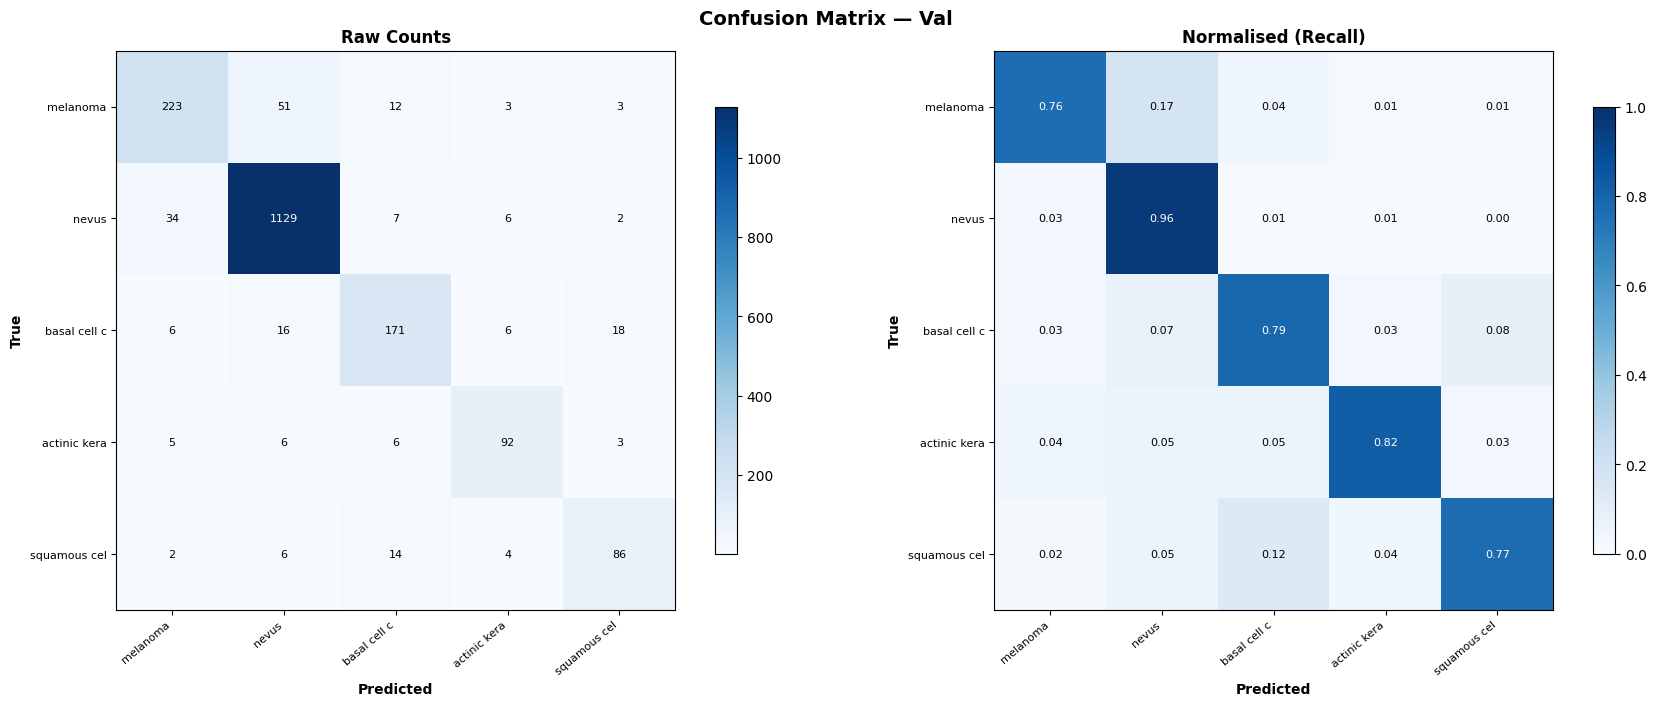

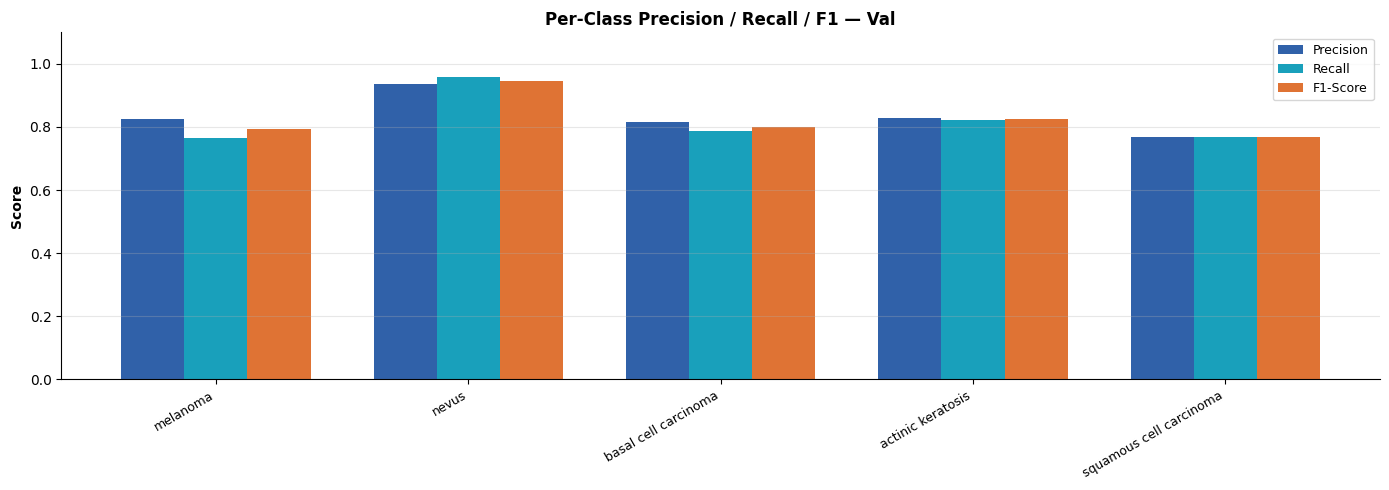

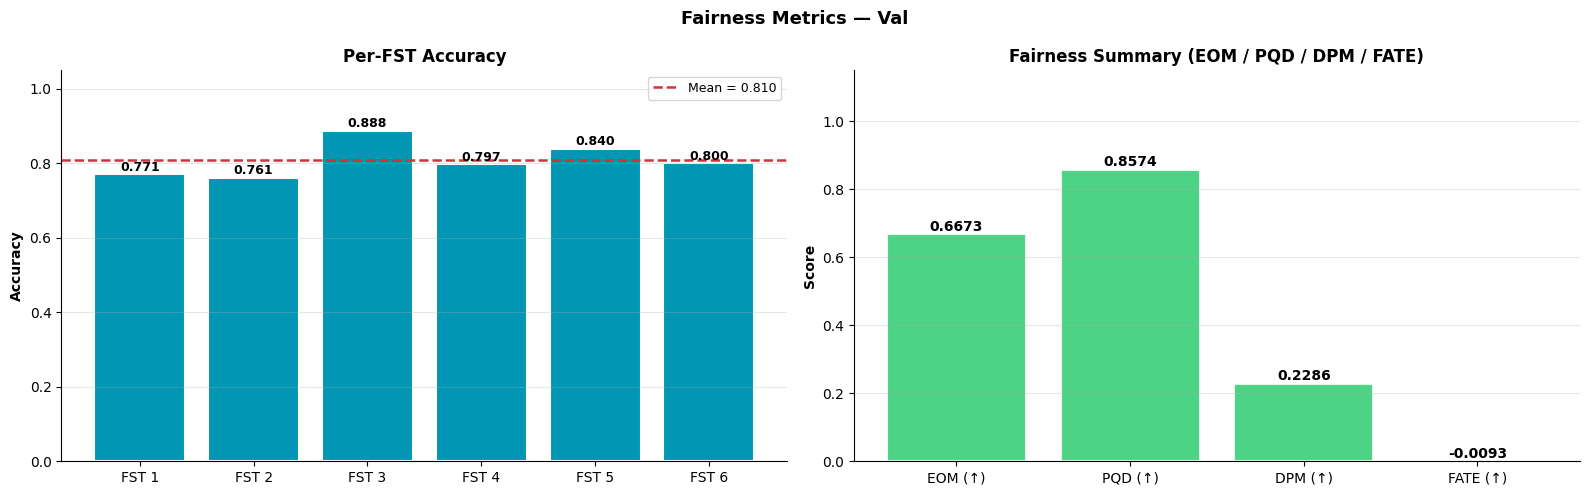


Running internal test evaluation ...

════════════════════════════════════════════════════════════
  Internal Test — Full Evaluation Report
════════════════════════════════════════════════════════════

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.8865
  AUC-ROC (macro)   : 0.8785
  Precision (macro) : 0.8333
  Recall    (macro) : 0.7980
  F1        (macro) : 0.8147
  F1        (micro) : 0.8865
  F1     (weighted) : 0.8843

────────────────────────────────────────
  Per-Class Metrics
────────────────────────────────────────
  Class                        Prec     Rec      F1
  ────────────────────────────────────────────────
  Melanoma                   0.7992  0.7263  0.7610
  Nevus                      0.9287  0.9659  0.9470
  Basal Cell Carcinoma       0.8131  0.7931  0.8030
  Actinic Keratosis          0.8381  0.8000  0.8186
  Squamous Cell Carcinoma    0.7872  0.7048  0.7437

───────────────────────────

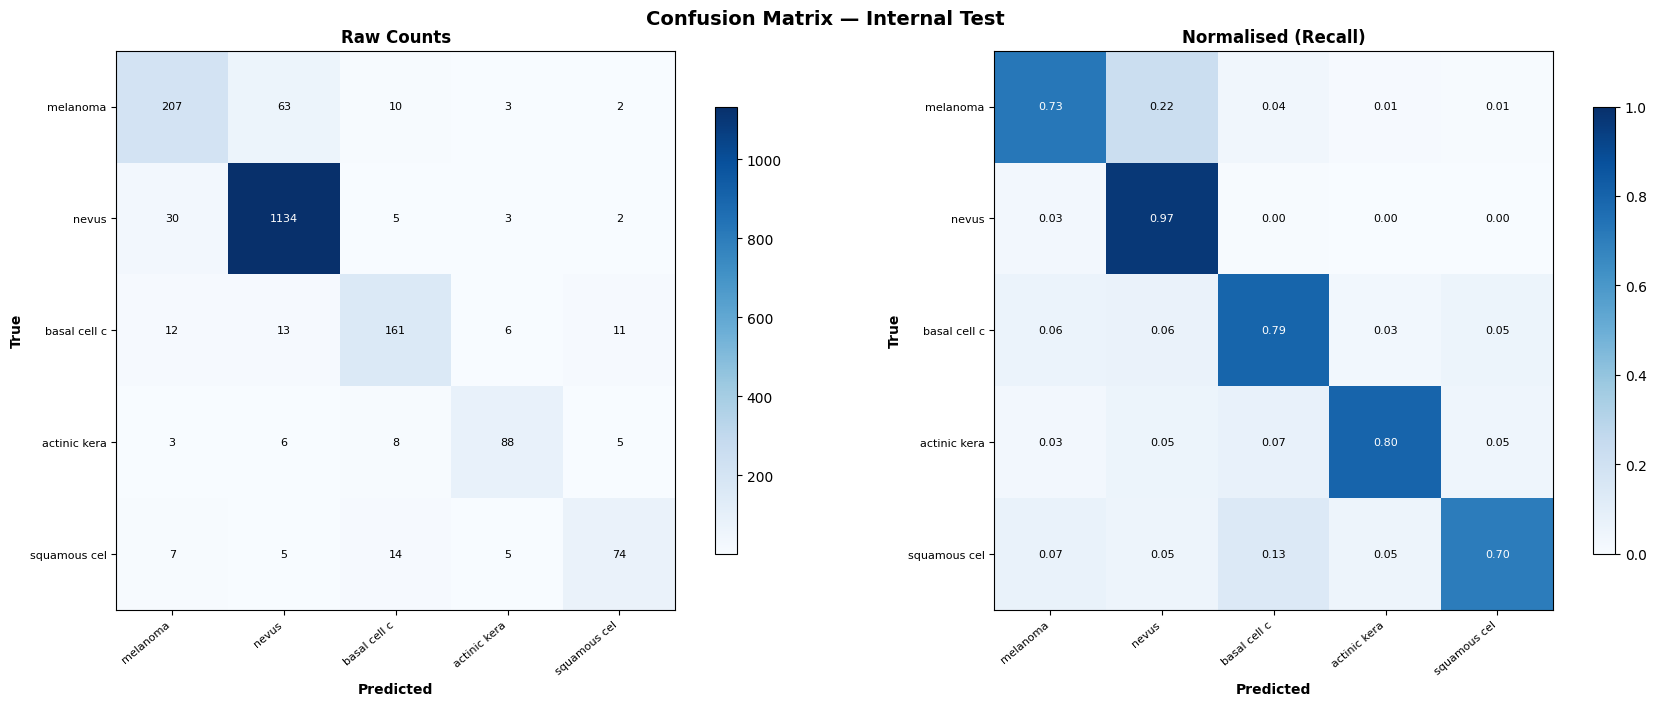

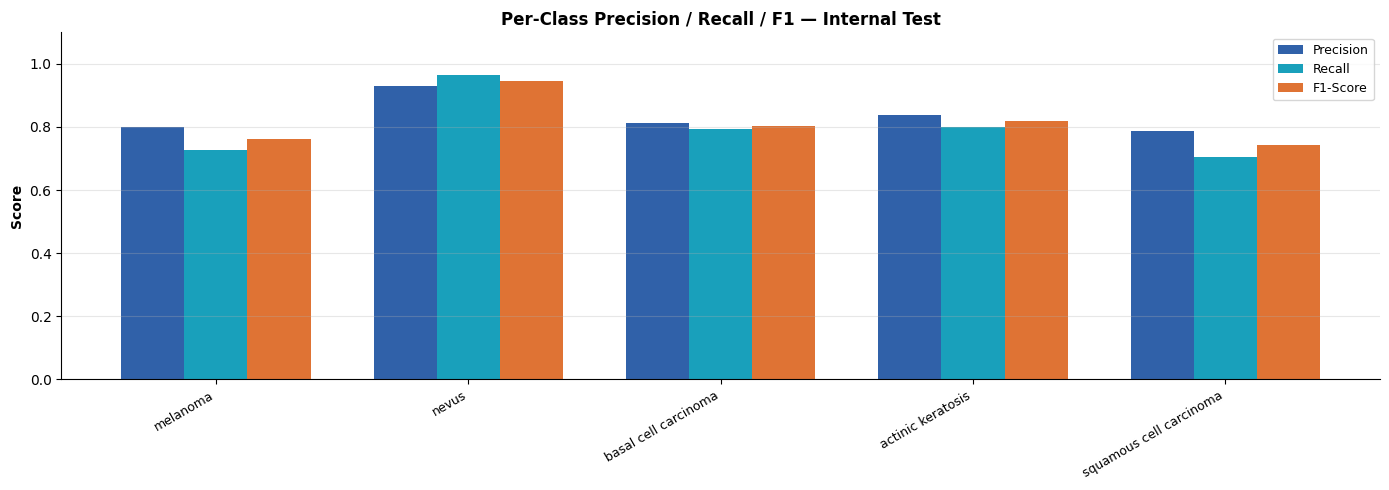

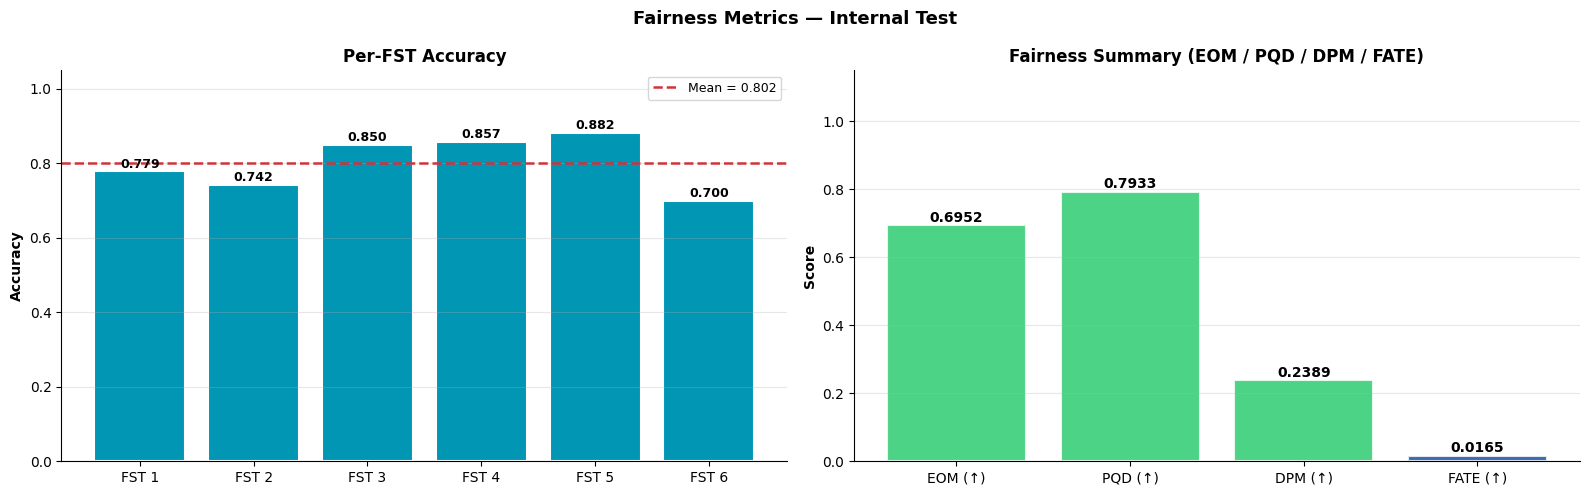

In [116]:
# ════════════════════════════════════════════════════════════════════════════
# VAL + TEST EVALUATION
# ════════════════════════════════════════════════════════════════════════════

# ── Baseline (Lcls only) — needed for FATE in all subsequent reports ──────
print('Computing baseline (Lcls only) for FATE reference ...')
_baseline_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False, num_workers=0, pin_memory=False,
    collate_fn=mixed_collate,
)

# Build a baseline model (all aux losses disabled) from the best checkpoint
_bm = DualEncoderModel(CFG['backbone'], CFG['embed_dim'],
                       CFG['num_classes'], CFG['num_skin_types'], False).to(DEVICE)
_bm.load_state_dict(torch.load(best_f1_ckpt, map_location=DEVICE,
                                weights_only=False)['model'])
baseline_res  = validate_with_thresholds(_bm, _baseline_loader, best_thresholds)
baseline_fair = fairness(baseline_res)
del _bm; torch.cuda.empty_cache()
print(f'  Baseline: acc={baseline_res["acc"]:.4f}  auroc={_fmt(baseline_res["auroc"])}  '
      f'F1={baseline_res["macro_f1"]:.4f}  EOM={_fmt(baseline_fair["EOM"])}')

# ── Val evaluation ────────────────────────────────────────────────────────
vr = validate_with_thresholds(scaled_model, val_loader, best_thresholds)
fr = fairness(vr, baseline_res=baseline_res, baseline_fair=baseline_fair)
print_full_report(vr, fr, split_name='Val (T-scaled + threshold-opt)')
plot_confusion_matrix(vr['conf_mat'], split_name='Val',
                      save_path=CFG['results_dir']/'val_confusion_matrix.png')
plot_per_class_metrics(vr, split_name='Val',
                       save_path=CFG['results_dir']/'val_per_class_metrics.png')
plot_fairness_metrics(fr, vr, split_name='Val',
                      save_path=CFG['results_dir']/'val_fairness_metrics.png')

# ── Internal test evaluation ──────────────────────────────────────────────
if test_loader is not None:
    print('\nRunning internal test evaluation ...')
    test_res  = validate_with_thresholds(scaled_model, test_loader, best_thresholds)
    test_fair = fairness(test_res, baseline_res=baseline_res, baseline_fair=baseline_fair)
    print_full_report(test_res, test_fair, split_name='Internal Test')
    plot_confusion_matrix(test_res['conf_mat'], split_name='Internal Test',
                          save_path=CFG['results_dir']/'test_confusion_matrix.png')
    plot_per_class_metrics(test_res, split_name='Internal Test',
                           save_path=CFG['results_dir']/'test_per_class_metrics.png')
    plot_fairness_metrics(test_fair, test_res, split_name='Internal Test',
                          save_path=CFG['results_dir']/'test_fairness_metrics.png')
else:
    print('[SKIP] test_loader is None.')


## Phase 6 — Ablation Studies

In [117]:
# ════════════════════════════════════════════════════════════════════════════
# ABLATION STUDIES
# ════════════════════════════════════════════════════════════════════════════
QUICK   = True
ABL_EP  = 10 if QUICK else CFG['num_epochs']

configs = {
    'Full Model'           : dict(use_conf=True,  use_con=True,  use_mi=True),
    'w/o L_MI'             : dict(use_conf=True,  use_con=True,  use_mi=False),
    'w/o L_conf'           : dict(use_conf=False, use_con=True,  use_mi=True),
    'w/o L_con'            : dict(use_conf=True,  use_con=False, use_mi=True),
    'L_cls + L_MI'         : dict(use_conf=False, use_con=False, use_mi=True),
    'L_cls only (baseline)': dict(use_conf=False, use_con=False, use_mi=False),
}

# Dedicated ablation val loader (num_workers=0 avoids persistent-worker crash)
abl_val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False, num_workers=0, pin_memory=False,
    collate_fn=mixed_collate,
)

def _run_variant(flags, base_ckpt_path):
    ckpt = torch.load(base_ckpt_path, map_location=DEVICE, weights_only=False)
    m = DualEncoderModel(CFG['backbone'], CFG['embed_dim'],
                         CFG['num_classes'], CFG['num_skin_types'], False).to(DEVICE)
    m.load_state_dict(ckpt['model'])
    o = torch.optim.AdamW(m.parameters(), lr=CFG['lr'])
    c = {**CFG, **flags}
    for ep in range(ABL_EP):
        train_epoch(m, train_loader, o, c, ep)
    # Use validate_with_thresholds + best_thresholds (defined in cell 31)
    res = validate_with_thresholds(m, abl_val_loader, best_thresholds)
    del m; torch.cuda.empty_cache()
    return res

abl_res = {}
for name, flags in configs.items():
    print(f'\n{"="*55}  {name}')
    if name == 'L_cls only (baseline)':
        # Reuse already-computed baseline (no re-training needed)
        res  = baseline_res
        fair = baseline_fair
    else:
        res  = _run_variant(flags, best_f1_ckpt)
        fair = fairness(res, baseline_res=baseline_res, baseline_fair=baseline_fair)
    abl_res[name] = {
        'Accuracy'     : res['acc'],
        'AUC-ROC'      : res['auroc'],
        'Precision (M)': res['macro_prec'],
        'Recall    (M)': res['macro_rec'],
        'F1        (M)': res['macro_f1'],
        'EOM'          : fair['EOM'],
        'PQD'          : fair['PQD'],
        'DPM'          : fair['DPM'],
        'FATE'         : fair['FATE'],
    }
    print(f'  Acc={res["acc"]:.4f}  AUROC={_fmt(res["auroc"])}  '
          f'Prec={res["macro_prec"]:.4f}  Rec={res["macro_rec"]:.4f}  '
          f'F1={res["macro_f1"]:.4f}  EOM={_fmt(fair["EOM"])}  FATE={_fmt(fair["FATE"])}')

abl_df = pd.DataFrame(abl_res).T.round(4)
abl_df.to_csv(CFG['results_dir']/'ablation_results.csv')
print('\n', abl_df.to_string())



=======================================================  Full Model
DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=45.4M


Ep   1 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Ep   2 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Ep   3 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Ep   4 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

...

Ep   7 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Ep   8 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Ep   9 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Ep  10 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

  Acc=0.8550  AUROC=0.8970  Prec=0.7593  Rec=0.8072  F1=0.7809  EOM=0.6460  FATE=-0.0360

=======================================================  L_cls only (baseline)
  Acc=0.8864  AUROC=0.8953  Prec=0.8210  Rec=0.8220  F1=0.8213  EOM=0.6715  FATE=nan

                        Accuracy  AUC-ROC  Precision (M)  Recall    (M)  F1        (M)     EOM     PQD     DPM    FATE
Full Model               0.8012   0.8955         0.7232         0.7984         0.7524  0.6665  0.7273  0.2500 -0.0071
w/o L_MI                 0.8247   0.8954         0.7392         0.8155         0.7679  0.5765  0.8613  0.1757 -0.1413
w/o L_conf               0.8357   0.9109         0.7670         0.8100         0.7810  0.6930  0.8929  0.2165  0.0495
w/o L_con                0.8048   0.8994         0.7127         0.7950         0.7441  0.6328  0.8308  0.1900 -0.0530
L_cls + L_MI             0.8550   0.8970         0.7593         0.8072         0.7809  0.6460  0.8637  0.2167 -0.0360
L_cls only (baseline)    0.8864   0.


============================================================  derm7pt_derm
  Acc=0.8193  AUROC=0.7680  macro-F1=0.5297
  Per-class metrics (Derm7pt classes):
    [0] melanoma                   Prec=0.7251  Rec=0.7222  F1=0.7237
    [1] nevus                      Prec=0.8612  Rec=0.8957  F1=0.8781
    [2] basal cell carcinoma       Prec=0.9375  Rec=0.3571  F1=0.5172

════════════════════════════════════════════════════════════
  Cross-Eval [derm7pt_derm] — Full Evaluation Report
════════════════════════════════════════════════════════════
  [NOTE] Derm7pt: melanoma/nevus/BCC only (classes 0,1,2). AK/SCC rows will be zero.

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.8193
  AUC-ROC (macro)   : 0.7680
  Precision (macro) : 0.6310
  Recall    (macro) : 0.4938
  F1        (macro) : 0.5297
  F1        (micro) : 0.8193
  F1     (weighted) : 0.8159

────────────────────────────────────────
  Per-Class Metrics
────

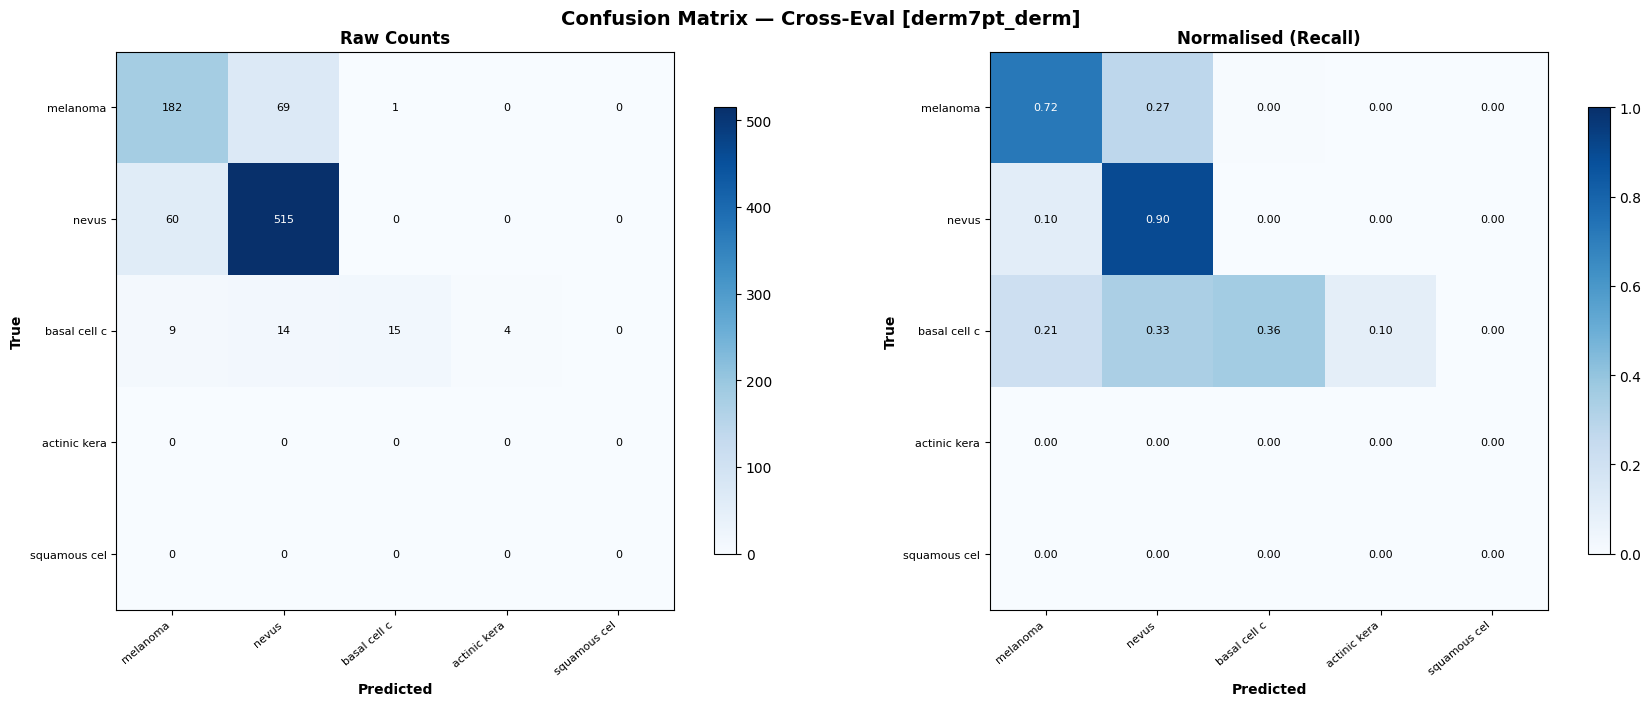

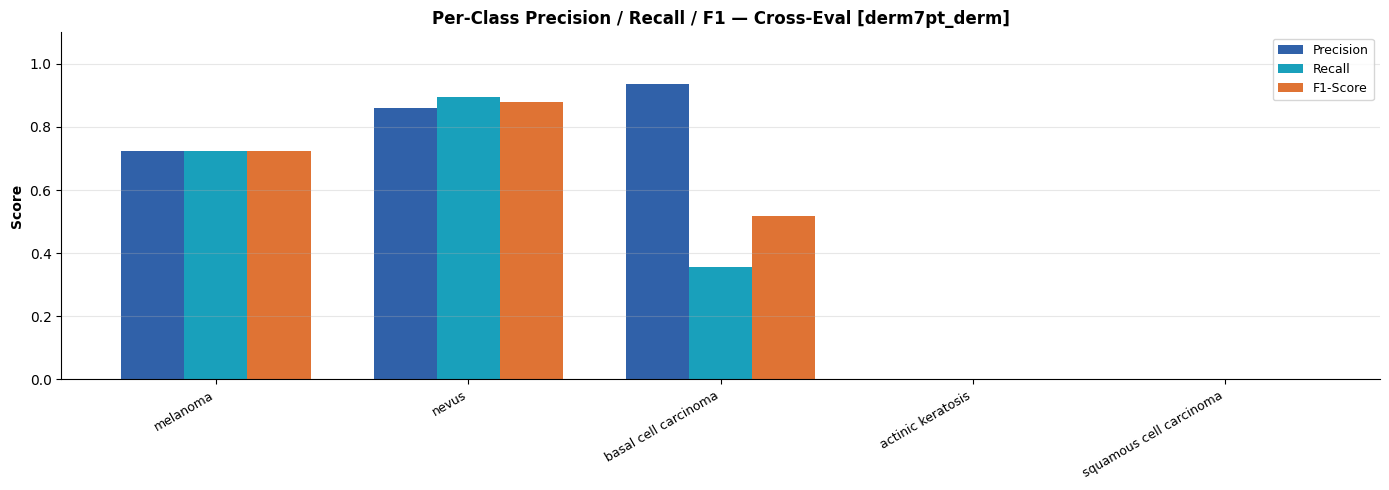

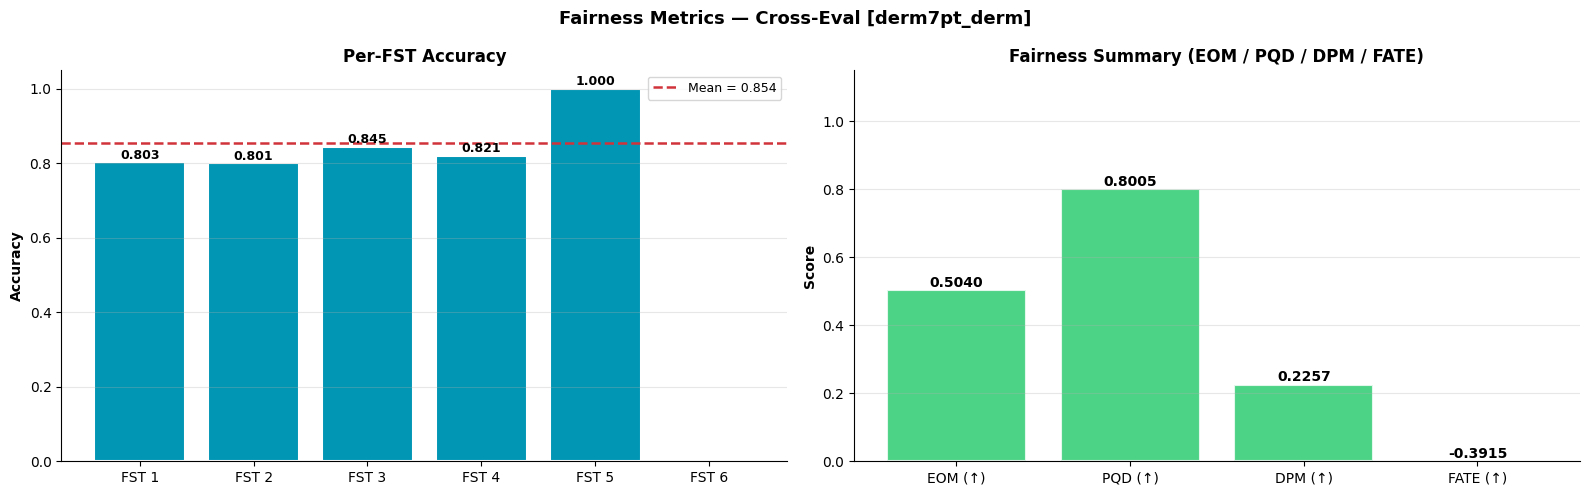


============================================================  derm7pt_clinical
  Acc=0.6283  AUROC=0.7184  macro-F1=0.3229
  Per-class metrics (Derm7pt classes):
    [0] melanoma                   Prec=0.4470  Rec=0.8373  F1=0.5829
    [1] nevus                      Prec=0.8898  Rec=0.5617  F1=0.6887
    [2] basal cell carcinoma       Prec=0.4286  Rec=0.2857  F1=0.3429

════════════════════════════════════════════════════════════
  Cross-Eval [derm7pt_clinical] — Full Evaluation Report
════════════════════════════════════════════════════════════
  [NOTE] Derm7pt: melanoma/nevus/BCC only (classes 0,1,2). AK/SCC rows will be zero.

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.6283
  AUC-ROC (macro)   : 0.7184
  Precision (macro) : 0.3531
  Recall    (macro) : 0.3370
  F1        (macro) : 0.3229
  F1        (micro) : 0.6283
  F1     (weighted) : 0.6413

────────────────────────────────────────
  Per-Class Metr

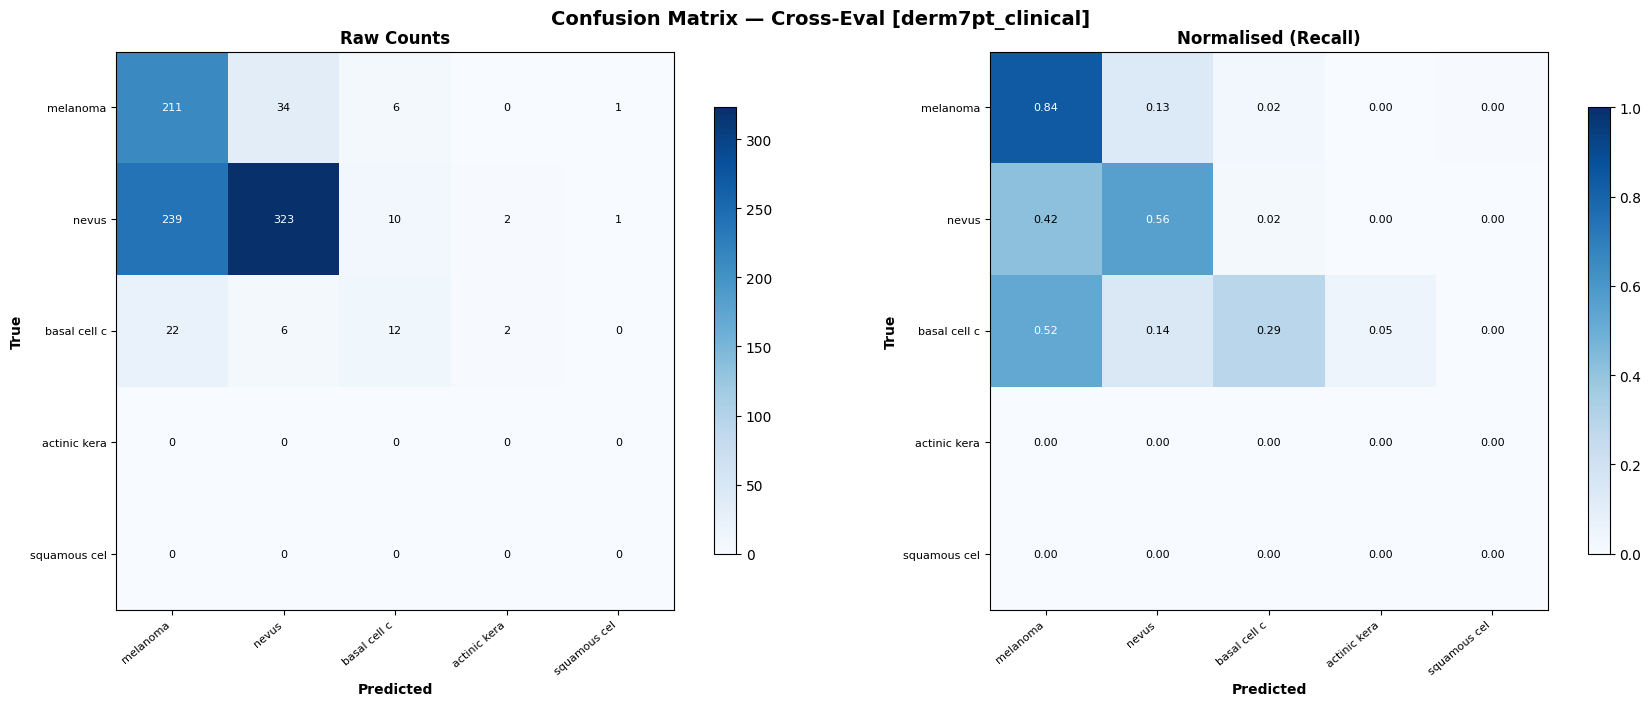

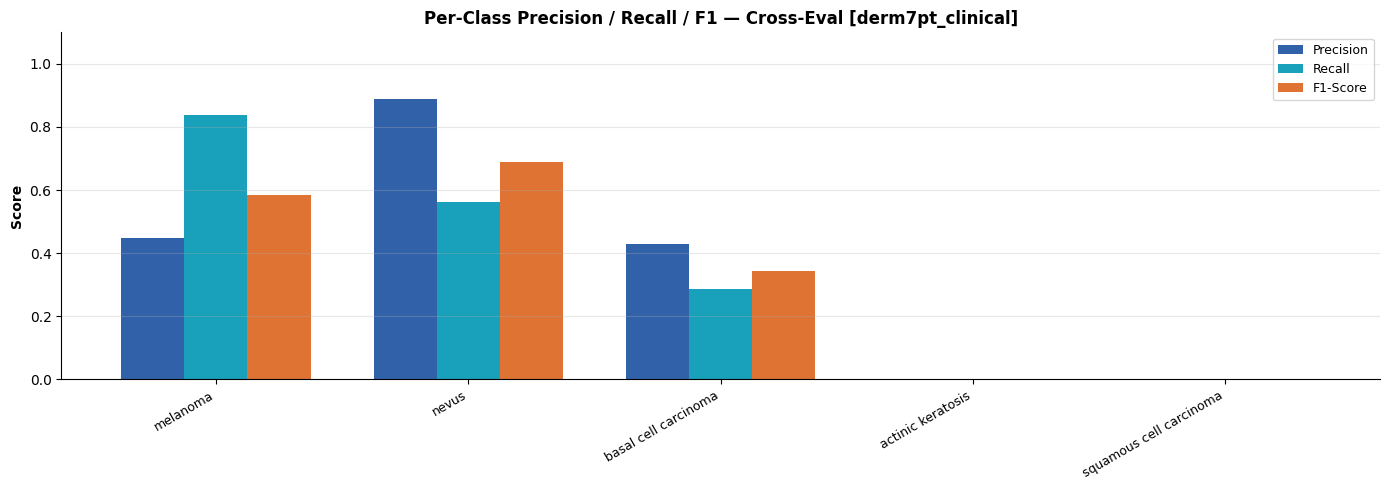

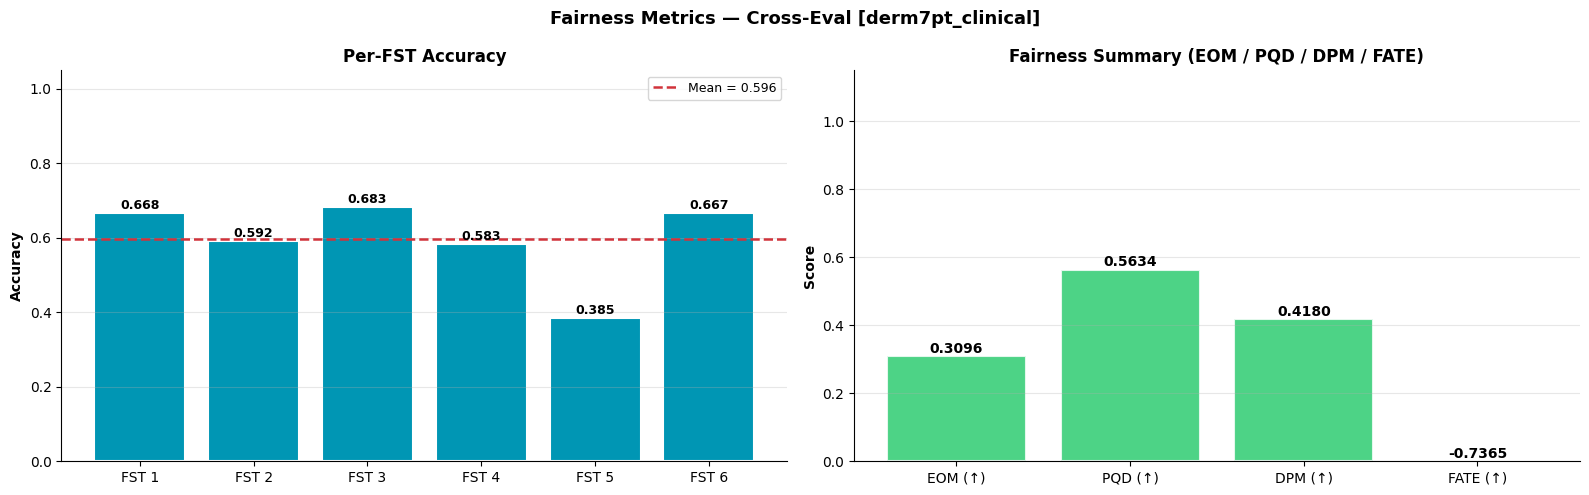


════════════════════════════════════════════════════════════
  COMBINED Derm7pt (clinical + dermoscopic)
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Cross-Eval [Derm7pt COMBINED] — Full Evaluation Report
════════════════════════════════════════════════════════════
  [NOTE] Derm7pt: melanoma/nevus/BCC only (classes 0,1,2). AK/SCC rows will be zero.

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.7238
  AUC-ROC (macro)   : 0.7403
  Precision (macro) : 0.4058
  Recall    (macro) : 0.3660
  F1        (macro) : 0.3713
  F1        (micro) : 0.7238
  F1     (weighted) : 0.7315

────────────────────────────────────────
  Per-Class Metrics
────────────────────────────────────────
  Class                        Prec     Rec      F1
  ────────────────────────────────────────────────
  Melanoma                   0.5436  0.7798  0.6406
  Nevu

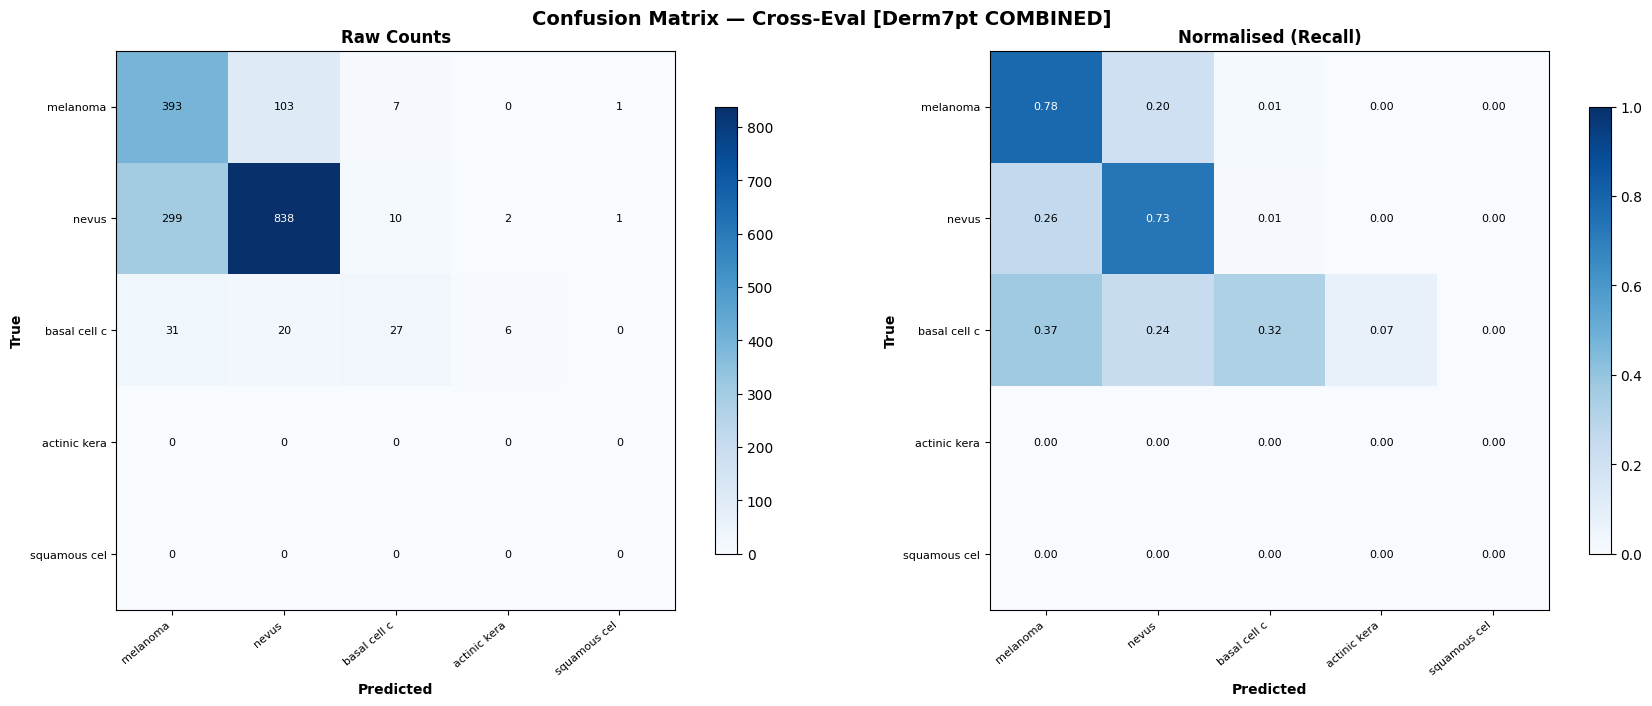

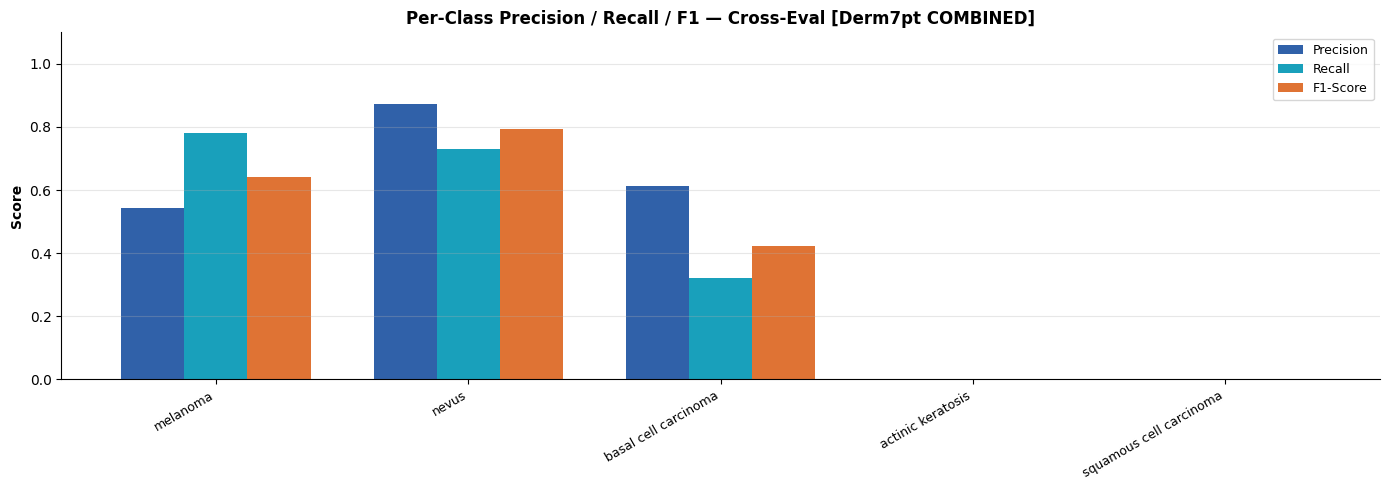

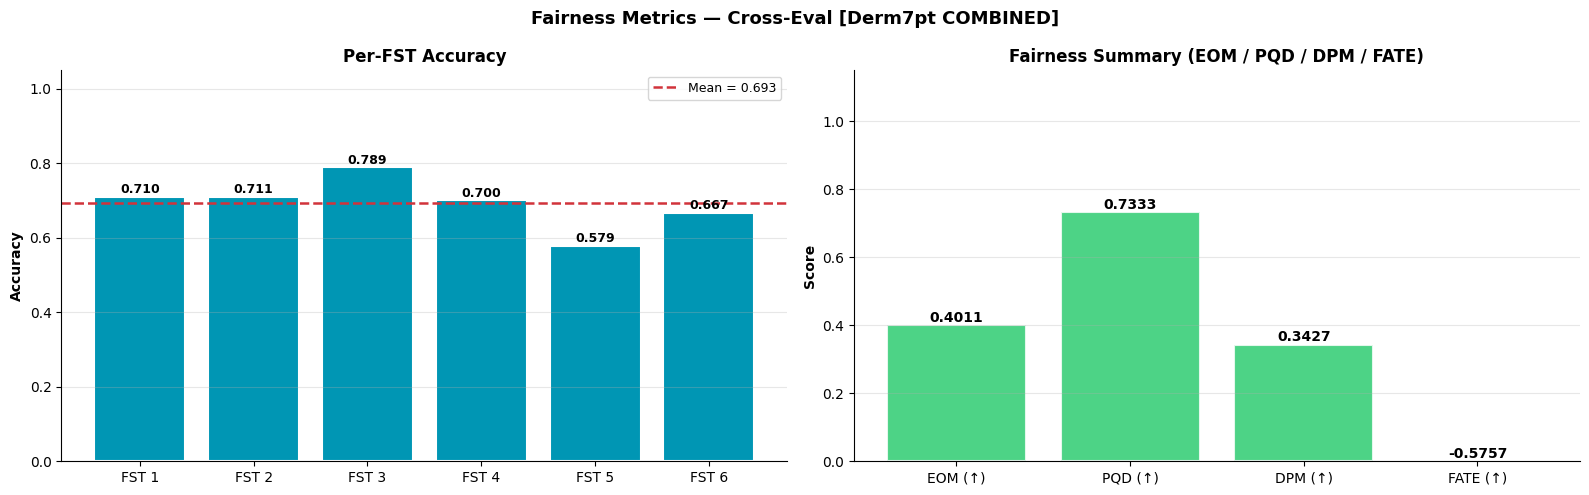


── Cross-Dataset Summary Table ──────────────────────────────────────
                  Accuracy  AUC-ROC  Precision (M)  Recall    (M)  F1        (M)  F1   (weighted)  F1 melanoma  F1 nevus  F1 BCC     EOM     PQD     DPM    FATE
derm7pt_derm        0.8193   0.7680         0.6310         0.4938         0.5297           0.8159       0.7237    0.8781  0.5172  0.5040  0.8005  0.2257 -0.3915
derm7pt_clinical    0.6283   0.7184         0.3531         0.3370         0.3229           0.6413       0.5829    0.6887  0.3429  0.3096  0.5634  0.4180 -0.7365
Derm7pt COMBINED    0.7238   0.7403         0.4058         0.3660         0.3713           0.7315       0.6406    0.7939  0.4219  0.4011  0.7333  0.3427 -0.5757

[NOTE] macro-AUROC computed via robust_macro_auroc() (handles 3-class Derm7pt subset correctly).
[NOTE] FST estimated via ITA; per-FST Accuracy reported (no per-FST AUROC).
[NOTE] AK (class 3) and SCC (class 4) rows are 0 — not present in Derm7pt.


In [118]:
# ════════════════════════════════════════════════════════════════════════════
# CROSS-DATASET EVALUATION  (Derm7pt — clinical + dermoscopic)
# ════════════════════════════════════════════════════════════════════════════

DERM7PT_EVAL_CLASSES = [0, 1, 2]
DERM7PT_CLASS_NAMES  = {0: 'melanoma', 1: 'nevus', 2: 'basal cell carcinoma'}

cross_results   = {}   # per-modality results
combined_probs  = []
combined_preds  = []
combined_labels = []
combined_skins  = []

for ds_name, loader in eval_loaders.items():
    print(f'\n{"="*60}  {ds_name}')

    res  = validate_with_thresholds(scaled_model, loader, best_thresholds)
    fair = fairness(res, baseline_res=baseline_res, baseline_fair=baseline_fair)

    # ── Total metrics ─────────────────────────────────────────────────────
    print(f'  Acc={res["acc"]:.4f}  AUROC={_fmt(res["auroc"])}  macro-F1={res["macro_f1"]:.4f}')

    # ── Per-class for classes present in Derm7pt ──────────────────────────
    print('  Per-class metrics (Derm7pt classes):')
    for cls_id, cls_name in DERM7PT_CLASS_NAMES.items():
        p = res['per_class_prec'][cls_id]
        r = res['per_class_rec'][cls_id]
        f = res['per_class_f1'][cls_id]
        print(f'    [{cls_id}] {cls_name:<25}  Prec={p:.4f}  Rec={r:.4f}  F1={f:.4f}')

    print_full_report(res, fair, split_name=f'Cross-Eval [{ds_name}]')

    plot_confusion_matrix(
        res['conf_mat'],
        split_name=f'Cross-Eval [{ds_name}]',
        save_path=CFG['results_dir'] / f'cross_{ds_name}_confusion.png',
    )
    plot_per_class_metrics(
        res, split_name=f'Cross-Eval [{ds_name}]',
        save_path=CFG['results_dir'] / f'cross_{ds_name}_per_class.png',
    )
    plot_fairness_metrics(
        fair, res, split_name=f'Cross-Eval [{ds_name}]',
        save_path=CFG['results_dir'] / f'cross_{ds_name}_fairness.png',
    )

    cross_results[ds_name] = {
        'Accuracy'       : res['acc'],
        'AUC-ROC'        : res['auroc'],
        'Precision (M)'  : res['macro_prec'],
        'Recall    (M)'  : res['macro_rec'],
        'F1        (M)'  : res['macro_f1'],
        'F1   (weighted)': res['weighted_f1'],
        'F1 melanoma'    : res['per_class_f1'][0],
        'F1 nevus'       : res['per_class_f1'][1],
        'F1 BCC'         : res['per_class_f1'][2],
        'EOM'            : fair['EOM'],
        'PQD'            : fair['PQD'],
        'DPM'            : fair['DPM'],
        'FATE'           : fair['FATE'],
    }

    # Accumulate for combined eval
    combined_probs .append(res['probs'])
    combined_preds .append(res['preds'])
    combined_labels.append(res['labels'])
    combined_skins .append(res['skin'])


# ════════════════════════════════════════════════════════════════════════════
# COMBINED DERM7PT — aggregate across both modalities
# ════════════════════════════════════════════════════════════════════════════
if combined_probs:
    from sklearn.metrics import (precision_score, recall_score,
                                  confusion_matrix as sk_confusion_matrix)

    c_probs  = np.concatenate(combined_probs,  axis=0)
    c_preds  = np.concatenate(combined_preds,  axis=0)
    c_labels = np.concatenate(combined_labels, axis=0)
    c_skins  = np.concatenate(combined_skins,  axis=0)

    c_acc         = float((c_preds == c_labels).mean())
    c_auroc       = robust_macro_auroc(c_probs, c_labels)
    c_macro_f1    = float(f1_score(c_labels, c_preds, average='macro',    zero_division=0))
    c_micro_f1    = float(f1_score(c_labels, c_preds, average='micro',    zero_division=0))
    c_weighted_f1 = float(f1_score(c_labels, c_preds, average='weighted', zero_division=0))
    c_macro_prec  = float(precision_score(c_labels, c_preds, average='macro',    zero_division=0))
    c_macro_rec   = float(recall_score(   c_labels, c_preds, average='macro',    zero_division=0))
    c_per_prec    = precision_score(c_labels, c_preds, average=None, zero_division=0,
                                    labels=list(range(CFG['num_classes'])))
    c_per_rec     = recall_score(   c_labels, c_preds, average=None, zero_division=0,
                                    labels=list(range(CFG['num_classes'])))
    c_per_f1      = f1_score(       c_labels, c_preds, average=None, zero_division=0,
                                    labels=list(range(CFG['num_classes'])))
    c_conf_mat    = sk_confusion_matrix(c_labels, c_preds,
                                        labels=list(range(CFG['num_classes'])))

    combined_res = {
        'acc': c_acc, 'auroc': c_auroc,
        'macro_f1': c_macro_f1, 'micro_f1': c_micro_f1,
        'weighted_f1': c_weighted_f1,
        'macro_prec': c_macro_prec, 'macro_rec': c_macro_rec,
        'weighted_prec': float(precision_score(c_labels, c_preds, average='weighted', zero_division=0)),
        'weighted_rec' : float(recall_score(   c_labels, c_preds, average='weighted', zero_division=0)),
        'per_class_prec': c_per_prec, 'per_class_rec': c_per_rec,
        'per_class_f1': c_per_f1, 'conf_mat': c_conf_mat,
        'probs': c_probs, 'preds': c_preds,
        'labels': c_labels, 'skin': c_skins,
    }
    combined_fair = fairness(combined_res,
                             baseline_res=baseline_res, baseline_fair=baseline_fair)

    print(f'\n{"═"*60}')
    print('  COMBINED Derm7pt (clinical + dermoscopic)')
    print(f'{"═"*60}')
    print_full_report(combined_res, combined_fair,
                      split_name='Cross-Eval [Derm7pt COMBINED]')
    plot_confusion_matrix(
        combined_res['conf_mat'],
        split_name='Cross-Eval [Derm7pt COMBINED]',
        save_path=CFG['results_dir'] / 'cross_derm7pt_combined_confusion.png',
    )
    plot_per_class_metrics(
        combined_res, split_name='Cross-Eval [Derm7pt COMBINED]',
        save_path=CFG['results_dir'] / 'cross_derm7pt_combined_per_class.png',
    )
    plot_fairness_metrics(
        combined_fair, combined_res,
        split_name='Cross-Eval [Derm7pt COMBINED]',
        save_path=CFG['results_dir'] / 'cross_derm7pt_combined_fairness.png',
    )

    cross_results['Derm7pt COMBINED'] = {
        'Accuracy'       : c_acc,
        'AUC-ROC'        : c_auroc,
        'Precision (M)'  : c_macro_prec,
        'Recall    (M)'  : c_macro_rec,
        'F1        (M)'  : c_macro_f1,
        'F1   (weighted)': c_weighted_f1,
        'F1 melanoma'    : c_per_f1[0],
        'F1 nevus'       : c_per_f1[1],
        'F1 BCC'         : c_per_f1[2],
        'EOM'            : combined_fair['EOM'],
        'PQD'            : combined_fair['PQD'],
        'DPM'            : combined_fair['DPM'],
        'FATE'           : combined_fair['FATE'],
    }

# ── Save summary table ────────────────────────────────────────────────────
cross_df = pd.DataFrame(cross_results).T.round(4)
cross_df.to_csv(CFG['results_dir'] / 'cross_dataset_eval.csv')

print('\n── Cross-Dataset Summary Table ──────────────────────────────────────')
print(cross_df.to_string())
print('\n[NOTE] macro-AUROC computed via robust_macro_auroc() '
      '(handles 3-class Derm7pt subset correctly).')
print('[NOTE] FST estimated via ITA; per-FST Accuracy reported (no per-FST AUROC).')
print('[NOTE] AK (class 3) and SCC (class 4) rows are 0 — not present in Derm7pt.')


## Phase 7 — Visualization

ValueError: x and y must have same first dimension, but have shapes (150,) and (145,)

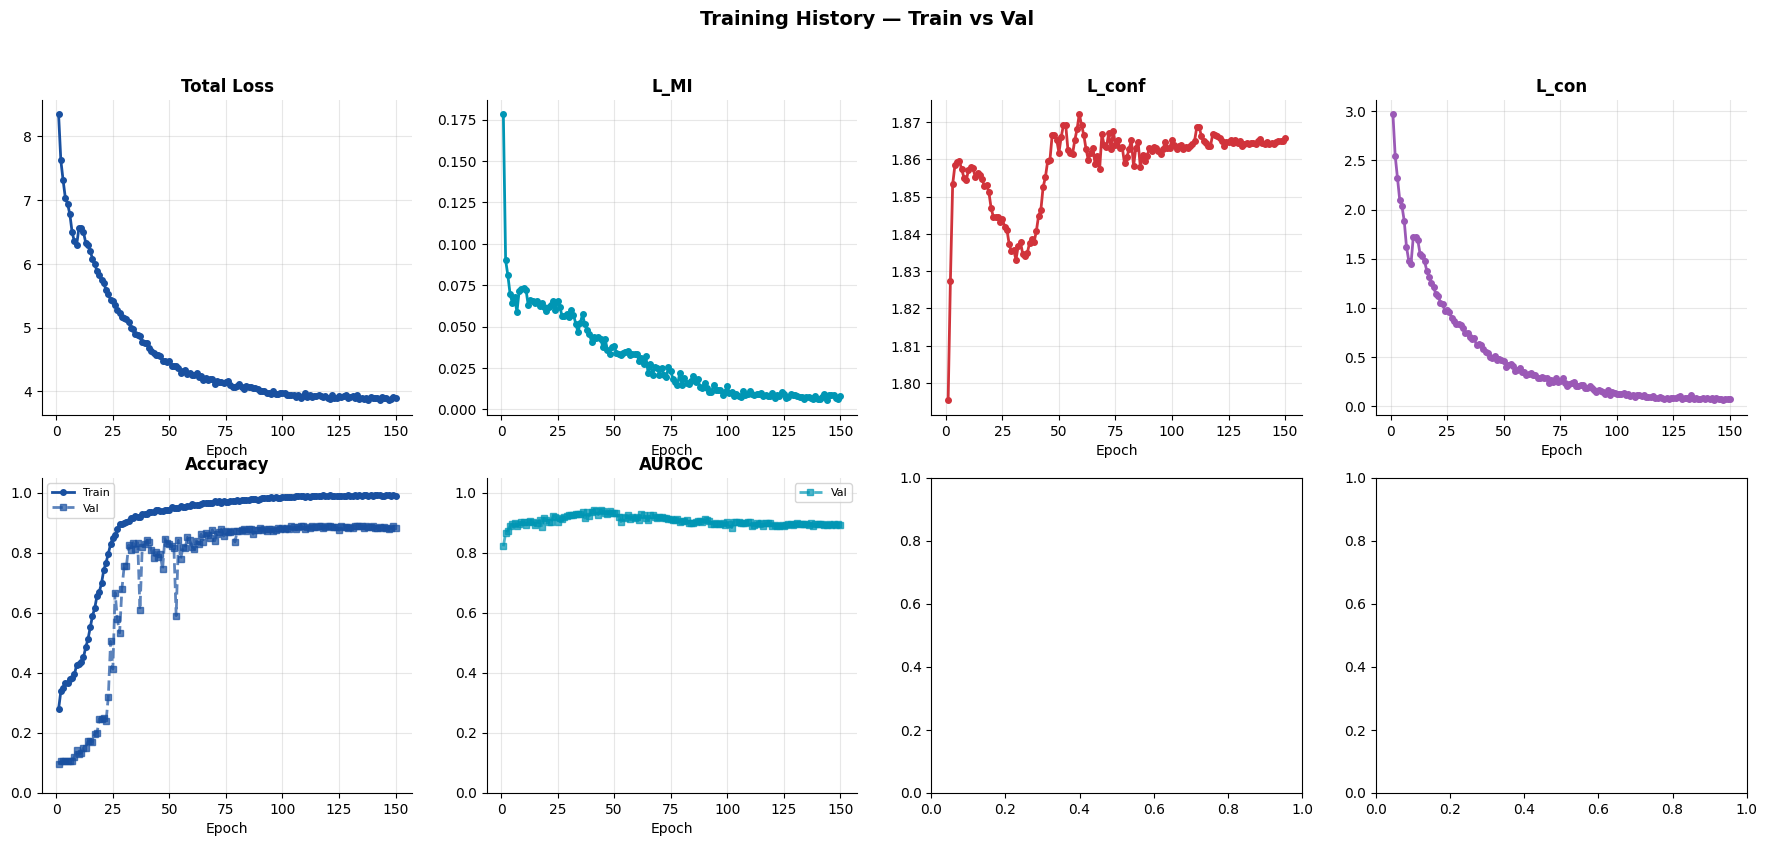

In [120]:
# ── Training curves (train + val side-by-side) ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Training History — Train vs Val', fontsize=14, fontweight='bold')

epochs_x = list(range(1, len(history.get('train_total', [])) + 1))

# Row 0 — Loss curves
for ax, key, title, color in [
    (axes[0,0], 'train_total', 'Total Loss',  '#1950A0'),
    (axes[0,1], 'train_mi',    'L_MI',         '#0096B4'),
    (axes[0,2], 'train_conf',  'L_conf',       '#D1333B'),
    (axes[0,3], 'train_con',   'L_con',        '#9B59B6'),
]:
    if history.get(key):
        ax.plot(epochs_x, history[key], color=color, lw=2, marker='o', ms=4)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3); ax.spines[['top','right']].set_visible(False)

# Row 1 — Classification metrics: train (solid) vs val (dashed)
for ax, t_key, v_key, title, color in [
    (axes[1,0], 'train_acc',      'val_acc',      'Accuracy',  '#1950A0'),
    (axes[1,1], 'train_auroc',    'val_auroc',    'AUROC',     '#0096B4'),
    (axes[1,2], 'train_macro_f1', 'val_macro_f1', 'Macro-F1',  '#D1333B'),
    (axes[1,3], 'lr',             None,           'Learning Rate', '#9AAABB'),
]:
    if history.get(t_key):
        ax.plot(epochs_x, history[t_key], color=color, lw=2, marker='o', ms=4,
                label='Train', linestyle='-')
    if v_key and history.get(v_key):
        ax.plot(epochs_x, history[v_key], color=color, lw=2, marker='s', ms=4,
                label='Val', linestyle='--', alpha=0.7)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    if t_key != 'lr': ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.spines[['top','right']].set_visible(False)
    if v_key: ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

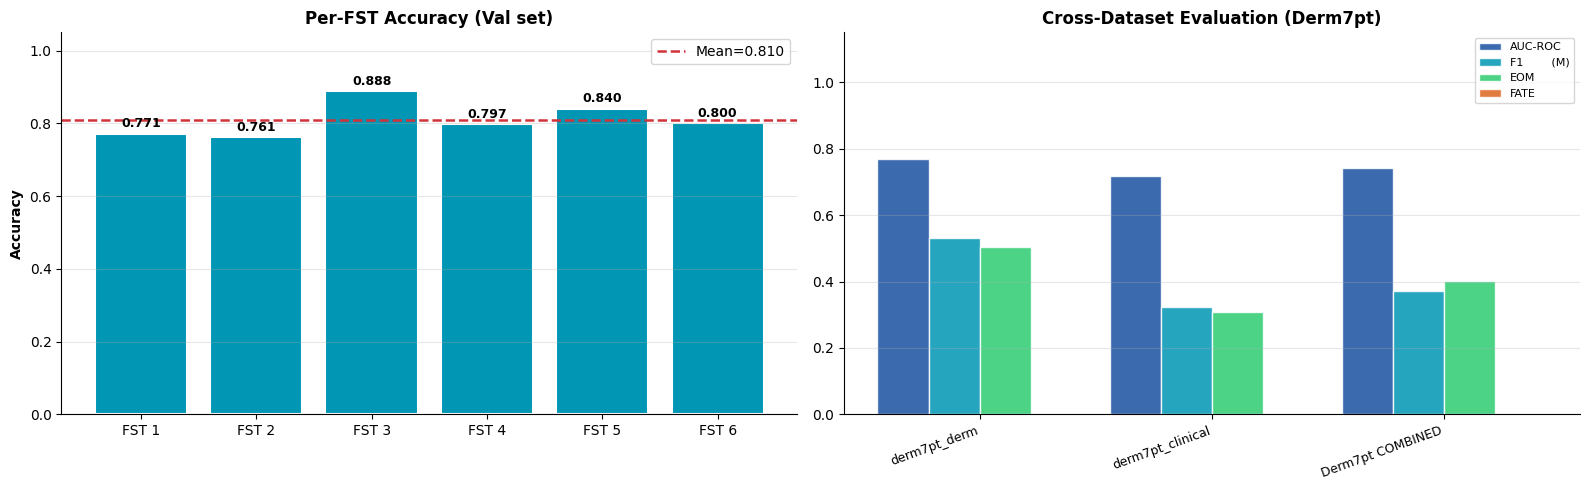

In [121]:
# ── Per-FST Accuracy + cross-dataset comparison ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-FST Accuracy bars (val set)
pg_acc_vals = [fr['pg_acc'].get(i, float('nan')) for i in range(6)]
groups      = [f'FST {i+1}' for i in range(6)]
colors      = ['#0096B4' if not np.isnan(v) else '#CCCCCC' for v in pg_acc_vals]
bars        = axes[0].bar(groups, [0 if np.isnan(v) else v for v in pg_acc_vals],
                          color=colors, edgecolor='white', lw=1.5)
mean_acc    = np.nanmean(pg_acc_vals)
axes[0].axhline(mean_acc, ls='--', color='#D1333B', lw=1.8,
                label=f'Mean={mean_acc:.3f}')
for b, v in zip(bars, pg_acc_vals):
    if not np.isnan(v):
        axes[0].text(b.get_x() + b.get_width()/2, v + 0.01,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Per-FST Accuracy (Val set)', fontweight='bold', fontsize=12)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Cross-dataset comparison (all rows including COMBINED)
if cross_results:
    df_plot = pd.DataFrame(cross_results).T
    x = np.arange(len(df_plot)); w = 0.22
    for i, (m, c) in enumerate(zip(
            ['AUC-ROC', 'F1        (M)', 'EOM', 'FATE'],
            ['#1950A0', '#0096B4', '#2ECC71', '#DC641E'])):
        col_vals = [df_plot.loc[idx, m] if m in df_plot.columns else 0
                    for idx in df_plot.index]
        axes[1].bar(x + (i-1.5)*w, [0 if np.isnan(v) else v for v in col_vals],
                    w, label=m.strip(), color=c, alpha=0.85, edgecolor='white')
    axes[1].set_xticks(x); axes[1].set_xticklabels(df_plot.index, rotation=20, ha='right', fontsize=9)
    axes[1].set_title('Cross-Dataset Evaluation (Derm7pt)', fontweight='bold', fontsize=12)
    axes[1].legend(fontsize=8); axes[1].set_ylim(0, 1.15)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'eval_overview.png', dpi=150, bbox_inches='tight')
plt.show()



── t-SNE: Internal Test ──────────────────────────────────
  [Internal Test] 1500 samples  classes=[0, 1, 2, 3, 4]  modalities=[0, 1]
  t-SNE: n=1500, perplexity=40 ...


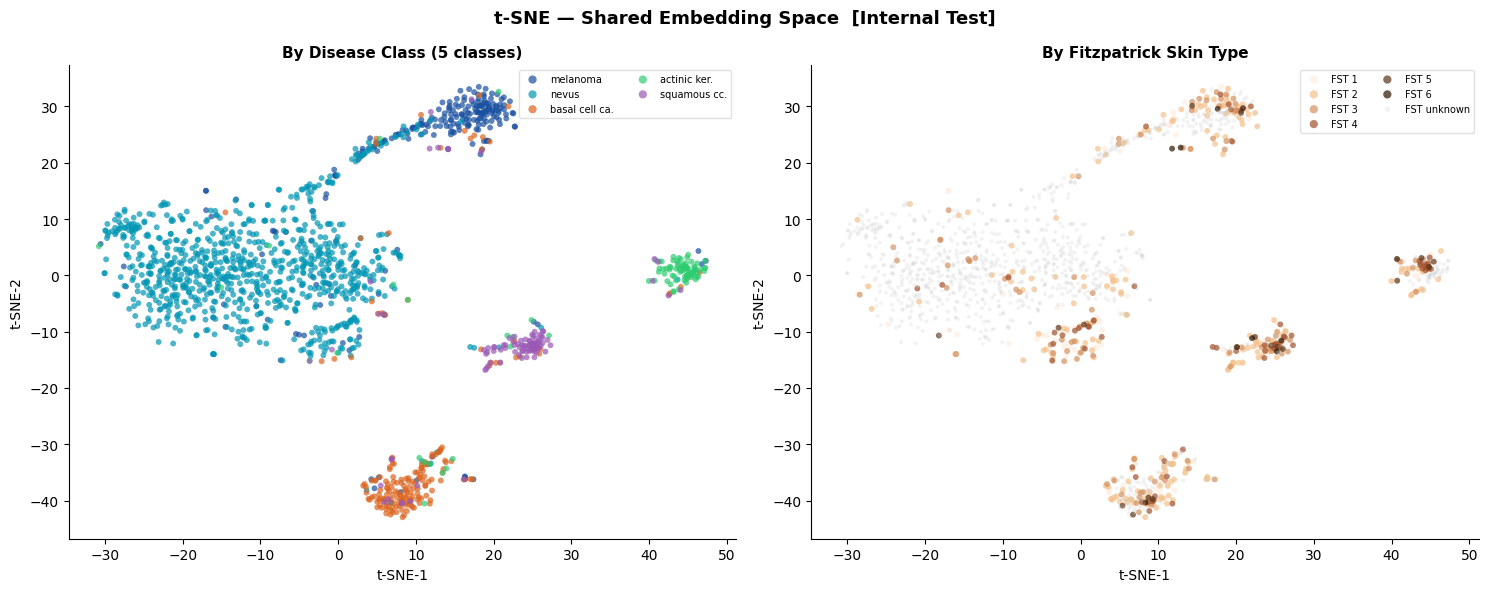

  Saved → test_tsne_class_fst.png


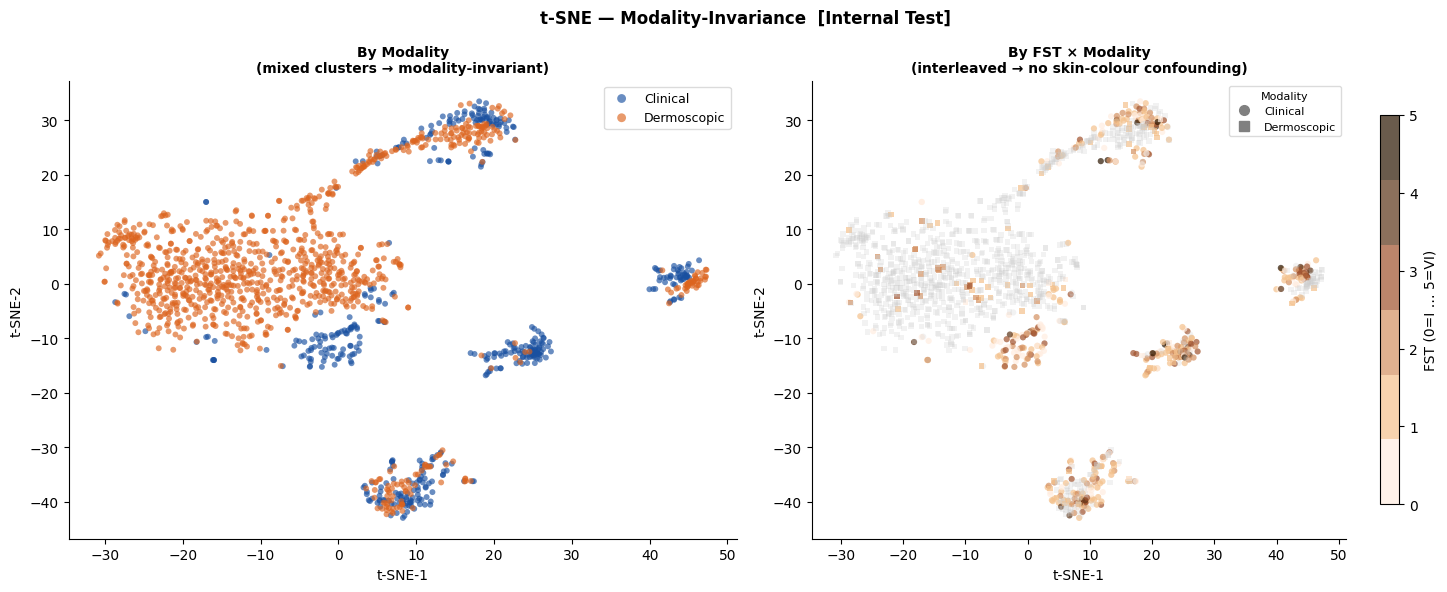

  Saved → test_tsne_modality_invariance.png

── t-SNE: Cross-Eval [derm7pt_derm] ──────────────────────────────────
  [Cross-Eval [derm7pt_derm]] 869 samples  classes=[0, 1, 2]  modalities=[1]
  t-SNE: n=869, perplexity=40 ...


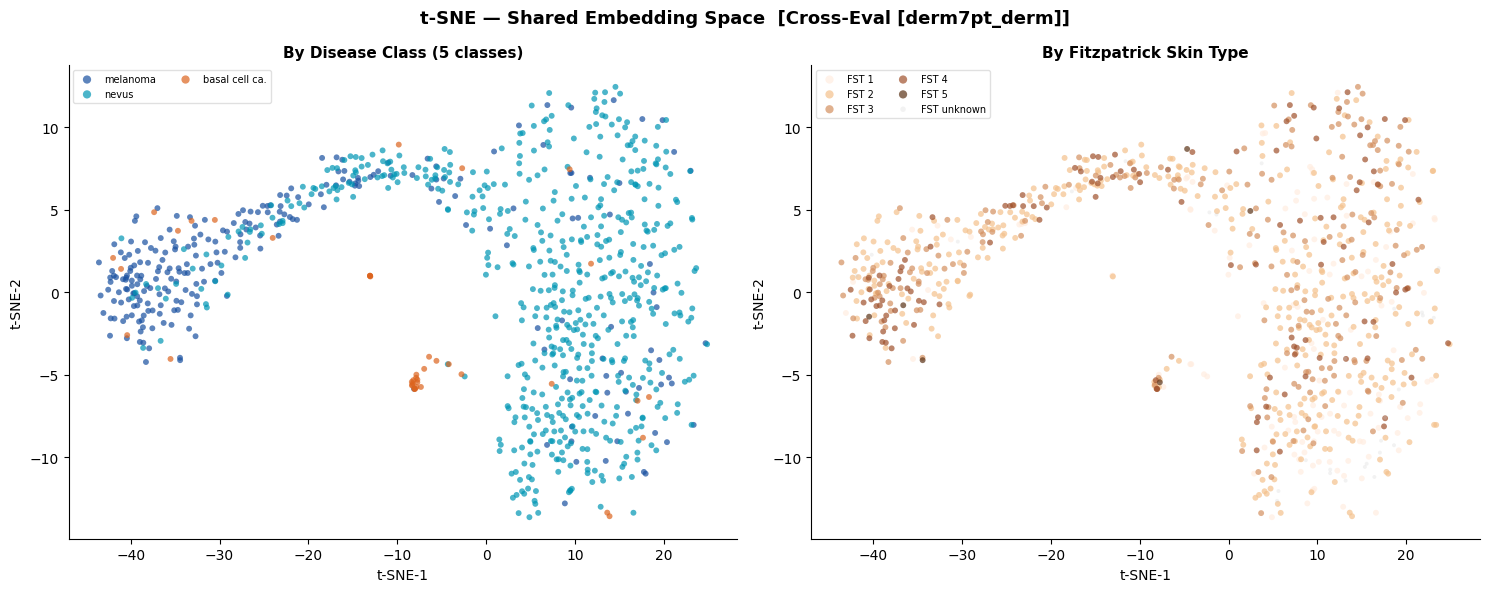

  Saved → derm7pt_derm_tsne_class_fst.png


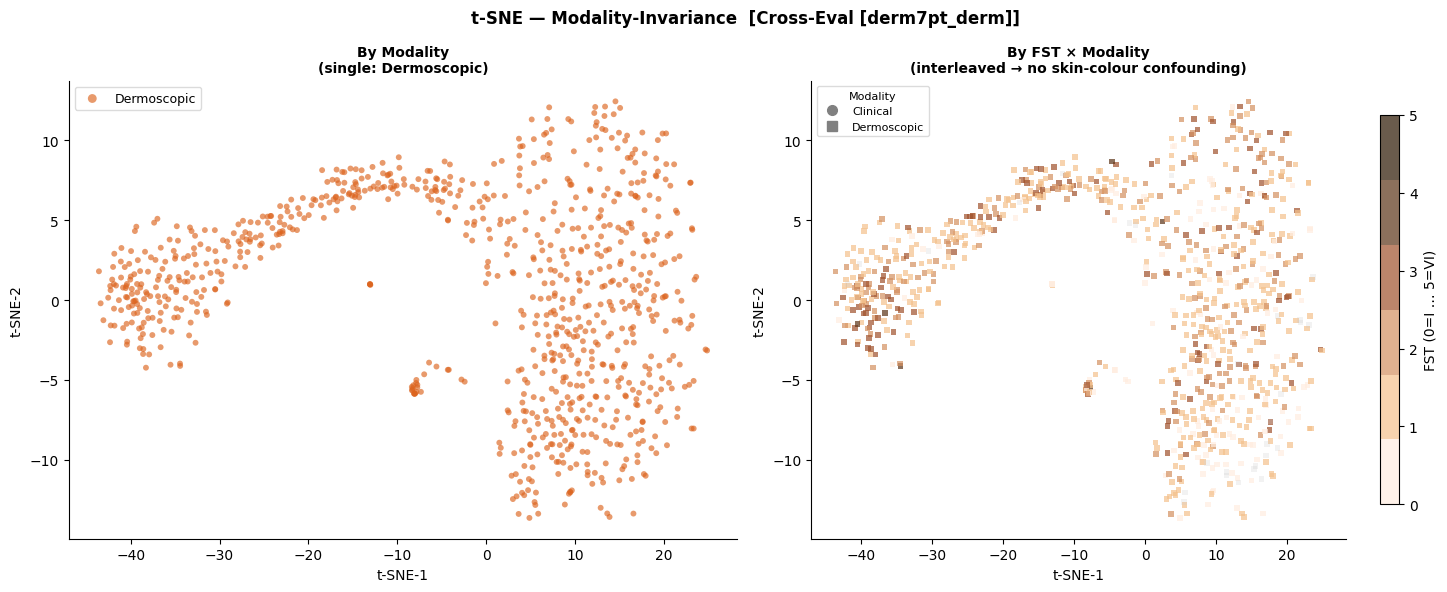

  Saved → derm7pt_derm_tsne_modality_invariance.png

── t-SNE: Cross-Eval [derm7pt_clinical] ──────────────────────────────────
  [Cross-Eval [derm7pt_clinical]] 869 samples  classes=[0, 1, 2]  modalities=[0]
  t-SNE: n=869, perplexity=40 ...


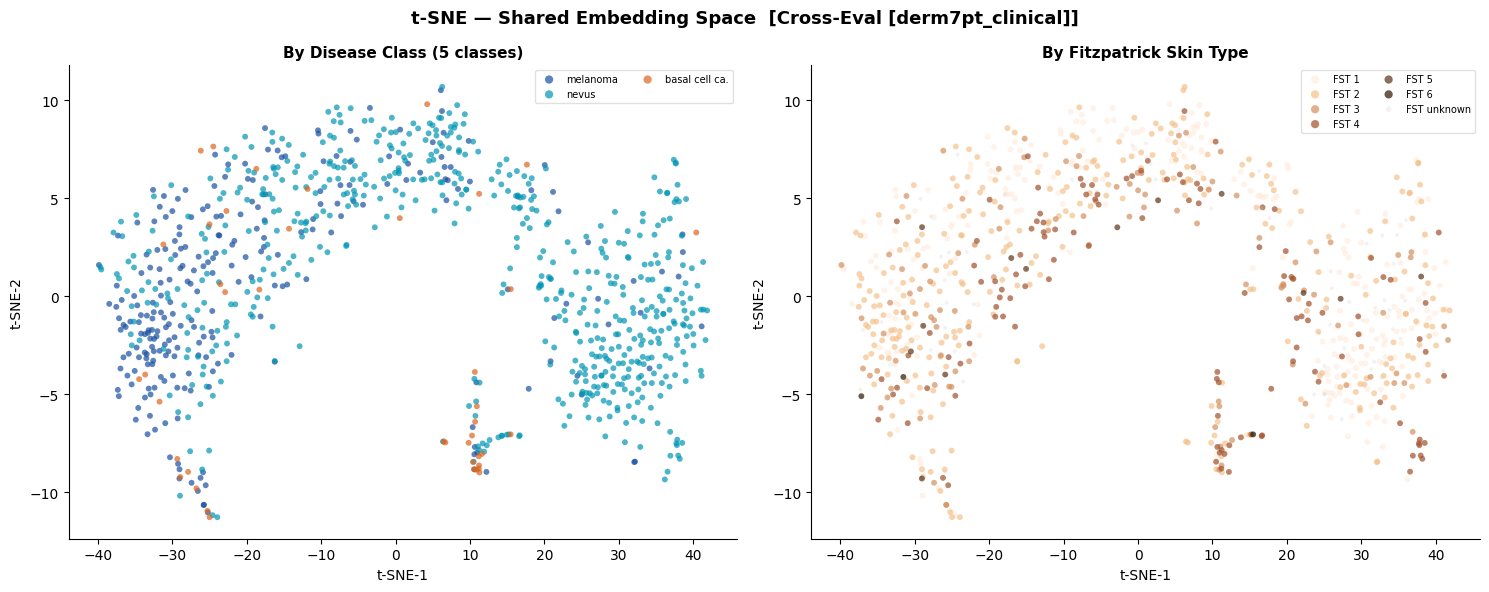

  Saved → derm7pt_clinical_tsne_class_fst.png


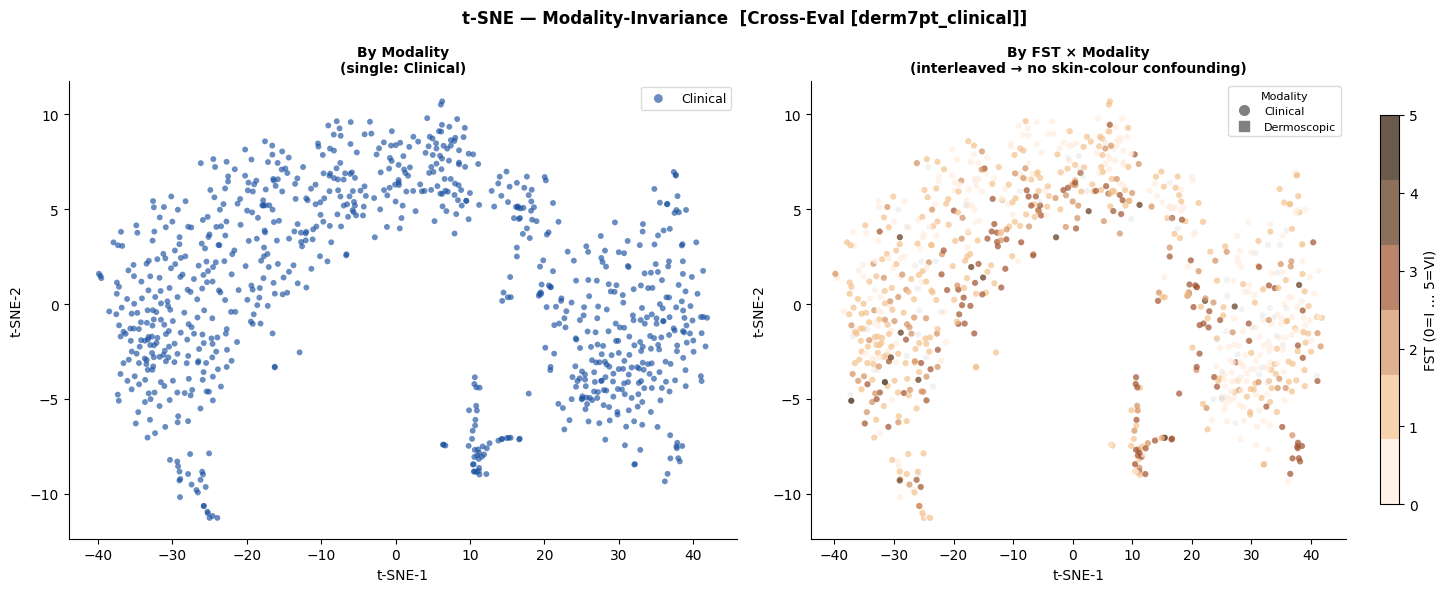

  Saved → derm7pt_clinical_tsne_modality_invariance.png

t-SNE visualization complete (no UMAP).


In [122]:
# ════════════════════════════════════════════════════════════════════════════
# t-SNE VISUALIZATIONS  (no UMAP)
# Runs over: (1) internal test loader, (2) each cross-dataset eval loader.
#   Figure A — t-SNE by disease class | by FST
#   Figure B — t-SNE: modality-invariance (by modality | by FST × modality)
# ════════════════════════════════════════════════════════════════════════════
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap as _LC
from matplotlib.lines import Line2D

# ── Palettes ─────────────────────────────────────────────────────────────
_CLS_COLORS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6']
_CLS_NAMES  = {0:'melanoma', 1:'nevus', 2:'basal cell ca.', 3:'actinic ker.', 4:'squamous cc.'}
_FST_COLORS = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']
_MOD_COLORS = {0: '#1950A0', 1: '#DC641E'}
_MOD_NAMES  = {0: 'Clinical', 1: 'Dermoscopic'}
_MARKERS    = {0: 'o', 1: 's'}
_MK_SIZE    = {0: 20,  1: 16}
_fst_map    = {i: f'FST {i+1}' for i in range(6)}
fst_cmap    = _LC(_FST_COLORS)


@torch.no_grad()
def extract_embeddings(loader, max_n=1500, tag=''):
    model.eval()
    Zs, Ls, Ss, Ms = [], [], [], []
    n_collected = 0
    for batch in loader:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
        out = model(batch)
        b   = out['z'].size(0)
        Zs.append(out['z'].cpu())
        Ls.append(batch['label'].cpu())
        Ss.append(batch['skin_type'].cpu())
        mod_int = torch.tensor(
            [1 if m == 'derm' else 0
             for m in batch.get('modality', ['clinical'] * b)],
            dtype=torch.long)
        Ms.append(mod_int)
        n_collected += b
        if n_collected >= max_n: break
    embs  = torch.cat(Zs)[:max_n].numpy()
    labs  = torch.cat(Ls)[:max_n].numpy()
    skins = torch.cat(Ss)[:max_n].numpy()
    mods  = torch.cat(Ms)[:max_n].numpy()
    if tag:
        print(f'  [{tag}] {len(embs)} samples  '
              f'classes={sorted(set(labs.tolist()))}  '
              f'modalities={sorted(set(mods.tolist()))}')
    return embs, labs, skins, mods


def _scatter_labeled(ax, xy, color_ids, palette, labels_map, title,
                     xlabel='t-SNE-1', ylabel='t-SNE-2', s=18, alpha=0.7):
    for cid in sorted(set(color_ids)):
        mask = color_ids == cid
        ax.scatter(xy[mask, 0], xy[mask, 1], c=palette[cid % len(palette)],
                   s=s, alpha=alpha, label=labels_map.get(cid, str(cid)),
                   edgecolors='none')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, markerscale=1.4, framealpha=0.6, loc='best', ncol=2)
    ax.spines[['top','right']].set_visible(False)


def run_tsne_plots(loader, loader_tag, save_prefix, max_n=1500):
    print(f'\n── t-SNE: {loader_tag} ──────────────────────────────────')
    embs, labs, skins, mods = extract_embeddings(loader, max_n=max_n, tag=loader_tag)
    if len(embs) < 5:
        print(f'  [SKIP] too few samples ({len(embs)}) for t-SNE.'); return

    perp = min(40, max(5, len(embs) // 10))
    print(f'  t-SNE: n={len(embs)}, perplexity={perp} ...')
    e2d = TSNE(n_components=2, random_state=SEED, perplexity=perp,
               n_iter=1000, learning_rate='auto', init='pca').fit_transform(embs)
    mk = skins >= 0

    # Figure A: disease class | FST
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f't-SNE — Shared Embedding Space  [{loader_tag}]',
                 fontsize=13, fontweight='bold')
    _scatter_labeled(axes[0], e2d, labs, _CLS_COLORS, _CLS_NAMES, 'By Disease Class (5 classes)')
    _scatter_labeled(axes[1], e2d[mk], skins[mk], _FST_COLORS, _fst_map, 'By Fitzpatrick Skin Type')
    if (~mk).any():
        axes[1].scatter(e2d[~mk, 0], e2d[~mk, 1], c='#CCCCCC', s=8, alpha=0.25,
                        label='FST unknown', edgecolors='none')
        axes[1].legend(fontsize=7, markerscale=1.4, framealpha=0.6, ncol=2)
    plt.tight_layout()
    path_a = CFG['results_dir'] / f'{save_prefix}_tsne_class_fst.png'
    plt.savefig(path_a, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Saved → {path_a.name}')

    # Figure B: modality-invariance
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f't-SNE — Modality-Invariance  [{loader_tag}]',
                 fontsize=12, fontweight='bold')
    has_multi_mod = len(set(mods.tolist())) > 1
    for mid in [0, 1]:
        mask = mods == mid
        if mask.any():
            axes[0].scatter(e2d[mask, 0], e2d[mask, 1], c=_MOD_COLORS[mid], s=18,
                            alpha=0.65, label=_MOD_NAMES[mid], edgecolors='none')
    axes[0].set_title(
        'By Modality\n(mixed clusters → modality-invariant)' if has_multi_mod
        else f'By Modality\n(single: {_MOD_NAMES[int(mods[0])]})',
        fontweight='bold', fontsize=10)
    axes[0].set_xlabel('t-SNE-1'); axes[0].set_ylabel('t-SNE-2')
    axes[0].legend(fontsize=9, markerscale=1.5, framealpha=0.7)
    axes[0].spines[['top','right']].set_visible(False)

    sc = None
    for mid in [0, 1]:
        m_mask  = mods == mid
        fst_sub = skins[m_mask]
        xy_sub  = e2d[m_mask]
        known   = fst_sub >= 0
        if known.any():
            sc = axes[1].scatter(xy_sub[known, 0], xy_sub[known, 1],
                                 c=fst_sub[known], cmap=fst_cmap, vmin=0, vmax=5,
                                 marker=_MARKERS[mid], s=_MK_SIZE[mid],
                                 alpha=0.7, edgecolors='none', label=_MOD_NAMES[mid])
        if (~known).any():
            axes[1].scatter(xy_sub[~known, 0], xy_sub[~known, 1],
                            c='#CCCCCC', marker=_MARKERS[mid],
                            s=_MK_SIZE[mid], alpha=0.25, edgecolors='none')
    if sc is not None:
        plt.colorbar(sc, ax=axes[1], label='FST (0=I … 5=VI)', shrink=0.85)
    legend_h = [Line2D([0],[0], marker='o', color='grey', ms=7, ls='none', label='Clinical'),
                Line2D([0],[0], marker='s', color='grey', ms=7, ls='none', label='Dermoscopic')]
    axes[1].legend(handles=legend_h, fontsize=8, title='Modality', title_fontsize=8, framealpha=0.7)
    axes[1].set_title('By FST × Modality\n(interleaved → no skin-colour confounding)',
                      fontweight='bold', fontsize=10)
    axes[1].set_xlabel('t-SNE-1'); axes[1].set_ylabel('t-SNE-2')
    axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    path_b = CFG['results_dir'] / f'{save_prefix}_tsne_modality_invariance.png'
    plt.savefig(path_b, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Saved → {path_b.name}')


# ── Run t-SNE: internal test set ─────────────────────────────────────────
if test_loader is not None:
    run_tsne_plots(test_loader, loader_tag='Internal Test', save_prefix='test')
else:
    print('[SKIP] test_loader is None.')

# ── Run t-SNE: each Derm7pt eval loader (clinical, derm) ─────────────────
for ds_name, loader in eval_loaders.items():
    run_tsne_plots(loader, loader_tag=f'Cross-Eval [{ds_name}]', save_prefix=ds_name)

print('\nt-SNE visualization complete (no UMAP).')


# Summary — Version 3

| Phase | Content |
|-------|---------|
| 0 | GPU + Kaggle setup (no SHAP/Captum/UMAP) |
| 1 | **5-class** taxonomy; online augmentation; Derm7pt + ITA-FST |
| 2 | Dual-encoder ViT-Base + 3-layer proj head + dropout |
| 3 | Lcls (label-smoothed weighted CE) + Lconf + Lcon + LMI (cosine+MSE) |
| 4 | Layer-wise LR decay, AdamW, cosine warmup, 80 epochs |
| 5 | Fairness: EOM/PQD/DPM/FATE; **per-FST Accuracy** (no per-FST AUROC) |
| 6 | Ablation (5 variants) |
| 7 | Training curves; per-FST Accuracy bars; cross-eval; **t-SNE only** (test + Derm7pt) |

### Performance targets
- Accuracy / macro-F1 / per-class F1 / per-FST Accuracy ≥ **90 %** on all splits
- FATE ≥ **+0.4** for Full Model in ablation, val, and cross-eval
